# Xenium Human Lung Cancer (FFPE) workflow

## Input data: two lung cancer FFPE datasets from 10x Genomics (CC BY 4.0)

| | **Dataset A (start here)** | **Dataset B (scale-up)** |
|---|---|---|
| Platform | Xenium v1, Onboard Analysis 2.0.0, multimodal segmentation | Xenium Prime 5K, Onboard Analysis 3.0.0 |
| Gene panel | Human Multi-Tissue & Cancer (377 genes + 20 negative-control probes) | 5K Pan Tissue & Pathways (~5,100 genes) |
| Tissue area | 30.3 mm² | 71.1 mm² |
| Cells | 162,254 | 278,328 |
| High-quality transcripts (Q20) | 10.6 M | 149.4 M |
| Median transcripts per cell | 46 | 242 |
| Median genes per cell | 29 | 196 |
| Share of transcripts assigned to cells | 86.6% | 82.0% |
| Download size (zip) | ~8.0 GB | ~22.6 GB |

**Download base URLs**
- Dataset A: `https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_humanLung_Cancer_FFPE/` ([dataset page](https://www.10xgenomics.com/datasets/preview-data-ffpe-human-lung-cancer-with-xenium-multimodal-cell-segmentation-1-standard))
- Dataset B: `https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Human_Lung_Cancer_FFPE/` ([dataset page](https://www.10xgenomics.com/datasets/xenium-human-lung-cancer-post-xenium-technote))

### Dataset A's other QC numbers
- 87.4% of transcripts pass the Q20 quality filter.
- The negative-control rate is very low (about 0.05 false-positive transcripts per cell).
- Cell segmentation used three methods: 33% of cells from a boundary stain, 65% from an interior stain, and 1.5% by expanding the nucleus outline.

### Its panel covers what a TIME analysis needs
- **T cells:** CD3D/E, CD8A, CD4, FOXP3, TRAC
- **Checkpoints:** PDCD1, CD274 (PD-L1), CTLA4, LAG3, HAVCR2
- **Myeloid:** CD68, CD163, MARCO, TREM2
- **B and plasma cells:** MS4A1, CD79A, MZB1
- **Tumour and epithelium:** EPCAM, KRT7, EGFR, ERBB2, MET
- **Stroma:** PDGFRA/B, ACTA2
- **Proliferation:** MKI67, TOP2A


### Proposed pipeline

1. Download Dataset A.
2. Input data overview: annotated folder tree and a data card of every file (headers only, via pyarrow, h5py and tifffile).
3. Load it with spatialdata-io into a SpatialData object and explore the raw tables (transcripts, cells, boundaries) with pyarrow.
4. Run QC.
5. Normalise and cluster.
6. Annotate cell types.
7. Spatial analysis (neighbourhood enrichment, niches, immune infiltration).
8. Align the H&E image.
9. TIME deep-dive: checkpoint expression, CD8 T-cell states by location, spatial ligand-receptor contacts, immune phenotypes (inflamed / excluded / desert), immunosuppressive balance.
10. squidpy spatial statistics: Moran's I, co-occurrence, Ripley's L, centrality / interaction matrix, ligrec vs. contact test.
11. Optionally, repeat on Dataset B.

## Step 1: Download Dataset A

Raw data goes to `~/data/xenium_lung/`, **outside OneDrive**, so multi-GB files don't clog sync.
The cell is safe to re-run: finished files are skipped and interrupted downloads resume where they stopped.

- `DOWNLOAD_HE = True` also fetches the ~1.2 GB matched H&E image, used in Step 8 to map cells onto pathology regions (tumour, stroma, TLS). Set it to `False` only if disk space is tight; re-running later fetches just the missing image.
- Needs ~8 GB for the zip plus roughly the same again once unzipped; set `DELETE_ZIP_AFTER_UNZIP = True` to reclaim the zip space.


In [1]:
import shutil
import zipfile
from pathlib import Path

import requests
from tqdm.auto import tqdm

# ---- Settings ---------------------------------------------------------------
DATA_ROOT = Path("~/data/xenium_lung").expanduser()   # outside OneDrive
DOWNLOAD_HE = True              # ~1.2 GB matched H&E image for Step 8 alignment
DELETE_ZIP_AFTER_UNZIP = False  # set True to free ~8 GB once extracted

SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
BASE_URL = f"https://cf.10xgenomics.com/samples/xenium/2.0.0/{SAMPLE}"

FILES = [
    f"{SAMPLE}_metrics_summary.csv",
    f"{SAMPLE}_gene_panel.json",
    f"{SAMPLE}_he_imagealignment.csv",
    f"{SAMPLE}_outs.zip",
]
if DOWNLOAD_HE:
    FILES.append(f"{SAMPLE}_he_image.ome.tif")

DATA_DIR = DATA_ROOT / SAMPLE
# ask for raw bytes so byte counts match on-disk sizes (no gzip transfer encoding)
NO_GZIP = {"Accept-Encoding": "identity"}
DATA_DIR.mkdir(parents=True, exist_ok=True)


def remote_size(url):
    r = requests.head(url, headers=NO_GZIP, allow_redirects=True, timeout=60)
    r.raise_for_status()
    return int(r.headers.get("content-length", 0))


def download(url, dest):
    """Resumable download: skips complete files, continues partial ones."""
    total = remote_size(url)
    have = dest.stat().st_size if dest.exists() else 0
    if total and have == total:
        print(f"[skip] {dest.name} already complete ({total / 1e9:.2f} GB)")
        return
    if have > total:  # corrupt / mismatched partial, start over
        dest.unlink()
        have = 0

    headers = {**NO_GZIP, **({"Range": f"bytes={have}-"} if have else {})}
    with requests.get(url, headers=headers, stream=True, timeout=60) as r:
        r.raise_for_status()
        if have and r.status_code != 206:  # server ignored Range, restart
            have = 0
        mode = "ab" if have else "wb"
        with open(dest, mode) as f, tqdm(
            total=total, initial=have, unit="B", unit_scale=True, desc=dest.name
        ) as bar:
            for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                f.write(chunk)
                bar.update(len(chunk))

    if dest.stat().st_size != total:
        raise IOError(f"{dest.name}: size mismatch, re-run this cell to resume")


# ---- Disk space check -------------------------------------------------------
needed = sum(remote_size(f"{BASE_URL}/{f}") for f in FILES)
free = shutil.disk_usage(DATA_ROOT).free
print(f"Download size: {needed / 1e9:.1f} GB | free disk: {free / 1e9:.1f} GB")
if free < 2.2 * needed:  # zip + extracted copy + headroom
    print("WARNING: disk space is tight for download + unzip.")

# ---- Download ---------------------------------------------------------------
for fname in FILES:
    download(f"{BASE_URL}/{fname}", DATA_DIR / fname)

# ---- Unzip the output bundle -------------------------------------------------
zip_path = DATA_DIR / f"{SAMPLE}_outs.zip"
OUTS_DIR = DATA_DIR / "outs"
if not (OUTS_DIR / "experiment.xenium").exists():
    with zipfile.ZipFile(zip_path) as zf:
        members = zf.infolist()
        # strip a single top-level folder (e.g. "outs/") if the zip has one
        tops = {m.filename.split("/")[0] for m in members}
        prefix = tops.pop() + "/" if len(tops) == 1 else ""
        OUTS_DIR.mkdir(exist_ok=True)
        for m in tqdm(members, desc="unzip"):
            rel = m.filename[len(prefix):]
            if not rel:
                continue
            target = OUTS_DIR / rel
            if m.is_dir():
                target.mkdir(parents=True, exist_ok=True)
                continue
            target.parent.mkdir(parents=True, exist_ok=True)
            with zf.open(m) as src, open(target, "wb") as dst:
                shutil.copyfileobj(src, dst, length=8 * 1024 * 1024)
    if DELETE_ZIP_AFTER_UNZIP:
        zip_path.unlink()
else:
    print("[skip] outs/ already extracted")

# ---- Inventory (relative paths only) -----------------------------------------
print(f"\nContents of {SAMPLE}/outs:")
for item in sorted(OUTS_DIR.iterdir()):
    if item.is_file():
        size = item.stat().st_size
    else:
        size = sum(f.stat().st_size for f in item.rglob("*") if f.is_file())
    print(f"  {item.name:<40} {size / 1e6:>10.1f} MB")


Download size: 9.2 GB | free disk: 47.4 GB


Xenium_V1_humanLung_Cancer_FFPE_metrics_summary.csv:   0%|          | 0.00/1.73k [00:00<?, ?B/s]

Xenium_V1_humanLung_Cancer_FFPE_gene_panel.json:   0%|          | 0.00/209k [00:00<?, ?B/s]

Xenium_V1_humanLung_Cancer_FFPE_he_imagealignment.csv:   0%|          | 0.00/126 [00:00<?, ?B/s]

Xenium_V1_humanLung_Cancer_FFPE_outs.zip:   0%|          | 0.00/7.99G [00:00<?, ?B/s]

Xenium_V1_humanLung_Cancer_FFPE_he_image.ome.tif:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

unzip:   0%|          | 0/26 [00:00<?, ?it/s]


Contents of Xenium_V1_humanLung_Cancer_FFPE/outs:
  analysis.tar.gz                                32.1 MB
  analysis.zarr.zip                               1.4 MB
  analysis_summary.html                          10.4 MB
  aux_outputs.tar.gz                             50.2 MB
  cell_boundaries.csv.gz                         38.4 MB
  cell_boundaries.parquet                        14.4 MB
  cell_feature_matrix.h5                          6.7 MB
  cell_feature_matrix.tar.gz                     23.0 MB
  cell_feature_matrix.zarr.zip                    9.1 MB
  cells.csv.gz                                    8.8 MB
  cells.parquet                                   2.9 MB
  cells.zarr.zip                                147.1 MB
  experiment.xenium                               0.0 MB
  gene_panel.json                                 0.2 MB
  metrics_summary.csv                             0.0 MB
  morphology.ome.tif                           4762.9 MB
  morphology_focus                   

## Step 2: Input data overview

Before any analysis, get to know the input data. This step answers two questions, and **neither loads the data into memory** (it only reads file headers and metadata, so it runs in about a second):

1. **What files do I have?** (2a) A tree of every file and folder with its size, a role tag, and a plain-language description. Compressed archives are listed without being extracted.
2. **What is inside each file?** (2b) A data card: run metadata, table columns with their meaning and a 3-row preview, the count-matrix layout, image dimensions and stains, and the H&E alignment.

| Role tag | Meaning |
|---|---|
| `CORE` | Primary analysis inputs you will load (transcripts, cells, boundaries, count matrix) |
| `IMAGE` | Microscopy images (DAPI z-stack, segmentation stains, H&E) |
| `META` | Run and panel metadata |
| `QC` | Quality reports and technical extras |
| `BASELINE` | 10x's own automated clustering, to benchmark your results against |
| `EXPLORER` | Xenium Explorer viewer formats (not needed for Python analysis) |
| `COPY` | Same content as a `CORE` file in another format (CSV, MEX) |
| `ARCHIVE` | Compressed download bundle |

### 2a. Data folder tree


In [2]:
import tarfile
from collections import defaultdict
from pathlib import Path

# Re-declared here so this cell runs on its own after a kernel restart
DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
SAMPLE_DIR = DATA_ROOT / SAMPLE
OUTS_DIR = SAMPLE_DIR / "outs"

# Role tags tell you at a glance how each file is used in the workflow
#   CORE     primary analysis input (you will load these)
#   IMAGE    microscopy images
#   META     run / panel metadata
#   QC       quality reports
#   BASELINE 10x's own automated analysis, to benchmark your results against
#   EXPLORER Xenium Explorer viewer format (not needed for Python analysis)
#   COPY     same content as a CORE file, different format
#   ARCHIVE  compressed bundle
P = SAMPLE + "_"
FILE_INFO = {
    # ---- top level: files downloaded individually from 10x ----
    f"{P}outs.zip":                 ("ARCHIVE",  "Original 10x download of outs/. Safe to delete once unzipped"),
    f"{P}he_image.ome.tif":         ("IMAGE",    "H&E stain of the same section (RGB, pyramidal). For pathology context"),
    f"{P}he_imagealignment.csv":    ("META",     "3x3 affine matrix: H&E pixels -> Xenium morphology pixels"),
    f"{P}gene_panel.json":          ("META",     "Panel definition (copy of outs/gene_panel.json)"),
    f"{P}metrics_summary.csv":      ("QC",       "Run QC numbers (copy of outs/metrics_summary.csv)"),
    # ---- outs/: the Xenium Onboard Analysis bundle ----
    "outs":                         ("",         "Xenium Onboard Analysis 2.0 output bundle"),
    "outs/experiment.xenium":       ("META",     "Run manifest (JSON): panel, pixel size, file pointers. Readers open this"),
    "outs/gene_panel.json":         ("META",     "Panel: 377 genes + negative controls, probe and codeword details"),
    "outs/metrics_summary.csv":     ("QC",       "One-row QC table: cells, transcripts, Q20 rate, negative-control rate"),
    "outs/analysis_summary.html":   ("QC",       "10x web report (QC plots + clustering). Open in a browser first"),
    "outs/transcripts.parquet":     ("CORE",     "Every decoded transcript: gene, x/y/z (um), quality qv, assigned cell_id"),
    "outs/transcripts.csv.gz":      ("COPY",     "Same as transcripts.parquet, as CSV"),
    "outs/transcripts.zarr.zip":    ("EXPLORER", "Transcripts for the Xenium Explorer viewer"),
    "outs/cells.parquet":           ("CORE",     "One row per cell: centroid x/y (um), cell/nucleus area, counts"),
    "outs/cells.csv.gz":            ("COPY",     "Same as cells.parquet, as CSV"),
    "outs/cells.zarr.zip":          ("EXPLORER", "Cell + nucleus masks and summaries for Xenium Explorer"),
    "outs/cell_boundaries.parquet": ("CORE",     "Cell outline polygons: vertex x/y (um) per cell_id"),
    "outs/cell_boundaries.csv.gz":  ("COPY",     "Same as cell_boundaries.parquet, as CSV"),
    "outs/nucleus_boundaries.parquet": ("CORE",  "Nucleus outline polygons: vertex x/y (um) per cell_id"),
    "outs/nucleus_boundaries.csv.gz":  ("COPY",  "Same as nucleus_boundaries.parquet, as CSV"),
    "outs/cell_feature_matrix.h5":  ("CORE",     "Cell x feature count matrix (genes + controls). Loads into AnnData"),
    "outs/cell_feature_matrix.tar.gz": ("COPY",  "Same matrix in MEX format (matrix.mtx, barcodes, features)"),
    "outs/cell_feature_matrix.zarr.zip": ("EXPLORER", "Count matrix for Xenium Explorer"),
    "outs/morphology.ome.tif":      ("IMAGE",    "3D DAPI (nuclei) z-stack, full resolution, pyramidal"),
    "outs/morphology_focus":        ("IMAGE",    "2D in-focus images, one stain per file (used for segmentation)"),
    "outs/analysis.tar.gz":         ("BASELINE", "10x clustering, differential expression, PCA, UMAP, t-SNE (CSV)"),
    "outs/analysis.zarr.zip":       ("EXPLORER", "10x clustering results for Xenium Explorer"),
    "outs/aux_outputs.tar.gz":      ("QC",       "Technical extras: per-cycle raw channel images, FOV tile positions"),
}

# Descriptions for paths INSIDE tar.gz archives (shown without extracting)
ARCHIVE_INFO = {
    "analysis":            "Archive contents (listed, not extracted)",
    "cell_feature_matrix": "Archive contents (listed, not extracted)",
    "aux_outputs":         "Archive contents (listed, not extracted)",
    "analysis/clustering":       "Cluster label per cell (graph-based + k-means k=2..10)",
    "analysis/diffexp":          "Marker genes per cluster (log2 fold change, p-values)",
    "analysis/pca":              "PCA: loadings, per-cell projection, variance explained",
    "analysis/umap":             "2D UMAP coordinates per cell",
    "analysis/tsne":             "2D t-SNE coordinates per cell",
    "cell_feature_matrix/barcodes.tsv.gz": "Cell IDs (matrix columns)",
    "cell_feature_matrix/features.tsv.gz": "Feature IDs, names and types (matrix rows)",
    "cell_feature_matrix/matrix.mtx.gz":   "Sparse counts (Matrix Market)",
    "aux_outputs/per_cycle_channel_images": "Raw image per imaging cycle x color channel",
    "aux_outputs/morphology_fov_locations.json": "Position of each field of view (FOV) tile",
}
PEEK_INSIDE = {"outs/analysis.tar.gz", "outs/cell_feature_matrix.tar.gz", "outs/aux_outputs.tar.gz"}
MAX_CHILDREN = 6  # inside archives, collapse long lists of similar entries


def human(n):
    for unit in ("B", "KB", "MB", "GB", "TB"):
        if n < 1000 or unit == "TB":
            return f"{n:.0f} {unit}" if unit == "B" else f"{n:.1f} {unit}"
        n /= 1000


def path_size(p):
    return p.stat().st_size if p.is_file() else sum(f.stat().st_size for f in p.rglob("*") if f.is_file())


def focus_channels(focus_dir):
    """Map each morphology_focus file to its stain, read from the OME-XML header."""
    try:
        import re
        import tifffile
        first = sorted(focus_dir.glob("*.ome.tif"))[0]
        with tifffile.TiffFile(first) as t:
            xml = t.ome_metadata or ""
        names = re.findall(r'<Channel [^>]*Name="([^"]+)"', xml)
        files = re.findall(r'<TiffData FirstC="(\d+)"[^>]*>\s*<UUID[^>]*FileName="([^"]+)"', xml)
        return {fname: names[int(c)] for c, fname in files if int(c) < len(names)}
    except Exception:
        return {}


STAIN_ROLE = {
    "DAPI": "nuclei",
    "18S": "ribosomal RNA, cell interior",
    "ATP1A1/CD45/E-Cadherin": "membrane, cell boundary",
    "alphaSMA/Vimentin": "cytoskeleton, cell interior",
}

rows = []  # (tree_prefix + name, size_str, role, description)
role_bytes = defaultdict(int)


def add(prefix, name, size, role="", desc=""):
    rows.append((prefix + name, human(size) if size is not None else "", role, desc))


def archive_tree(tar_path, prefix):
    """List a tar.gz as a tree (sizes = uncompressed) without extracting it."""
    tree = {}
    with tarfile.open(tar_path, "r:gz") as tf:
        for m in tf.getmembers():
            node = tree
            parts = m.name.strip("/").split("/")
            for part in parts[:-1]:
                node = node.setdefault(part, {"__size__": 0})
                node["__size__"] += m.size
            leaf = node.setdefault(parts[-1], {"__size__": 0})
            if m.isfile():
                leaf["__size__"] = m.size

    def walk(node, path, pre):
        kids = [k for k in node if k != "__size__"]
        shown = kids if len(kids) <= MAX_CHILDREN + 1 else kids[:MAX_CHILDREN]
        for i, k in enumerate(shown):
            last = i == len(shown) - 1 and len(shown) == len(kids)
            child, cpath = node[k], f"{path}/{k}" if path else k
            is_dir = any(x != "__size__" for x in child)
            add(pre + ("└── " if last else "├── "), k + ("/" if is_dir else ""),
                child["__size__"], "", ARCHIVE_INFO.get(cpath, ""))
            # always open the archive's top folder; stop at any described sub-folder
            if is_dir and ("/" not in cpath or cpath not in ARCHIVE_INFO):
                walk(child, cpath, pre + ("    " if last else "│   "))
        if len(shown) < len(kids):
            add(pre + "└── ", f"... +{len(kids) - len(shown)} more", None)

    walk(tree, "", prefix)


def walk_dir(directory, prefix=""):
    entries = sorted(directory.iterdir(), key=lambda p: (p.is_dir(), p.name.lower()))
    entries = [e for e in entries if not e.name.startswith(".")]
    for i, entry in enumerate(entries):
        last = i == len(entries) - 1
        rel = entry.relative_to(SAMPLE_DIR).as_posix()
        role, desc = FILE_INFO.get(rel, ("", ""))
        size = path_size(entry)
        if entry.is_file() and role:
            role_bytes[role] += size
        add(prefix + ("└── " if last else "├── "), entry.name + ("/" if entry.is_dir() else ""), size, role, desc)
        child_prefix = prefix + ("    " if last else "│   ")
        if entry.is_dir():
            if entry.name == "morphology_focus":
                stains = focus_channels(entry)
                files = sorted(entry.iterdir())
                for j, f in enumerate(files):
                    stain = stains.get(f.name, "?")
                    role_bytes["IMAGE"] += f.stat().st_size
                    add(child_prefix + ("└── " if j == len(files) - 1 else "├── "), f.name,
                        f.stat().st_size, "IMAGE", f"Stain: {stain} ({STAIN_ROLE.get(stain, '')})")
            else:
                walk_dir(entry, child_prefix)
        elif rel in PEEK_INSIDE:
            archive_tree(entry, child_prefix)


add("", SAMPLE + "/", path_size(SAMPLE_DIR), "", "Dataset A: human lung cancer, FFPE, Xenium v1 (377 genes)")
walk_dir(SAMPLE_DIR)

# ---- print as an aligned table ----------------------------------------------
w_name = max(len(r[0]) for r in rows)
w_size = max(len(r[1]) for r in rows)
w_role = max(len(r[2]) for r in rows) + 3
print(f"{'PATH':<{w_name}}  {'SIZE':>{w_size}}  {'ROLE':<{w_role}}DESCRIPTION")
print("-" * (w_name + w_size + w_role + 60))
for name, size, role, desc in rows:
    tag = f"[{role}]" if role else ""
    print(f"{name:<{w_name}}  {size:>{w_size}}  {tag:<{w_role}}{desc}")

# ---- disk usage by role -------------------------------------------------------
print("\nDisk usage by role (top-level files and outs/; archive contents not double-counted)")
total = sum(role_bytes.values())
for role, b in sorted(role_bytes.items(), key=lambda kv: -kv[1]):
    print(f"  {role:<9} {human(b):>9}  {b / total:6.1%}")
print(f"  {'TOTAL':<9} {human(total):>9}")
print("\nSizes are decimal (1 GB = 10^9 bytes). Archive contents show uncompressed sizes.")

PATH                                                           SIZE  ROLE       DESCRIPTION
----------------------------------------------------------------------------------------------------------------------------------------
Xenium_V1_humanLung_Cancer_FFPE/                            17.2 GB             Dataset A: human lung cancer, FFPE, Xenium v1 (377 genes)
├── Xenium_V1_humanLung_Cancer_FFPE_gene_panel.json        209.1 KB  [META]     Panel definition (copy of outs/gene_panel.json)
├── Xenium_V1_humanLung_Cancer_FFPE_he_image.ome.tif         1.2 GB  [IMAGE]    H&E stain of the same section (RGB, pyramidal). For pathology context
├── Xenium_V1_humanLung_Cancer_FFPE_he_imagealignment.csv     126 B  [META]     3x3 affine matrix: H&E pixels -> Xenium morphology pixels
├── Xenium_V1_humanLung_Cancer_FFPE_metrics_summary.csv      1.7 KB  [QC]       Run QC numbers (copy of outs/metrics_summary.csv)
├── Xenium_V1_humanLung_Cancer_FFPE_outs.zip                 8.0 GB  [ARCHIVE]  Origina

### 2b. Data card: what is inside each file

Key points to notice in the output:
- **Coordinates are in microns (µm)** in every table; image pixels are 0.2125 µm. Divide µm by 0.2125 to get morphology pixel positions.
- **`cell_id` is the join key** across transcripts, cells, boundaries and the count matrix.
- **Not every transcript is a gene**: the matrix has 541 features, of which 377 are genes and 164 are background controls. Filter to `Gene Expression` and `qv >= 20` before biology.
- **Boundary tables have one row per polygon vertex**, not per cell.
- **The H&E is rotated about 90° and scaled** relative to Xenium; the alignment matrix corrects both.


In [3]:
import json
import re
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import tifffile
from IPython.display import display

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
SAMPLE_DIR = DATA_ROOT / SAMPLE
OUTS_DIR = SAMPLE_DIR / "outs"

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)


def header(title):
    print(f"\n{'=' * 90}\n{title}\n{'=' * 90}")


# ---- 1. Run metadata ---------------------------------------------------------
header("1. RUN METADATA  (outs/experiment.xenium)")
exp = json.loads((OUTS_DIR / "experiment.xenium").read_text())
keys = ["run_name", "region_name", "preservation_method", "panel_name", "panel_design_id",
        "panel_num_targets_predesigned", "num_cells", "transcripts_per_cell",
        "pixel_size", "z_step_size", "analysis_sw_version", "segmentation_stain", "run_start_time"]
display(pd.DataFrame({"value": [exp.get(k) for k in keys]}, index=keys))

# ---- 2. Tables: schema + preview (metadata only, nothing large is loaded) -----
COLUMN_INFO = {
    "transcripts.parquet": {
        "transcript_id": "Unique ID of the detected transcript",
        "cell_id": "Cell it was assigned to ('UNASSIGNED' = outside any cell)",
        "overlaps_nucleus": "1 if the transcript lies inside the nucleus",
        "feature_name": "Gene name, or control probe / codeword name",
        "x_location": "X position (um)",
        "y_location": "Y position (um)",
        "z_location": "Z depth in the section (um)",
        "qv": "Decoding quality (Phred-like). Keep qv >= 20",
        "fov_name": "Imaging field-of-view tile it came from",
        "nucleus_distance": "Distance to the nearest nucleus edge (um)",
        "codeword_index": "Index of the optical barcode (codeword)",
    },
    "cells.parquet": {
        "cell_id": "Unique cell ID (joins to every other table)",
        "x_centroid": "Cell centre X (um)",
        "y_centroid": "Cell centre Y (um)",
        "transcript_counts": "High-quality gene transcripts in the cell",
        "control_probe_counts": "Negative-control probe counts (background)",
        "control_codeword_counts": "Negative-control codeword counts (decoding errors)",
        "unassigned_codeword_counts": "Unused-codeword counts (decoding errors)",
        "deprecated_codeword_counts": "Deprecated-codeword counts",
        "total_counts": "All counts in the cell, controls included",
        "cell_area": "Cell area (um^2)",
        "nucleus_area": "Nucleus area (um^2)",
    },
    "cell_boundaries.parquet": {
        "cell_id": "Cell the vertex belongs to",
        "vertex_x": "Polygon vertex X (um)",
        "vertex_y": "Polygon vertex Y (um)",
    },
    "nucleus_boundaries.parquet": {
        "cell_id": "Cell whose nucleus the vertex belongs to",
        "vertex_x": "Polygon vertex X (um)",
        "vertex_y": "Polygon vertex Y (um)",
    },
}

for fname, col_info in COLUMN_INFO.items():
    pf = pq.ParquetFile(OUTS_DIR / fname)
    schema = pf.schema_arrow
    header(f"2. TABLE  outs/{fname}   rows: {pf.metadata.num_rows:,}   columns: {len(schema)}")
    display(pd.DataFrame({
        "column": schema.names,
        "dtype": [str(t) for t in schema.types],
        "meaning": [col_info.get(c, "") for c in schema.names],
    }))
    preview = next(pf.iter_batches(batch_size=3)).to_pandas()
    print("First 3 rows:")
    display(preview)

# ---- 3. Count matrix ------------------------------------------------------------
header("3. COUNT MATRIX  (outs/cell_feature_matrix.h5)")
with h5py.File(OUTS_DIR / "cell_feature_matrix.h5", "r") as h5:
    n_features, n_cells = h5["matrix/shape"][:]
    nnz = h5["matrix/data"].shape[0]
    ftypes = pd.Series([t.decode() for t in h5["matrix/features/feature_type"][:]])
    names = pd.Series([t.decode() for t in h5["matrix/features/name"][:]])
print(f"Shape: {n_cells:,} cells x {n_features:,} features (stored features x cells, CSC sparse)")
print(f"Non-zero entries: {nnz:,}  ({nnz / (n_cells * n_features):.1%} of the matrix is non-zero)")
summary = (pd.DataFrame({"feature_type": ftypes, "name": names})
           .groupby("feature_type")["name"]
           .agg(n="size", examples=lambda s: ", ".join(s.head(4))))
display(summary.sort_values("n", ascending=False))
print("Only 'Gene Expression' features are used for biology; the rest are background controls.")

# ---- 4. Images --------------------------------------------------------------------
header("4. IMAGES  (shape, channels, pyramid levels, physical size)")
images = {
    "outs/morphology.ome.tif": OUTS_DIR / "morphology.ome.tif",
    "outs/morphology_focus/ (4 files, 1 stain each)": OUTS_DIR / "morphology_focus" / "morphology_focus_0000.ome.tif",
    "H&E image": SAMPLE_DIR / f"{SAMPLE}_he_image.ome.tif",
}
img_rows = []
for label, path in images.items():
    with tifffile.TiffFile(path) as tif:
        series = tif.series[0]
        xml = tif.ome_metadata or ""
    channels = re.findall(r'<Channel [^>]*Name="([^"]+)"', xml)
    px = re.search(r'PhysicalSizeX="([\d.]+)"', xml)
    px = float(px.group(1)) if px else None
    axes = series.axes
    h, w = series.shape[axes.index("Y")], series.shape[axes.index("X")]
    img_rows.append({
        "image": label,
        "axes": axes,
        "shape": " x ".join(f"{s:,}" for s in series.shape),
        "dtype": str(series.dtype),
        "pyramid_levels": len(series.levels),
        "um_per_px": px if px else "see alignment",
        "extent_mm (W x H)": f"{w * px / 1000:.1f} x {h * px / 1000:.1f}" if px else "",
        "channels": ", ".join(channels) if channels else "RGB",
    })
display(pd.DataFrame(img_rows).set_index("image"))
print("Axes: Z = focal plane, C = stain channel, Y/X = pixel rows/cols, S = RGB samples.")

# ---- 5. H&E -> Xenium alignment -----------------------------------------------------
header("5. H&E ALIGNMENT  (he_imagealignment.csv)")
M = np.loadtxt(SAMPLE_DIR / f"{SAMPLE}_he_imagealignment.csv", delimiter=",")
scale = np.sqrt(abs(np.linalg.det(M[:2, :2])))
angle = np.degrees(np.arctan2(M[1, 0], M[0, 0]))
print("Affine matrix (H&E pixel -> Xenium morphology pixel):")
print(np.array2string(M, precision=4, suppress_small=True))
print(f"Scale:       {scale:.4f} Xenium px per H&E px  "
      f"(H&E ~{exp['pixel_size'] * scale:.4f} um/px)")
print(f"Rotation:    {angle:.1f} degrees  (the H&E was scanned turned relative to Xenium)")
print(f"Translation: x = {M[0, 2]:,.1f} px, y = {M[1, 2]:,.1f} px")


1. RUN METADATA  (outs/experiment.xenium)


,value
run_name,Human Multi-Tissue Cancer (FFPE)
region_name,Human_Lung_Cancer
preservation_method,FFPE
panel_name,Xenium Human Multi-Tissue and Cancer Gene Expression
panel_design_id,hMulti_v1
panel_num_targets_predesigned,377
num_cells,162254
transcripts_per_cell,46
pixel_size,0.2125
z_step_size,3.0



2. TABLE  outs/transcripts.parquet   rows: 12,165,021   columns: 11


,column,dtype,meaning
0,transcript_id,uint64,Unique ID of the detected transcript
1,cell_id,string,Cell it was assigned to ('UNASSIGNED' = outside any cell)
2,overlaps_nucleus,uint8,1 if the transcript lies inside the nucleus
3,feature_name,string,"Gene name, or control probe / codeword name"
4,x_location,float,X position (um)
5,y_location,float,Y position (um)
6,z_location,float,Z depth in the section (um)
7,qv,float,Decoding quality (Phred-like). Keep qv >= 20
8,fov_name,string,Imaging field-of-view tile it came from
9,nucleus_distance,float,Distance to the nearest nucleus edge (um)


First 3 rows:


...


3. COUNT MATRIX  (outs/cell_feature_matrix.h5)
Shape: 162,254 cells x 541 features (stored features x cells, CSC sparse)
Non-zero entries: 4,901,617  (5.6% of the matrix is non-zero)


,n,examples
feature_type,,
Gene Expression,377,"ABCC11, ACE2, ACKR1, ACTA2"
Unassigned Codeword,103,"UnassignedCodeword_0006, UnassignedCodeword_0037, UnassignedCodeword_0069, U..."
Negative Control Codeword,41,"NegControlCodeword_0500, NegControlCodeword_0501, NegControlCodeword_0502, N..."
Negative Control Probe,20,"NegControlProbe_00042, NegControlProbe_00041, NegControlProbe_00039, NegCont..."


Only 'Gene Expression' features are used for biology; the rest are background controls.

4. IMAGES  (shape, channels, pyramid levels, physical size)


,axes,shape,dtype,pyramid_levels,um_per_px,extent_mm (W x H),channels
image,,,,,,,
outs/morphology.ome.tif,ZYX,"11 x 17,098 x 51,187",uint16,8,0.212500,10.9 x 3.6,DAPI
"outs/morphology_focus/ (4 files, 1 stain each)",CYX,"4 x 17,098 x 51,187",uint16,8,0.212500,10.9 x 3.6,"DAPI, 18S, ATP1A1/CD45/E-Cadherin, alphaSMA/Vimentin"
H&E image,YXS,"45,087 x 11,580 x 3",uint8,6,0.273771,3.2 x 12.3,RGB


Axes: Z = focal plane, C = stain channel, Y/X = pixel rows/cols, S = RGB samples.

5. H&E ALIGNMENT  (he_imagealignment.csv)
Affine matrix (H&E pixel -> Xenium morphology pixel):
[[    0.0048     1.2887   -75.482 ]
 [   -1.2887     0.0048 16309.1028]
 [    0.         0.         1.    ]]
Scale:       1.2887 Xenium px per H&E px  (H&E ~0.2739 um/px)
Rotation:    -89.8 degrees  (the H&E was scanned turned relative to Xenium)
Translation: x = -75.5 px, y = 16,309.1 px


## Step 3: Load with spatialdata-io and explore the raw tables

> **Kernel:** this notebook runs in **`Python (spatial_env)`** (Kernel > Change Kernel). Steps 1-2 also work in `python_env`, but Step 3 onward needs `spatial_env`.

`spatialdata_io.xenium()` reads the whole `outs/` bundle into one **SpatialData** object, the standard container of the scverse ecosystem (scanpy, squidpy). It holds five kinds of elements:

| Element | Here | What it is |
|---|---|---|
| **Images** | `morphology_focus` | 4-channel stain image, multiscale pyramid (5 levels) |
| **Labels** | `cell_labels`, `nucleus_labels` | Segmentation masks: each pixel holds the integer ID of its cell / nucleus |
| **Points** | `transcripts` | Every decoded transcript (x, y, z, gene, qv, cell) |
| **Shapes** | `cell_boundaries` | Cell outline polygons |
| **Tables** | `table` | AnnData cell x gene matrix plus per-cell metadata |

Key ideas to take away:
- **Lazy loading.** Images, labels and transcripts are dask arrays: nothing big is read until you ask for it, so loading takes ~2 s and ~2 GB RAM.
- **One coordinate system, `global` = full-resolution morphology pixels.** Points and shapes are stored in µm and carry a `Scale(1/0.2125)` transform into `global`; images and labels are already in pixels.
- **The table annotates the label image.** Row *i* of the table is the cell whose pixels equal `obs['cell_labels'][i]` in `cell_labels`.

### 3a. Load the dataset

Two quirks of this dataset + spatialdata-io 0.7.1, handled in the code:
1. **Channel names in `morphology_focus` are swapped by the reader** (18S and the membrane stain). The cell relabels them from the files' own OME metadata, which was checked against the pixels: file `0002` is brightest at cell edges (membrane stain), file `0001` is cytoplasmic (18S).
2. **No `nucleus_boundaries` polygons.** This early XOA 2.0 build lacks the per-nucleus IDs the reader needs, so it skips them on purpose. Use the `nucleus_labels` raster instead.

In [ ]:
# This step needs the spatial_env kernel. Check it before importing anything.
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError(
        "Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)', then re-run this cell."
    )

import re
import time
import warnings
from pathlib import Path

import pandas as pd
import spatialdata as sd
import tifffile
import xarray as xr
from IPython.display import display
from spatialdata_io import xenium

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
OUTS_DIR = DATA_ROOT / SAMPLE / "outs"

# ---- Load ------------------------------------------------------------------------
t0 = time.time()
sdata = xenium(OUTS_DIR)  # lazy: images/points are dask-backed, read on demand
print(f"Loaded in {time.time() - t0:.1f} s\n")

# ---- Fix morphology_focus channel names -----------------------------------------
# spatialdata-io 0.7.1 hard-codes the channel order for XOA 2.0 and swaps
# channels 1 and 2 for this dataset. The OME metadata in the files is correct
# (verified: file 0002 is brightest at cell edges = membrane stain; file 0001 is
# cytoplasmic = 18S). Relabel from the files' own metadata.
with tifffile.TiffFile(OUTS_DIR / "morphology_focus" / "morphology_focus_0000.ome.tif") as tif:
    ome_channels = re.findall(r'<Channel [^>]*Name="([^"]+)"', tif.ome_metadata)
reader_channels = list(sdata["morphology_focus"]["scale0"]["image"].coords["c"].values)
if reader_channels != ome_channels:
    print(f"Relabeling channels\n  reader: {reader_channels}\n  OME:    {ome_channels}\n")
    tree = sdata["morphology_focus"]
    sdata.images["morphology_focus"] = xr.DataTree.from_dict(
        {name: node.to_dataset().assign_coords(c=ome_channels) for name, node in tree.children.items()}
    )

print(sdata)

# ---- One-row-per-element summary -------------------------------------------------
rows = []
for etype, name, el in sdata.gen_elements():
    if etype == "tables":
        shape, lazy = f"{el.n_obs:,} cells x {el.n_vars} genes", "no (in memory)"
    elif etype in ("images", "labels"):
        s0 = el["scale0"]["image"]
        shape = " x ".join(f"{d}={n:,}" for d, n in zip(s0.dims, s0.shape)) + f"  ({len(el.children)} levels)"
        lazy = "yes (dask)"
    elif etype == "points":
        shape, lazy = f"{len(el):,} transcripts x {len(el.columns)} cols", "yes (dask)"
    else:
        shape, lazy = f"{len(el):,} polygons", "no (in memory)"
    tf = "" if etype == "tables" else " ".join(str(sd.transformations.get_transformation(el)).split())
    rows.append({"element": name, "type": etype, "shape": shape, "lazy": lazy, "to 'global'": tf})
display(pd.DataFrame(rows).set_index("element"))

### 3b. The table, how it links to space, and loader sanity checks

Never trust a loader blindly: check that the cell counts, matrix sums and IDs agree with the raw files.

In [ ]:
import numpy as np
import pyarrow.parquet as pq

table = sdata.tables["table"]
PIXEL_SIZE = 0.2125  # um per morphology pixel (experiment.xenium)

# ---- The AnnData table: the cell x gene matrix you will analyse ------------------
print(table, "\n")
print(f"X: {type(table.X).__name__}, dtype {table.X.dtype}, "
      f"{table.X.nnz / np.prod(table.shape):.1%} non-zero")
print(f"Feature types kept: {table.var['feature_types'].unique().tolist()} "
      "(gex_only=True drops control features; their counts stay in .obs)")
print(f"obsm['spatial'] = cell centroids in um, e.g. {np.round(table.obsm['spatial'][0], 1)}\n")

print("Per-cell metadata (.obs):")
display(table.obs.head())

# ---- How the table links to the spatial elements ----------------------------------
attrs = table.uns["spatialdata_attrs"]
print(f"Table annotates '{attrs['region']}': row i <-> pixel value "
      f"table.obs['{attrs['instance_key']}'][i] in the label image.")
print("Cell polygons in 'cell_boundaries' share the same cell_id index.\n")

# ---- Coordinate systems -----------------------------------------------------------
# 'global' = morphology pixels at full resolution. Points/shapes are stored in um
# and carry a Scale(1/0.2125) transform into 'global'.
scale = sd.transformations.get_transformation(sdata["transcripts"]).to_affine_matrix(("x", "y"), ("x", "y"))[0, 0]
print(f"um -> pixel scale: {scale:.4f}  (= 1 / {1 / scale:.4f} um per px)")
ext = sd.get_extent(sdata["cell_boundaries"])
w_um, h_um = [(hi - lo) * PIXEL_SIZE for lo, hi in (ext["x"], ext["y"])]
print(f"Tissue extent: {w_um / 1000:.1f} mm x {h_um / 1000:.1f} mm\n")

# ---- Sanity checks a careful analyst runs before trusting a loader ----------------
cells_pq = pd.read_parquet(OUTS_DIR / "cells.parquet")
checks = {
    "cells in table == cells.parquet": table.n_obs == len(cells_pq),
    "matrix row sums == obs.transcript_counts": np.array_equal(
        np.asarray(table.X.sum(axis=1)).ravel().astype(int), table.obs["transcript_counts"].to_numpy()),
    "table cell_ids == boundary polygon ids": set(table.obs["cell_id"]) == set(sdata["cell_boundaries"].index),
    "transcripts in SpatialData == parquet rows": len(sdata["transcripts"]) == pq.ParquetFile(OUTS_DIR / "transcripts.parquet").metadata.num_rows,
}
display(pd.Series(checks, name="passed").to_frame())
print("Note: print(sdata) shows the transcript count as 48,660,084; that is a display bug "
      "(4 dask partitions x 12.2 M). len() confirms the true count.")
print("Note: nucleus polygons are skipped for this early XOA 2.0 build (multinucleate cells "
      "would merge into broken shapes). Use the 'nucleus_labels' raster instead.")

### 3c. Explore the raw transcripts with pyarrow

Reading only the needed columns of `transcripts.parquet` with pyarrow is fast and memory-light. This answers: which transcripts are real genes vs. controls, how many pass the quality filter (`qv >= 20`), how many land inside cells, and **exactly how the count matrix was built**.

Things to notice: control transcripts mostly fail `qv >= 20` (4-15% pass vs. 87% for genes), which is the quality filter working as intended; and the matrix total equals gene transcripts with `qv >= 20` that are assigned to a cell.

In [ ]:
import pyarrow.compute as pc
import pyarrow.parquet as pq

# Read only the columns needed (12 M rows, ~0.3 GB in memory); no dask needed here.
tx = pq.read_table(OUTS_DIR / "transcripts.parquet",
                   columns=["feature_name", "qv", "cell_id", "overlaps_nucleus"])
n = tx.num_rows
names = tx["feature_name"]

# ---- What kinds of transcripts are there? ----------------------------------------
# Encode each transcript's category as a small int (cheap on 12 M rows)
CATEGORIES = ["Gene", "Negative control probe", "Negative control codeword",
              "Unassigned codeword", "Deprecated codeword"]
PREFIXES = [None, "NegControlProbe", "NegControlCodeword", "UnassignedCodeword", "DeprecatedCodeword"]
code = np.zeros(n, dtype=np.int8)
for i, prefix in enumerate(PREFIXES[1:], start=1):
    code[pc.starts_with(names, prefix).to_numpy(zero_copy_only=False)] = i
qv = tx["qv"].to_numpy()
assigned = pc.not_equal(tx["cell_id"], "UNASSIGNED").to_numpy(zero_copy_only=False)
in_nucleus = tx["overlaps_nucleus"].to_numpy().astype(bool)

by_cat = (pd.DataFrame({"code": code, "q20": qv >= 20, "assigned": assigned})
          .groupby("code").agg(transcripts=("q20", "size"), frac_q20=("q20", "mean"),
                               frac_in_cells=("assigned", "mean")))
by_cat.index = [CATEGORIES[i] for i in by_cat.index]
by_cat.index.name = "category"
by_cat["share"] = by_cat["transcripts"] / n
print(f"transcripts.parquet: {n:,} rows")
display(by_cat.sort_values("transcripts", ascending=False)
        .style.format({"transcripts": "{:,}", "frac_q20": "{:.1%}", "frac_in_cells": "{:.1%}", "share": "{:.2%}"}))

# ---- The transcripts that count: gene, Q20, inside a cell ------------------------
usable = (code == 0) & (qv >= 20)
print(f"Gene transcripts with qv >= 20:            {usable.sum():>12,}")
print(f"  ...of which assigned to a cell:          {(usable & assigned).sum():>12,} "
      f"({(usable & assigned).sum() / usable.sum():.1%})")
print(f"  ...of which inside a nucleus:            {(usable & in_nucleus).sum():>12,} "
      f"({(usable & in_nucleus).sum() / usable.sum():.1%})")
match = (usable & assigned).sum() == cells_pq["transcript_counts"].sum()
print(f"Equals sum of cells.parquet transcript_counts ({cells_pq['transcript_counts'].sum():,}): {match}")
print("-> The count matrix = gene transcripts with qv >= 20 assigned to a cell.\n")

# ---- qv distribution and top genes -------------------------------------------------
print("qv quantiles (all transcripts):",
      dict(zip(["5%", "25%", "50%", "75%", "95%"], [round(float(v), 1) for v in np.percentile(qv, [5, 25, 50, 75, 95])])))
gene_counts = pd.Series(names.to_numpy(zero_copy_only=False)[usable & assigned]).value_counts()
print(f"\nTop 15 of {len(gene_counts)} genes by assigned Q20 transcripts:")
display(gene_counts.head(15).rename("transcripts").to_frame().T)
print(f"Least detected: {', '.join(f'{g} ({c})' for g, c in gene_counts.tail(5).items())}")

### 3d. Whole-slide overview

A low-resolution pyramid level gives a whole-tissue view in under a second. Top: DAPI. Bottom: every cell at its centroid, coloured by transcripts per cell (log scale). Compare the two to spot tissue folds, empty regions, or areas of low detection before QC.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Low-resolution pyramid level (scale3, ~16x downsampled): a whole-slide view in < 1 s
LEVEL = "scale3"
dapi = sdata["morphology_focus"][LEVEL]["image"].sel(c="DAPI")
dapi = dapi.values.astype(float)
lo, hi = np.percentile(dapi[dapi > 0], [1, 99.8])
um_per_level_px = PIXEL_SIZE * sdata["morphology_focus"]["scale0"]["image"].shape[-1] / dapi.shape[-1]
extent_mm = [0, dapi.shape[1] * um_per_level_px / 1000, dapi.shape[0] * um_per_level_px / 1000, 0]

xy_mm = table.obsm["spatial"] / 1000
counts = table.obs["transcript_counts"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 9.5), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.18})

axes[0].imshow(np.clip((dapi - lo) / (hi - lo), 0, 1), cmap="gray", extent=extent_mm, interpolation="none")
axes[0].set_title("DAPI (nuclei), morphology_focus channel 0", loc="left", fontsize=12)

order = np.argsort(counts)  # draw high-count cells on top
# single-hue sequential ramp; start at a mid-light blue so low-count cells stay visible on white
blues = LinearSegmentedColormap.from_list("blues", plt.get_cmap("Blues")(np.linspace(0.3, 1, 256)))
sc = axes[1].scatter(xy_mm[order, 0], xy_mm[order, 1], c=np.log1p(counts[order]), s=0.4,
                     cmap=blues, vmin=0, vmax=np.log1p(np.percentile(counts, 99)),
                     linewidths=0, rasterized=True)
axes[1].set_title(f"{table.n_obs:,} cells, coloured by Q20 transcripts per cell", loc="left", fontsize=12)
ticks = [0, 10, 30, 100, 300]
# colorbar spans both panels so the two maps stay the same width and aligned
cb = fig.colorbar(sc, ax=axes.tolist(), fraction=0.02, pad=0.01, shrink=0.5, anchor=(0, 0.05),
                  ticks=np.log1p(ticks))
cb.ax.set_yticklabels([str(t) for t in ticks])
cb.set_label("transcripts / cell", fontsize=10)
cb.outline.set_visible(False)

for ax in axes:
    ax.set_aspect("equal")
    ax.set_ylabel("y (mm)")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors="#555555", labelsize=9)
axes[1].set_xlabel("x (mm)")
axes[0].set_xlim(extent_mm[0], extent_mm[1]); axes[0].set_ylim(extent_mm[2], extent_mm[3])
plt.show()
print(f"Median {np.median(counts):.0f} transcripts/cell; "
      f"{(counts == 0).mean():.1%} of cells have zero transcripts (flagged in Step 4 QC).")

## Step 4: Quality control

Decide which cells are reliable enough to analyse. Xenium QC differs from single-cell RNA-seq QC:
- **No mitochondrial genes** on the panel, so the usual `% mito` filter does not exist.
- **Low counts are normal**: a 377-gene targeted panel gives a median of ~46 transcripts per cell, so cutoffs are far lower than for scRNA-seq.
- **Segmentation errors and tissue quality** matter as much as low counts: fragments, merged cells, and damaged tissue edges.

The step runs on a copy of the Step 3a table; raw counts are kept in `layers['counts']` for Step 5.

### 4a. Per-cell QC metrics

Transcripts and genes per cell, cell and nucleus area, nucleus/cell ratio, transcript density, and negative-control counts (a direct estimate of false positives in each cell).

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

# Step 4 starts from the Step 3a SpatialData object; reload the table if needed
if "sdata" not in globals():
    from pathlib import Path
    from spatialdata_io import xenium
    DATA_ROOT = Path("~/data/xenium_lung").expanduser()
    SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
    OUTS_DIR = DATA_ROOT / SAMPLE / "outs"
    sdata = xenium(OUTS_DIR, morphology_focus=False, cells_labels=False, nucleus_labels=False,
                   transcripts=False, cells_boundaries=False, nucleus_boundaries=False)

adata = sdata.tables["table"].copy()   # work on a copy; sdata stays untouched
adata.layers["counts"] = adata.X.copy()  # keep raw counts; normalisation comes in Step 5

# ---- Per-cell QC metrics ------------------------------------------------------------
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
obs = adata.obs
obs["n_genes"] = obs["n_genes_by_counts"]
obs["nucleus_ratio"] = obs["nucleus_area"] / obs["cell_area"]          # NaN if no nucleus
obs["density"] = obs["transcript_counts"] / obs["cell_area"]             # transcripts per um^2
obs["control_counts"] = obs["control_probe_counts"] + obs["control_codeword_counts"]
obs["control_frac"] = obs["control_counts"] / obs["total_counts"].replace(0, np.nan)

METRICS = {
    "transcript_counts": "Q20 gene transcripts",
    "n_genes": "Genes detected",
    "cell_area": "Cell area (um^2)",
    "nucleus_area": "Nucleus area (um^2)",
    "nucleus_ratio": "Nucleus / cell area",
    "density": "Transcripts per um^2",
    "control_counts": "Negative-control counts",
}
summary = obs[list(METRICS)].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary.index = [METRICS[m] for m in summary.index]
display(summary.drop(columns=["count"]).style.format("{:.2f}"))

print(f"Cells: {adata.n_obs:,}")
print(f"  no nucleus (nucleus_count = 0):  {(obs['nucleus_count'] == 0).sum():>7,} "
      f"({(obs['nucleus_count'] == 0).mean():.1%})  likely nucleus outside the 5 um section")
print(f"  multinucleate (>= 2 nuclei):     {(obs['nucleus_count'] >= 2).sum():>7,} "
      f"({(obs['nucleus_count'] >= 2).mean():.1%})  possible merged cells")
print(f"  any negative-control count:      {(obs['control_counts'] > 0).sum():>7,} "
      f"({(obs['control_counts'] > 0).mean():.2%})  background is negligible")

print("\nMedian size and counts by number of nuclei (merged cells scale up with nuclei):")
display(obs.groupby("nucleus_count", observed=True)[["transcript_counts", "cell_area"]]
        .median().join(obs["nucleus_count"].value_counts().rename("cells")).head(6).T.round(0))

### 4b. Thresholds and distributions

**All cutoffs are variables at the top of the cell**; change them and re-run everything below.

| Rule | Type | Rationale |
|---|---|---|
| `transcript_counts >= 10` | fixed | Below ~10 transcripts a cell cannot be typed reliably on a 377-gene panel |
| `n_genes >= 5` | fixed | At least a handful of distinct genes |
| cell area within 3 MADs (log scale) | data-driven | Removes tiny fragments and oversized merged cells |
| control fraction <= 5% | background | Drops cells dominated by negative-control signal |

**Why not MAD for counts too?** On this data a 5-MAD lower bound on counts is ~0.1 transcripts: the long low tail inflates the MAD, so it would remove nothing. Know when an adaptive method fails, and fall back to a defensible fixed floor.

Cells with no nucleus (3.5%) and multinucleate cells (4.4%) are **kept but visible in `.obs`** (`nucleus_count`): the first are usually cells whose nucleus lay outside the 5 µm section, the second are partly merged cells. Only the extreme ones fail the area rule.

In [ ]:
import matplotlib.pyplot as plt

# ---- Thresholds (edit these; everything below follows) -------------------------------
MIN_COUNTS = 10          # fixed: below this a cell cannot be typed reliably on a 377-gene panel
MIN_GENES = 5            # fixed: at least a handful of distinct genes
AREA_NMADS = 3           # data-driven: cell area outliers on log scale (fragments / merged cells)
MAX_CONTROL_FRAC = 0.05  # background: drop cells where controls exceed 5% of all counts


def mad_bounds(x, nmads):
    """Median +/- nmads * MAD on log1p scale, returned on the original scale."""
    lx = np.log1p(x)
    med = np.median(lx)
    mad = 1.4826 * np.median(np.abs(lx - med))   # 1.4826 makes MAD ~ SD for normal data
    return np.expm1(med - nmads * mad), np.expm1(med + nmads * mad)


area_lo, area_hi = mad_bounds(obs["cell_area"].to_numpy(), AREA_NMADS)
counts_mad_lo, _ = mad_bounds(obs["transcript_counts"].to_numpy(), 5)

print("Why fixed cutoffs for counts but MAD for area?")
print(f"  A 5-MAD lower bound on counts is {counts_mad_lo:.2f} transcripts: the long low tail")
print("  inflates the MAD, so it would remove nothing. A fixed floor is more meaningful.")
print(f"  Cell area is roughly log-normal, so 3 MADs gives sensible bounds: "
      f"{area_lo:.1f} - {area_hi:.1f} um^2\n")

# ---- Flags (one boolean per rule, so you can see what each rule removes) ------------
flags = pd.DataFrame({
    f"counts < {MIN_COUNTS}": obs["transcript_counts"] < MIN_COUNTS,
    f"genes < {MIN_GENES}": obs["n_genes"] < MIN_GENES,
    f"area < {area_lo:.1f} um^2": obs["cell_area"] < area_lo,
    f"area > {area_hi:.0f} um^2": obs["cell_area"] > area_hi,
    f"control frac > {MAX_CONTROL_FRAC:.0%}": obs["control_frac"].fillna(0) > MAX_CONTROL_FRAC,
}, index=obs.index)
obs["qc_pass"] = ~flags.any(axis=1)
obs["qc_fail_reason"] = flags.apply(lambda r: "; ".join(r.index[r]) or "pass", axis=1)

rule_table = pd.DataFrame({
    "cells flagged": flags.sum(),
    "% of cells": flags.mean() * 100,
    "flagged ONLY by this rule": (flags & (flags.sum(axis=1) == 1).to_numpy()[:, None]).sum(),
})
display(rule_table.style.format({"cells flagged": "{:,}", "% of cells": "{:.2f}",
                                 "flagged ONLY by this rule": "{:,}"}))
print(f"Pass: {obs['qc_pass'].sum():,} cells ({obs['qc_pass'].mean():.1%}); "
      f"removed: {(~obs['qc_pass']).sum():,}")

# ---- Distributions with the cutoffs drawn on them ----------------------------------
KEPT, CUT, INK = "#9aa5b1", "#d1495b", "#333333"
panels = [
    ("transcript_counts", "Q20 transcripts per cell", True, [MIN_COUNTS]),
    ("n_genes", "Genes detected per cell", False, [MIN_GENES]),
    ("cell_area", "Cell area (um^2)", True, [area_lo, area_hi]),
    ("nucleus_ratio", "Nucleus / cell area (no cutoff, context only)", False, []),
]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (col, label, logx, cuts) in zip(axes, panels):
    x = obs[col].dropna().to_numpy()
    if logx:
        x = x[x > 0]
        bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 80)
        ax.set_xscale("log")
    else:
        bins = 80
    ax.hist(x, bins=bins, color=KEPT, edgecolor="white", linewidth=0.3)
    for c in cuts:
        ax.axvline(c, color=CUT, lw=1.5, ls="--")
        ax.annotate(f"{c:,.0f}" if c >= 10 else f"{c:.1f}", (c, 1), xycoords=("data", "axes fraction"),
                    xytext=(3, -12), textcoords="offset points", color=CUT, fontsize=9)
    ax.axvline(np.median(x), color=INK, lw=1)
    ax.set_title(label, loc="left", fontsize=10.5)
    ax.set_yticks([])
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
fig.text(0.01, -0.04, "Solid line = median; dashed red = QC cutoff. Zero-count cells are not shown on log axes.",
         fontsize=9, color="#555555")
plt.tight_layout()
plt.show()

# Counts vs genes: the classic two-metric QC view
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(obs.loc[obs.qc_pass, "transcript_counts"], obs.loc[obs.qc_pass, "n_genes"],
           s=1, c=KEPT, linewidths=0, rasterized=True, label=f"kept ({obs.qc_pass.sum():,})")
ax.scatter(obs.loc[~obs.qc_pass, "transcript_counts"], obs.loc[~obs.qc_pass, "n_genes"],
           s=2, c=CUT, linewidths=0, rasterized=True, label=f"removed ({(~obs.qc_pass).sum():,})")
ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel("Q20 transcripts per cell")
ax.set_ylabel("Genes detected per cell")
ax.legend(frameon=False, markerscale=6, loc="lower right")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

### 4c. Spatial QC

Where failing cells sit matters as much as how many there are:
- **Scattered along tissue edges and folds**: expected tissue damage.
- **A whole imaging tile standing out with sharp square edges**: an imaging artifact.
- **A patch inside one biological region**: may be real biology; do not filter blindly.

Each of the 69 imaging tiles (fields of view, 629 x 748 µm) is scored by median transcripts per cell, fraction of Q20 transcripts, and % of cells removed; tiles with robust |z| > 3 get a black outline.

**What this dataset shows:** three outlier tiles. **E8 and E9** (and their neighbour E7) contain almost only cells from the small **detached tissue sliver** at the bottom edge (x ~3-4.7 mm, y ~3.5 mm), with a median of 4 transcripts per cell: poor-quality tissue, correctly removed. **C18** lies on the main tissue's right edge next to the fold (x ~9.8 mm). There is no square-edged imaging artifact.

In [ ]:
import json
import tarfile

import pyarrow.compute as pc
import pyarrow.parquet as pq
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# ---- Imaging tiles (fields of view, FOVs): positions in um --------------------------
with tarfile.open(OUTS_DIR / "aux_outputs.tar.gz") as tf:
    fov_json = json.load(tf.extractfile("aux_outputs/morphology_fov_locations.json"))
assert fov_json["units"] == "micron"
fov = pd.DataFrame(fov_json["fov_locations"]).T.rename_axis("fov")

# Per-FOV transcript quality (only the 3 columns needed are read)
tx = pq.read_table(OUTS_DIR / "transcripts.parquet", columns=["fov_name", "qv", "feature_name"])
is_gene = ~pc.match_substring_regex(tx["feature_name"], "^(NegControl|Unassigned|Deprecated)").to_numpy(zero_copy_only=False)
tx_df = pd.DataFrame({"fov": tx["fov_name"].to_numpy(zero_copy_only=False),
                      "q20": tx["qv"].to_numpy() >= 20})[is_gene]
fov["frac_q20"] = tx_df.groupby("fov")["q20"].mean()
del tx, tx_df

# Assign each cell to the tile containing its centroid (tiles overlap by ~2 um; first match wins)
xy = adata.obsm["spatial"]
cell_fov = np.full(adata.n_obs, "", dtype=object)
for name, r in fov.iterrows():
    inside = ((xy[:, 0] >= r.x) & (xy[:, 0] < r.x + r.width) &
              (xy[:, 1] >= r.y) & (xy[:, 1] < r.y + r.height) & (cell_fov == ""))
    cell_fov[inside] = name
obs["fov"] = pd.Categorical(cell_fov)
per_fov = obs.groupby("fov", observed=True).agg(cells=("qc_pass", "size"),
                                                median_counts=("transcript_counts", "median"),
                                                pct_removed=("qc_pass", lambda s: 100 * (1 - s.mean())))
fov = fov.join(per_fov)

# Flag tiles that deviate strongly from the rest (robust z-score, tiles with >= 200 cells)
def robust_z(s):
    return (s - s.median()) / (1.4826 * (s - s.median()).abs().median())

big = fov["cells"] >= 200
fov["outlier"] = False
fov.loc[big, "outlier"] = (robust_z(fov.loc[big, "median_counts"]).abs() > 3) | \
                          (robust_z(fov.loc[big, "frac_q20"]).abs() > 3)

# ---- Plot: removed cells + three per-tile metrics --------------------------------------
blues = LinearSegmentedColormap.from_list("blues", plt.get_cmap("Blues")(np.linspace(0.15, 1, 256)))
fig, axes = plt.subplots(2, 2, figsize=(17, 7.6), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.25, "wspace": 0.08})
xmm, ymm = xy[:, 0] / 1000, xy[:, 1] / 1000

ax = axes[0, 0]
ax.scatter(xmm[obs.qc_pass], ymm[obs.qc_pass], s=0.1, c=KEPT, linewidths=0, rasterized=True)
ax.scatter(xmm[~obs.qc_pass], ymm[~obs.qc_pass], s=0.6, c=CUT, linewidths=0, rasterized=True)
ax.set_title(f"Removed cells (red, {(~obs.qc_pass).sum():,}) over kept cells (grey)", loc="left", fontsize=11)
# empty colorbar slot keeps this panel the same width as the three tile panels
fig.colorbar(plt.cm.ScalarMappable(cmap=blues), ax=ax, fraction=0.025, pad=0.01).ax.set_visible(False)

tile_panels = [
    (axes[0, 1], "median_counts", "Median transcripts per cell, by imaging tile", "{:.0f}"),
    (axes[1, 0], "frac_q20", "Fraction of gene transcripts with qv >= 20, by tile", "{:.2f}"),
    (axes[1, 1], "pct_removed", "% of cells removed by QC, by tile", "{:.0f}%"),
]
for ax, col, title, fmt in tile_panels:
    vals = fov[col]
    norm = plt.Normalize(vals.min(), vals.max())
    for name, r in fov.iterrows():
        ax.add_patch(Rectangle((r.x / 1000, r.y / 1000), r.width / 1000, r.height / 1000,
                               facecolor=blues(norm(r[col])), edgecolor="white", linewidth=1))
    for name, r in fov[fov.outlier].iterrows():  # outlines last, so neighbours do not cover them
        ax.add_patch(Rectangle((r.x / 1000, r.y / 1000), r.width / 1000, r.height / 1000,
                               fill=False, edgecolor=INK, linewidth=1.8, zorder=3))
    sm = plt.cm.ScalarMappable(norm=norm, cmap=blues)
    cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cb.outline.set_visible(False)
    ax.set_title(title, loc="left", fontsize=11)

for ax in axes.flat:
    ax.set_aspect("equal")
    ax.set_xlim(0, fov.eval("x + width").max() / 1000)
    ax.set_ylim(fov.eval("y + height").max() / 1000, 0)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(colors="#555555", labelsize=9)
for ax in axes[1]:
    ax.set_xlabel("x (mm)")
for ax in axes[:, 0]:
    ax.set_ylabel("y (mm)")
plt.show()

n_out = int(fov["outlier"].sum())
print(f"{len(fov)} imaging tiles of {fov.width.iloc[0]:.0f} x {fov.height.iloc[0]:.0f} um. "
      f"Tiles flagged as outliers (black outline, robust |z| > 3): {n_out}")
if n_out:
    display(fov.loc[fov.outlier, ["cells", "median_counts", "frac_q20", "pct_removed"]].round(2))
print("Read the maps together: removed cells scattered along tissue edges and folds are expected;\n"
      "a whole tile standing out (sharp square edges) would point to an imaging artifact.")

### 4d. Gene-level QC

Is every gene detected above background? Each gene's total counts are compared with the 20 negative-control probes (probes that target nothing, so their counts are pure background). On this slide **all 377 genes are well above background** (the weakest, UMOD, is ~9x the mean control probe), so none are removed.

Note the low-abundance immune checkpoint genes: **PDCD1 (PD-1) has only 279 transcripts on the whole slide** (detected in 0.17% of cells). It is real signal, but too sparse to define cell types on its own; later steps will score immune states with gene sets, not single rare genes.

In [ ]:
# ---- Gene-level QC: is each gene detected above background? -------------------------
full = sc.read_10x_h5(OUTS_DIR / "cell_feature_matrix.h5", gex_only=False)  # genes + controls
totals = pd.Series(np.asarray(full.X.sum(axis=0)).ravel(), index=full.var_names)
ftype = full.var["feature_types"]
neg_probe = totals[ftype == "Negative Control Probe"]
bg_mean, bg_max = neg_probe.mean(), neg_probe.max()

genes = pd.DataFrame({"total_counts": totals[ftype == "Gene Expression"]})
X = adata.layers["counts"]
genes["pct_cells_detected"] = 100 * np.asarray((X > 0).mean(axis=0)).ravel()
genes["fold_over_background"] = genes["total_counts"] / bg_mean

# Fraction of each gene's Q20, cell-assigned transcripts that sit inside a nucleus
tx = pq.read_table(OUTS_DIR / "transcripts.parquet",
                   columns=["feature_name", "qv", "cell_id", "overlaps_nucleus"])
keep = (pc.greater_equal(tx["qv"], 20).to_numpy(zero_copy_only=False)
        & pc.not_equal(tx["cell_id"], "UNASSIGNED").to_numpy(zero_copy_only=False))
nuc = pd.DataFrame({"gene": tx["feature_name"].to_numpy(zero_copy_only=False)[keep],
                    "in_nucleus": tx["overlaps_nucleus"].to_numpy()[keep].astype(bool)})
genes["pct_in_nucleus"] = 100 * nuc.groupby("gene")["in_nucleus"].mean()
del tx, nuc

genes = genes.sort_values("total_counts")
n_low = int((genes["total_counts"] <= 2 * bg_max).sum())
print(f"Negative-control probes: mean {bg_mean:.1f}, max {bg_max:.0f} counts per probe (whole slide)")
print(f"Genes at or below 2x the highest control probe: {n_low} of {len(genes)}")
print(f"Weakest gene: {genes.index[0]} with {genes.total_counts.iloc[0]:.0f} counts "
      f"({genes.fold_over_background.iloc[0]:.1f}x background) -> all genes are kept\n")

# Ranked detection plot with the background band
fig, ax = plt.subplots(figsize=(13, 4))
rank = np.arange(1, len(genes) + 1)
ax.axhspan(neg_probe.min(), bg_max, color="#e9ecef", zorder=0)
ax.text(len(genes) * 0.01, bg_max * 1.15, "negative-control probe range (background)", fontsize=9, color="#555555")
ax.scatter(rank, genes["total_counts"], s=10, c="#3d6fa6", linewidths=0, zorder=2)
ax.set_yscale("log")
TIME_GENES = ["CD8A", "CD4", "FOXP3", "PDCD1", "CD274", "CTLA4", "LAG3", "HAVCR2", "MS4A1", "CD68", "EPCAM", "MKI67"]
# alternate labels above/below the curve so neighbours do not collide
PLOT_LABELS = [g for g in TIME_GENES if g != "MKI67"]  # MKI67 sits next to MS4A1; shown in the table
labelled = sorted((genes.index.get_loc(g), g) for g in PLOT_LABELS if g in genes.index)
for k, (i, g) in enumerate(labelled):
    up = k % 2 == 0
    ax.annotate(g, (rank[i], genes.total_counts.iloc[i]), xytext=(0, 22 if up else -24),
                textcoords="offset points", ha="center", va="center", fontsize=8, color=INK,
                arrowprops=dict(arrowstyle="-", color="#999999", lw=0.6))
    ax.scatter(rank[i], genes.total_counts.iloc[i], s=22, facecolors="none", edgecolors=INK, lw=0.8, zorder=3)
ax.set_xlabel("Genes ranked by total counts")
ax.set_ylabel("Total counts (log)")
ax.set_title("Gene detection vs. background, with tumour-immune genes labelled", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

print("Weakest 8 and selected tumour-immune genes:")
display(pd.concat([genes.head(8), genes.loc[[g for g in TIME_GENES if g in genes.index]]])
        .style.format({"total_counts": "{:,.0f}", "pct_cells_detected": "{:.2f}",
                       "fold_over_background": "{:,.0f}x", "pct_in_nucleus": "{:.0f}"}))
print("pct_in_nucleus near 50% is typical; much lower = cytoplasmic/secreted transcripts, "
      "much higher = nuclear-retained.")

### 4e. Apply the filter and save

The filtered AnnData is saved to `~/data/xenium_lung/processed/` (outside OneDrive) with raw counts, QC metrics, cell centroids and the QC parameters stored in `.uns['qc_params']`. Step 5 starts from this file, so it does not need Steps 3-4 to be re-run.

In [ ]:
# ---- Apply the filter --------------------------------------------------------------
n_before, tx_before = adata.n_obs, int(obs["transcript_counts"].sum())
adata_qc = adata[obs["qc_pass"].to_numpy()].copy()
n_after, tx_after = adata_qc.n_obs, int(adata_qc.obs["transcript_counts"].sum())

# QC parameters travel with the data, so anyone opening the file knows how it was made
adata_qc.uns["qc_params"] = {
    "min_counts": MIN_COUNTS, "min_genes": MIN_GENES, "area_nmads": AREA_NMADS,
    "area_bounds_um2": [float(area_lo), float(area_hi)], "max_control_frac": MAX_CONTROL_FRAC,
    "count_filter": "gene transcripts with qv >= 20 assigned to a cell (10x default)",
}
adata_qc.obs = adata_qc.obs.drop(columns=["qc_pass", "qc_fail_reason"])

display(pd.DataFrame({
    "before QC": [n_before, tx_before, obs["transcript_counts"].median(), obs["n_genes"].median()],
    "after QC": [n_after, tx_after, adata_qc.obs["transcript_counts"].median(), adata_qc.obs["n_genes"].median()],
}, index=["cells", "transcripts in cells", "median transcripts / cell", "median genes / cell"])
  .assign(retained=lambda d: (d["after QC"] / d["before QC"]).map("{:.1%}".format))
  .style.format({"before QC": "{:,.0f}", "after QC": "{:,.0f}"}))

print("\nWhy cells were removed (a cell can fail several rules):")
display(obs.loc[~obs.qc_pass, "qc_fail_reason"].value_counts().head(8).rename("cells").to_frame())

# ---- Save outside OneDrive -----------------------------------------------------------
PROCESSED_DIR = DATA_ROOT / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / f"{SAMPLE}_qc.h5ad"
adata_qc.uns.pop("spatialdata_attrs", None)   # SpatialData link not meaningful in a standalone file
adata_qc.write_h5ad(out_path, compression="gzip")
print(f"\nSaved: ~/data/xenium_lung/processed/{out_path.name} "
      f"({out_path.stat().st_size / 1e6:.1f} MB): {n_after:,} cells x {adata_qc.n_vars} genes")
print("Contains raw counts (.X and .layers['counts']), QC metrics in .obs, "
      "centroids (um) in .obsm['spatial'], and .uns['qc_params'].")

## Step 5: Normalisation and clustering

Group cells by expression similarity, without using any prior labels. The standard scverse recipe, adapted to a targeted panel:

| Stage | What it does | Choice here |
|---|---|---|
| Normalise | Remove cell-size effects on counts | `normalize_total` to the median library size, then `log1p` |
| Gene selection | Usually: keep highly variable genes | **Skipped**: all 377 panel genes were chosen by design |
| Scale + PCA | Unit variance per gene, then compress to principal components | 30 PCs, from the elbow plot |
| Neighbour graph | Connect each cell to its 15 most similar cells | in PCA space |
| Leiden | Find communities in the graph = clusters | resolutions 0.3 / 0.5 / 1.0 |
| UMAP | 2D picture of the graph | for viewing only: distances on a UMAP are not quantitative |

Step 5 **starts from the Step 4 file**, so Steps 3-4 do not need to be re-run. The clustered result is cached: the first run takes ~3 min (mostly UMAP), later runs a few seconds. Set `RECOMPUTE = True` to redo it.

### 5a. Normalise, scale, PCA

In [ ]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
OUTS_DIR = DATA_ROOT / SAMPLE / "outs"
PROCESSED_DIR = DATA_ROOT / "processed"
QC_PATH = PROCESSED_DIR / f"{SAMPLE}_qc.h5ad"            # Step 4 output
CLUSTERED_PATH = PROCESSED_DIR / f"{SAMPLE}_clustered.h5ad"  # Step 5 output (cache)

N_PCS = 30                       # chosen from the variance plot below
RESOLUTIONS = [0.3, 0.5, 1.0]    # Leiden resolutions to compare
RECOMPUTE = False                # True = ignore the cache and redo 5a-5b (~4 min)

adata = sc.read_h5ad(QC_PATH)
print(f"Loaded QC'd data: {adata.n_obs:,} cells x {adata.n_vars} genes")

# ---- Normalise -------------------------------------------------------------------
# 1. Total-count normalisation: rescale every cell to the median library size, so a
#    big cell with 200 transcripts and a small one with 20 become comparable.
# 2. log1p: compresses the range so a few very high genes do not dominate.
# No highly-variable-gene selection: all 377 panel genes were chosen by design.
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

# ---- Scale + PCA -------------------------------------------------------------------
# Scaling gives each gene unit variance (clipped at 10 SD) so abundant epithelial
# genes do not swamp rare immune markers; PCA then compresses 377 genes to 50 axes.
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, n_comps=50, svd_solver="arpack")
adata.X = adata.layers["lognorm"]  # keep log-normalised values in X for plots and markers

vr = adata.uns["pca"]["variance_ratio"]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(np.arange(1, len(vr) + 1), vr * 100, marker="o", ms=4, lw=1.5, color="#3d6fa6")
ax.axvline(N_PCS, color="#d1495b", ls="--", lw=1.2)
ax.annotate(f"N_PCS = {N_PCS} ({vr[:N_PCS].sum():.0%} of variance)", (N_PCS, vr.max() * 100 * 0.9),
            xytext=(6, 0), textcoords="offset points", color="#d1495b", fontsize=9)
ax.set_xlabel("Principal component")
ax.set_ylabel("% variance explained")
ax.set_title("PCA variance per component (elbow plot)", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()
print("The curve flattens after ~20-30 PCs: later components are mostly noise. "
      f"Targeted panels spread variance thinly, so {vr[:N_PCS].sum():.0%} in {N_PCS} PCs is normal.")

### 5b. Neighbour graph, Leiden clustering at three resolutions, UMAP

Resolution is a granularity dial, not a truth: there is no single correct number of clusters. Compare a few, then pick the one whose clusters are biologically interpretable.

In [ ]:
cached = CLUSTERED_PATH.exists() and not RECOMPUTE
if cached:
    # Re-use neighbours, clusters and UMAP from a previous run (UMAP alone takes ~3 min)
    prev = sc.read_h5ad(CLUSTERED_PATH)
    assert prev.obs_names.equals(adata.obs_names), "Cache is from different cells; set RECOMPUTE = True"
    for key in [f"leiden_{r}" for r in RESOLUTIONS]:
        adata.obs[key] = prev.obs[key]
    adata.obsm["X_umap"] = prev.obsm["X_umap"]
    adata.obsp, adata.uns["neighbors"] = prev.obsp, prev.uns["neighbors"]
    print(f"Loaded neighbours, clusters and UMAP from cache: ~/data/xenium_lung/processed/{CLUSTERED_PATH.name}")
    print("(Set RECOMPUTE = True in 5a to redo them.)")
else:
    t0 = time.time()
    # k-nearest-neighbour graph in PCA space: who resembles whom
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=N_PCS, random_state=0)
    print(f"Neighbour graph: {time.time() - t0:.0f} s")
    # Leiden finds densely connected communities in that graph = clusters.
    # Resolution controls granularity: higher = more, smaller clusters.
    for r in RESOLUTIONS:
        sc.tl.leiden(adata, resolution=r, key_added=f"leiden_{r}", flavor="igraph",
                     n_iterations=2, directed=False, random_state=0)
    print(f"Leiden at {RESOLUTIONS}: {time.time() - t0:.0f} s")
    sc.tl.umap(adata, random_state=0)  # 2D layout for viewing only, not for analysis
    print(f"UMAP: {time.time() - t0:.0f} s total")

display(pd.DataFrame({
    "resolution": RESOLUTIONS,
    "clusters": [adata.obs[f"leiden_{r}"].nunique() for r in RESOLUTIONS],
    "smallest cluster (cells)": [adata.obs[f"leiden_{r}"].value_counts().min() for r in RESOLUTIONS],
}).set_index("resolution"))

### 5c. Clusters on the UMAP and in the tissue

Working resolution: **`leiden_0.5` (14 clusters)**. Cluster numbers are written on the UMAP so identity is not colour-only. The small multiples show each cluster's location in the tissue.

What to look for here: **cluster 6** (B-cell markers) forms tight aggregates, a candidate for tertiary lymphoid structures; **cluster 9** (smooth muscle) traces vessel walls and an airway; **cluster 13** (ciliated) lines an airway; and the epithelial clusters **2, 3 and 5** occupy different regions, hinting at distinct tumour areas.

In [ ]:
CLUSTER_KEY = "leiden_0.5"  # working resolution for the rest of the notebook

clusters = adata.obs[CLUSTER_KEY].cat.categories
palette = sc.pl.palettes.default_20 if len(clusters) <= 20 else sc.pl.palettes.default_102
colors = dict(zip(clusters, palette))
adata.uns[f"{CLUSTER_KEY}_colors"] = [colors[c] for c in clusters]


def label_centroids(ax, xy, labels):
    """Write each cluster number at its median position, so identity is not colour-only."""
    for c in clusters:
        m = np.median(xy[labels == c], axis=0)
        ax.text(m[0], m[1], c, fontsize=9, weight="bold", ha="center", va="center",
                color="#222222", bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))


labels = adata.obs[CLUSTER_KEY].to_numpy()
umap = adata.obsm["X_umap"]
order = np.random.default_rng(0).permutation(adata.n_obs)  # random draw order: no cluster hides another

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.scatter(umap[order, 0], umap[order, 1], s=0.3, c=[colors[l] for l in labels[order]],
           linewidths=0, rasterized=True)
label_centroids(ax, umap, labels)
ax.set_title(f"UMAP, {len(clusters)} Leiden clusters ({CLUSTER_KEY})", loc="left", fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
plt.show()

# ---- Where is each cluster in the tissue? Small multiples, one panel per cluster ----
xy = adata.obsm["spatial"] / 1000  # um -> mm
ncols = 2
nrows = int(np.ceil(len(clusters) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 1.75 * nrows), sharex=True, sharey=True)
for ax, c in zip(axes.flat, clusters):
    m = labels == c
    ax.scatter(xy[~m, 0], xy[~m, 1], s=0.05, c="#e3e6ea", linewidths=0, rasterized=True)
    ax.scatter(xy[m, 0], xy[m, 1], s=0.25, c=colors[c], linewidths=0, rasterized=True)
    ax.set_title(f"cluster {c}  ({m.sum():,} cells, {m.mean():.1%})", loc="left", fontsize=9.5)
axes.flat[0].invert_yaxis()  # image convention: y grows downward (shared by all panels)
for ax in axes.flat:
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
for ax in axes.flat[len(clusters):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()
print("Spatial layout is the first sanity check on clusters: immune and stromal clusters should form\n"
      "structures (vessels, aggregates, tumour borders), not salt-and-pepper noise.")

### 5d. Marker genes per cluster

Wilcoxon rank-sum test of each cluster against all others; markers kept if adjusted p < 0.01 and log2 fold change > 1.

In [ ]:
# ---- Marker genes: what makes each cluster different from all others? -------------
# Wilcoxon rank-sum test, each cluster vs. the rest, on log-normalised expression
sc.tl.rank_genes_groups(adata, CLUSTER_KEY, method="wilcoxon", use_raw=False,
                        layer="lognorm", key_added="markers")
markers = sc.get.rank_genes_groups_df(adata, group=None, key="markers")
top = (markers[(markers.pvals_adj < 0.01) & (markers.logfoldchanges > 1)]
       .groupby("group", observed=True).head(6))
top_table = top.groupby("group", observed=True)["names"].apply(", ".join).rename("top 6 markers").to_frame()
top_table.insert(0, "cells", adata.obs[CLUSTER_KEY].value_counts().reindex(top_table.index).to_numpy())
display(top_table)

# Dot plot: dot size = % of cells expressing, colour = mean expression (scaled per gene)
sc.pl.rank_genes_groups_dotplot(adata, key="markers", n_genes=3, standard_scale="var",
                                cmap="Blues", dendrogram=False, figsize=(15, 4.8))
print("Read each row: a good marker is big and dark in its own cluster and small/pale elsewhere.\n"
      "Naming the clusters (cell-type annotation) is Step 6.")

### 5e. Benchmark against the 10x clustering

10x Onboard Analysis ships its own graph-based clustering (24 clusters, in `analysis.tar.gz`). Agreement is measured with ARI and NMI, plus a heatmap showing where each of our clusters lands.

Reading the result: ARI ~0.5 at resolution 0.5. Most of our clusters map 1:1 to a 10x cluster (T cells 97%, fibroblasts 85%, plasma cells 85%, ciliated 76%), while 10x splits several populations further (B cells into 18/19, endothelium into 9/11, mast cells into 21/23/24). Same biology, finer granularity.

In [ ]:
import tarfile

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ---- Benchmark against 10x's own graph-based clustering ---------------------------
with tarfile.open(OUTS_DIR / "analysis.tar.gz") as tf:
    tenx = pd.read_csv(tf.extractfile("analysis/clustering/gene_expression_graphclust/clusters.csv"),
                       index_col="Barcode")["Cluster"]
shared = adata.obs_names.intersection(tenx.index)
adata.obs["tenx_graphclust"] = pd.Categorical(tenx.reindex(adata.obs_names).astype("Int64").astype(str))
print(f"10x graph clustering: {tenx.nunique()} clusters; {len(shared):,} of our {adata.n_obs:,} cells are in it\n")

display(pd.DataFrame({
    "clusters": [adata.obs[f"leiden_{r}"].nunique() for r in RESOLUTIONS],
    "ARI vs 10x": [adjusted_rand_score(tenx[shared], adata.obs.loc[shared, f"leiden_{r}"]) for r in RESOLUTIONS],
    "NMI vs 10x": [normalized_mutual_info_score(tenx[shared], adata.obs.loc[shared, f"leiden_{r}"]) for r in RESOLUTIONS],
}, index=pd.Index(RESOLUTIONS, name="resolution")).style.format({"ARI vs 10x": "{:.2f}", "NMI vs 10x": "{:.2f}"}))
print("ARI: 1 = identical partitions, 0 = random. NMI: shared information, 0-1.\n"
      "Values of ~0.5-0.65 between methods with different cluster counts mean broad agreement:\n"
      "the same cell types, split at different granularity.\n")

# Contingency heatmap: for each of our clusters, which 10x clusters do its cells fall into?
ct = pd.crosstab(adata.obs.loc[shared, CLUSTER_KEY], tenx[shared].astype(str))
ct = ct[sorted(ct.columns, key=int)]
frac = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(frac.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(frac.shape[1]), frac.columns, fontsize=8)
ax.set_yticks(range(frac.shape[0]), frac.index, fontsize=9)
ax.set_xlabel("10x graph-based cluster")
ax.set_ylabel(f"Our cluster ({CLUSTER_KEY})")
ax.set_title("Where each of our clusters' cells fall in the 10x clustering (row fractions)", loc="left", fontsize=11)
for (i, j), v in np.ndenumerate(frac.to_numpy()):
    if v >= 0.25:
        ax.text(j, i, f"{v:.0%}".replace("%", ""), ha="center", va="center", fontsize=7,
                color="white" if v > 0.6 else "#222222")
cb = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cb.set_label("fraction of row", fontsize=9)
cb.outline.set_visible(False)
plt.show()
print("A row with one dark cell = clean 1:1 match. A row split across several 10x clusters = 10x\n"
      "subdivides that population further (24 clusters vs. our 14). Numbers are % of the row (>= 25% shown).")

### 5f. Save

Saved to `~/data/xenium_lung/processed/` (outside OneDrive); this file is also the cache for 5b and the input to Step 6.

In [ ]:
# ---- Save the clustered object (also serves as the cache for 5b) -----------------
adata.uns["step5_params"] = {
    "normalisation": "normalize_total (median library size) + log1p; layers['lognorm']",
    "scaling": "sc.pp.scale(max_value=10) for PCA only",
    "n_pcs": N_PCS, "n_neighbors": 15, "resolutions": RESOLUTIONS, "working_clusters": CLUSTER_KEY,
}
adata.write_h5ad(CLUSTERED_PATH, compression="gzip")
print(f"Saved: ~/data/xenium_lung/processed/{CLUSTERED_PATH.name} "
      f"({CLUSTERED_PATH.stat().st_size / 1e6:.0f} MB)")
print("Contains: counts + lognorm layers, PCA, neighbour graph, Leiden clusters at "
      f"{RESOLUTIONS}, UMAP, markers, and 10x clusters in .obs['tenx_graphclust'].")

## Step 6: Cell-type annotation

Turn cluster numbers into named cell types. The professional workflow, used here:

1. **Check marker coverage on the panel** before naming anything (6a).
2. **Score canonical marker sets** per cell and compare across clusters (6a).
3. **Coarse labels per cluster**, decided by a person from markers + scores (6b).
4. **Subcluster the lineages that matter** (here T/NK and myeloid, the core of a TIME analysis) and label the subclusters (6c, 6d).
5. **Flag low-confidence cells** instead of hiding them, then merge, summarise and save (6e).

Step 6 starts from the Step 5 file and runs in ~30 s.

### 6a. Panel coverage and marker-set scores

Two lessons from this panel:
- **It is a Multi-Tissue panel, not a lung panel.** SFTPC, NAPSA, KRT5, TP63 and SCGB1A1 are missing, so normal alveolar type 2, basal and club cells cannot be identified.
- **Automatic 'highest score wins' fails in instructive ways**: it calls tumour clusters 2 and 3 'Alveolar type 2', because that set is down to 2 genes (SFTA2, LAMP3) and SFTA2 is expressed by these tumour cells. Scores guide a decision; they do not make it.

Loaded clustered data: 154,394 cells, 14 clusters



,on panel,missing,n on panel
T cell,"CD3D, CD3E, CD2, TRAC, CD247, IL7R","CD5, CD6",6
CD8 T,"CD8A, GZMK, GZMA, CCL5, NKG7",CD8B,5
Treg,"FOXP3, IL2RA, CTLA4","TNFRSF18, IKZF2",3
NK,"KLRD1, KLRC1, GNLY, PRF1",NCAM1,4
B cell,"MS4A1, CD19, CD79A, BANK1",PAX5,4
Plasma cell,"MZB1, TNFRSF17, DERL3, PRDM1","JCHAIN, XBP1",4
Macrophage,"CD68, CD163, MRC1, MS4A4A","C1QA, APOE",4
Alveolar mac,"MARCO, MCEMP1, PPARG",FABP4,3
Monocyte,"CD14, FCN1, S100A12, VCAN",S100A8,4
Dendritic cell,"CD1C, FCER1A, CLEC10A, LAMP3, CCR7",CLEC9A,5


The Multi-Tissue panel lacks the classic lung epithelial markers (SFTPC, NAPSA, KRT5, TP63,
SCGB1A1): alveolar type 2, basal and club cells CANNOT be resolved here. Annotation is only
as good as the panel; always check marker coverage before naming cells.



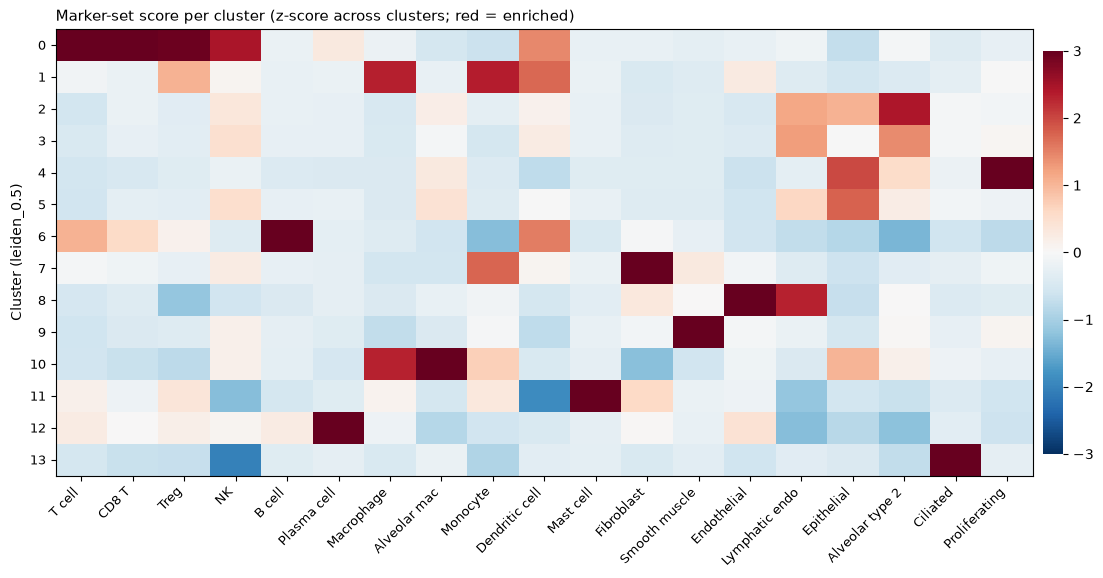

leiden_0.5,0,1,2,3,4,5,6,7,8,9,10,11,12,13
highest-scoring set,CD8 T,Monocyte,Alveolar type 2,Alveolar type 2,Proliferating,Epithelial,B cell,Fibroblast,Endothelial,Smooth muscle,Alveolar mac,Mast cell,Plasma cell,Ciliated
z,3.3,2.4,2.4,1.4,3.4,1.8,3.4,3.1,3.3,3.4,3.2,3.5,3.4,3.4


Automatic 'highest score wins' is a starting point, not an answer: it ignores the panel gaps
and mixed cells. The annotation below is decided cluster by cluster from markers + this heatmap.


In [21]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
PROCESSED_DIR = DATA_ROOT / "processed"
CLUSTERED_PATH = PROCESSED_DIR / f"{SAMPLE}_clustered.h5ad"   # Step 5 output
ANNOTATED_PATH = PROCESSED_DIR / f"{SAMPLE}_annotated.h5ad"   # Step 6 output
CLUSTER_KEY = "leiden_0.5"

adata = sc.read_h5ad(CLUSTERED_PATH)
adata.X = adata.layers["lognorm"]
print(f"Loaded clustered data: {adata.n_obs:,} cells, {adata.obs[CLUSTER_KEY].nunique()} clusters\n")

# ---- Canonical marker sets (literature), restricted to genes on this panel ---------
MARKER_SETS = {
    "T cell":            ["CD3D", "CD3E", "CD2", "TRAC", "CD247", "IL7R", "CD5", "CD6"],
    "CD8 T":             ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "NKG7"],
    "Treg":              ["FOXP3", "IL2RA", "CTLA4", "TNFRSF18", "IKZF2"],
    "NK":                ["KLRD1", "KLRC1", "GNLY", "PRF1", "NCAM1"],
    "B cell":            ["MS4A1", "CD19", "CD79A", "BANK1", "PAX5"],
    "Plasma cell":       ["MZB1", "TNFRSF17", "DERL3", "PRDM1", "JCHAIN", "XBP1"],
    "Macrophage":        ["CD68", "CD163", "MRC1", "MS4A4A", "C1QA", "APOE"],
    "Alveolar mac":      ["MARCO", "MCEMP1", "PPARG", "FABP4"],
    "Monocyte":          ["CD14", "FCN1", "S100A12", "VCAN", "S100A8"],
    "Dendritic cell":    ["CD1C", "FCER1A", "CLEC10A", "LAMP3", "CCR7", "CLEC9A"],
    "Mast cell":         ["CPA3", "KIT", "MS4A2", "TPSAB1"],
    "Fibroblast":        ["PDGFRA", "FBN1", "SFRP2", "MFAP5", "DCN", "LUM", "COL1A1"],
    "Smooth muscle":     ["MYH11", "ACTA2", "CNN1", "DES", "MYLK"],
    "Endothelial":       ["PECAM1", "VWF", "CD34", "CD93", "CLEC14A", "CLDN5"],
    "Lymphatic endo":    ["PROX1", "LYVE1", "MMRN1", "CCL21"],
    "Epithelial":        ["EPCAM", "KRT7", "KRT8", "KRT18", "CEACAM6"],
    "Alveolar type 2":   ["SFTPC", "SFTPB", "NAPSA", "LAMP3", "SFTA2"],
    "Basal / club":      ["KRT5", "TP63", "SCGB1A1", "SCGB3A1"],
    "Ciliated":          ["FOXJ1", "SNTN", "C20orf85", "CCDC39", "CAPS"],
    "Proliferating":     ["MKI67", "TOP2A", "CENPF", "CDK1", "PCNA"],
}
panel = set(adata.var_names)
coverage = pd.DataFrame({
    "on panel": {k: ", ".join(g for g in v if g in panel) for k, v in MARKER_SETS.items()},
    "missing": {k: ", ".join(g for g in v if g not in panel) or "-" for k, v in MARKER_SETS.items()},
    "n on panel": {k: sum(g in panel for g in v) for k, v in MARKER_SETS.items()},
})
display(coverage)
print("The Multi-Tissue panel lacks the classic lung epithelial markers (SFTPC, NAPSA, KRT5, TP63,\n"
      "SCGB1A1): alveolar type 2, basal and club cells CANNOT be resolved here. Annotation is only\n"
      "as good as the panel; always check marker coverage before naming cells.\n")

# ---- Score every cell for every set (mean expression minus a matched random gene set) ----
SETS = {k: [g for g in v if g in panel] for k, v in MARKER_SETS.items()}
SETS = {k: v for k, v in SETS.items() if len(v) >= 2}
for name, genes in SETS.items():
    sc.tl.score_genes(adata, genes, score_name=f"score_{name}", random_state=0)
score_cols = [f"score_{k}" for k in SETS]

# Cluster x cell-type mean score, z-scored across clusters so every column is comparable
cl_scores = adata.obs.groupby(CLUSTER_KEY, observed=True)[score_cols].mean()
cl_scores.columns = list(SETS)
z = (cl_scores - cl_scores.mean()) / cl_scores.std()

fig, ax = plt.subplots(figsize=(13, 5.8))
im = ax.imshow(z.to_numpy(), cmap="RdBu_r", vmin=-3, vmax=3, aspect="auto")
ax.set_xticks(range(z.shape[1]), z.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(z.shape[0]), z.index, fontsize=9)
ax.set_ylabel(f"Cluster ({CLUSTER_KEY})")
ax.set_title("Marker-set score per cluster (z-score across clusters; red = enriched)", loc="left", fontsize=11)
cb = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cb.outline.set_visible(False)
plt.show()

best = z.idxmax(axis=1).rename("highest-scoring set").to_frame()
best["z"] = z.max(axis=1).round(1)
display(best.T)
print("Automatic 'highest score wins' is a starting point, not an answer: it ignores the panel gaps\n"
      "and mixed cells. The annotation below is decided cluster by cluster from markers + this heatmap.")

### 6b. Coarse annotation (one label per cluster)

Epithelial clusters are called **tumour**: the normal alveolar type 1 marker AGER is near zero across the section, and they form large contiguous masses. This is an inference from markers and morphology; confirming malignancy would need copy-number inference or pathology review, which a 377-gene panel cannot support well.

,cell type,lineage,cells
0,T / NK,T / NK,15923
1,Myeloid,Myeloid,12866
10,Myeloid,Myeloid,4937
2,Tumour epithelial (MALL/TCIM),Epithelial,25301
3,Tumour epithelial (CYP2B6/CFTR),Epithelial,27886
5,Tumour epithelial (MYC/CAPN8),Epithelial,27699
4,Proliferating tumour,Epithelial,3826
13,Ciliated epithelial,Epithelial,1028
6,B cell,B / plasma,2313
12,Plasma cell,B / plasma,3607


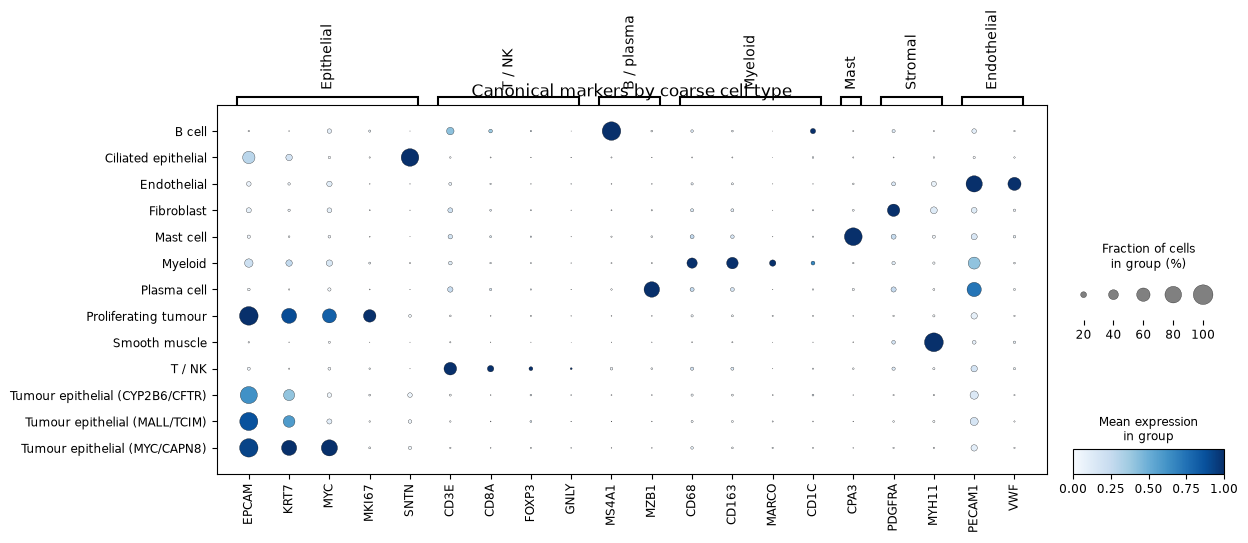

In [22]:
# ---- Coarse annotation: one label per Step 5 cluster ------------------------------
# Decided from the 5d marker table and the 6a heatmap. Epithelial clusters are called
# "tumour" because AGER (normal alveolar type 1) is near zero across the section and
# they form large contiguous masses; without CNV inference this remains an inference.
COARSE = {
    "0":  ("T / NK",                          "T / NK"),     # refined in 6c
    "1":  ("Myeloid",                         "Myeloid"),    # refined in 6d
    "10": ("Myeloid",                         "Myeloid"),    # refined in 6d
    "2":  ("Tumour epithelial (MALL/TCIM)",   "Epithelial"),
    "3":  ("Tumour epithelial (CYP2B6/CFTR)", "Epithelial"),
    "5":  ("Tumour epithelial (MYC/CAPN8)",   "Epithelial"),
    "4":  ("Proliferating tumour",            "Epithelial"),
    "13": ("Ciliated epithelial",             "Epithelial"),
    "6":  ("B cell",                          "B / plasma"),
    "12": ("Plasma cell",                     "B / plasma"),
    "11": ("Mast cell",                       "Mast"),
    "7":  ("Fibroblast",                      "Stromal"),
    "9":  ("Smooth muscle",                   "Stromal"),
    "8":  ("Endothelial",                     "Endothelial"),
}
missing = set(adata.obs[CLUSTER_KEY].cat.categories) - set(COARSE)
assert not missing, f"Clusters without a label: {missing} (did Step 5 change?)"

adata.obs["cell_type_coarse"] = adata.obs[CLUSTER_KEY].map({k: v[0] for k, v in COARSE.items()}).astype("category")
adata.obs["lineage"] = adata.obs[CLUSTER_KEY].map({k: v[1] for k, v in COARSE.items()}).astype("category")

display(pd.DataFrame({k: {"cell type": v[0], "lineage": v[1],
                          "cells": int((adata.obs[CLUSTER_KEY] == k).sum())} for k, v in COARSE.items()}).T)

CANONICAL = {
    "Epithelial": ["EPCAM", "KRT7", "MYC", "MKI67", "SNTN"],
    "T / NK": ["CD3E", "CD8A", "FOXP3", "GNLY"],
    "B / plasma": ["MS4A1", "MZB1"],
    "Myeloid": ["CD68", "CD163", "MARCO", "CD1C"],
    "Mast": ["CPA3"],
    "Stromal": ["PDGFRA", "MYH11"],
    "Endothelial": ["PECAM1", "VWF"],
}
sc.pl.dotplot(adata, CANONICAL, groupby="cell_type_coarse", standard_scale="var", cmap="Blues",
              figsize=(13, 4.8), title="Canonical markers by coarse cell type")

### 6c. T / NK subclusters

Subclustering re-runs PCA, neighbours and Leiden on one lineage only, so differences hidden by the big epithelial signal can surface.

It also exposes **segmentation spillover**, the most important Xenium pitfall: some 'T cell' subclusters are dominated by epithelial, myeloid or fibroblast transcripts. These are T cells pressed against neighbours whose transcripts were assigned to them. They are labelled `... mixed` with `annotation_confidence = 'mixed'`, not discarded. Subclustering also catches mis-clustered populations (mast cells, lymphatic endothelium, mregDCs inside the T cluster).

The label table is checked against each subcluster's top markers: if a re-run ever changes the subcluster numbering, the cell stops with an error instead of silently mislabelling.

,cells,top markers,label,confidence
0,2928,"MS4A6A, MRC1, MS4A4A, AIF1, CD14, MPEG1",T / myeloid mixed,mixed
1,3811,"CCL5, CXCL9, GZMK, CD8A, CXCR4, CCL19",CD8 T (GZMK+),high
2,961,"MALL, EPCAM, TFPI, TCIM, CYP2B6, GPRC5A",T / epithelial mixed,mixed
3,852,"CPA3, KIT, MS4A2, IL1RL1, VWA5A, SLC18A2",Mast cell,high
4,681,"CTLA4, FOXP3, TENT5C, TRAC, PTPRC, SLAMF1",Treg,high
5,2577,"IL7R, CAVIN1, VWF, TRAC, KLRB1, CD34",CD4 T,mixed
6,1822,"LTBP2, FBN1, VCAN, INMT, COL5A2, MYLK",T / fibroblast mixed,mixed
7,633,"GNLY, KLRD1, PRF1, KLRC1, CCL5, NKG7",NK,high
8,316,"MMRN1, PROX1, PDPN, GNG11, TFPI, IL7R",Lymphatic endothelial,high
9,872,"MKI67, TOP2A, CDK1, CENPF, CCNB2, PCNA",Proliferating T,high


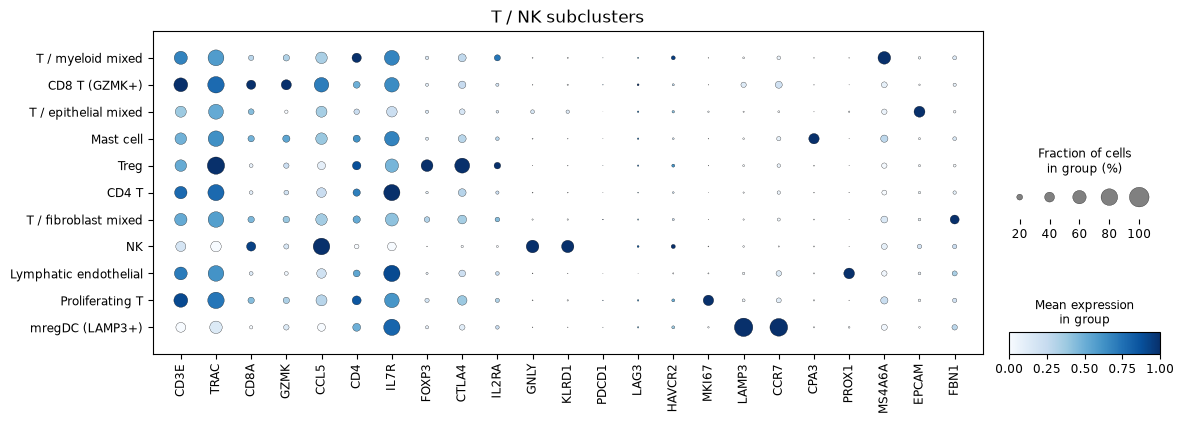

Exhaustion markers (PDCD1, LAG3, HAVCR2) are low and spread out rather than defining a
subcluster: on this panel, T-cell states are better scored per cell (Step 7) than clustered.


In [23]:
def subcluster(clusters, resolution=0.6, n_pcs=20):
    """Re-cluster a subset with its own PCA, so subtle within-lineage differences surface."""
    sub = adata[adata.obs[CLUSTER_KEY].isin(clusters)].copy()
    sub.X = sub.layers["lognorm"].copy()
    sc.pp.scale(sub, max_value=10)
    sc.pp.pca(sub, n_comps=30, svd_solver="arpack", random_state=0)
    sub.X = sub.layers["lognorm"]
    sc.pp.neighbors(sub, n_neighbors=15, n_pcs=n_pcs, random_state=0)
    sc.tl.leiden(sub, resolution=resolution, key_added="sub", flavor="igraph",
                 n_iterations=2, directed=False, random_state=0)
    sc.tl.rank_genes_groups(sub, "sub", method="wilcoxon", layer="lognorm", key_added="sub_markers")
    return sub


def apply_labels(sub, labels):
    """labels: subcluster -> (fine label, confidence, expected marker in the top 10)."""
    top10 = pd.DataFrame(sub.uns["sub_markers"]["names"]).head(10)
    problems = [f"sub {k}: '{exp}' not in top markers {list(top10[k][:5])}"
                for k, (_, _, exp) in labels.items() if exp not in set(top10[k])]
    if problems or set(labels) != set(sub.obs["sub"].cat.categories):
        raise ValueError("Subclusters changed; re-check the label table.\n" + "\n".join(problems))
    table = pd.DataFrame({
        "cells": sub.obs["sub"].value_counts(),
        "top markers": top10.head(6).T.apply(", ".join, axis=1),
        "label": {k: v[0] for k, v in labels.items()},
        "confidence": {k: v[1] for k, v in labels.items()},
    }).loc[sub.obs["sub"].cat.categories]
    sub.obs["cell_type_fine"] = sub.obs["sub"].map({k: v[0] for k, v in labels.items()})
    sub.obs["annotation_confidence"] = sub.obs["sub"].map({k: v[1] for k, v in labels.items()})
    return table


# ---- 6c. T / NK cells (cluster 0) -----------------------------------------------------
tnk = subcluster(["0"])
TNK_LABELS = {   # subcluster: (label, confidence, marker that must be in its top 10)
    "1":  ("CD8 T (GZMK+)",             "high",  "GZMK"),
    "5":  ("CD4 T",                     "mixed", "IL7R"),   # also carries endothelial transcripts
    "4":  ("Treg",                      "high",  "FOXP3"),
    "7":  ("NK",                        "high",  "GNLY"),
    "9":  ("Proliferating T",           "high",  "MKI67"),
    "10": ("mregDC (LAMP3+)",           "high",  "LAMP3"),
    "3":  ("Mast cell",                 "high",  "CPA3"),
    "8":  ("Lymphatic endothelial",     "high",  "PROX1"),
    "0":  ("T / myeloid mixed",         "mixed", "MS4A6A"),
    "2":  ("T / epithelial mixed",      "mixed", "EPCAM"),
    "6":  ("T / fibroblast mixed",      "mixed", "FBN1"),
}
tnk_table = apply_labels(tnk, TNK_LABELS)
display(tnk_table)

T_MARKERS = ["CD3E", "TRAC", "CD8A", "GZMK", "CCL5", "CD4", "IL7R", "FOXP3", "CTLA4", "IL2RA",
             "GNLY", "KLRD1", "PDCD1", "LAG3", "HAVCR2", "MKI67", "LAMP3", "CCR7", "CPA3", "PROX1",
             "MS4A6A", "EPCAM", "FBN1"]
sc.pl.dotplot(tnk, T_MARKERS, groupby="cell_type_fine", standard_scale="var", cmap="Blues",
              figsize=(13, 4.2), title="T / NK subclusters")
print("Exhaustion markers (PDCD1, LAG3, HAVCR2) are low and spread out rather than defining a\n"
      "subcluster: on this panel, T-cell states are better measured per cell (Step 9) than clustered.")

### 6d. Myeloid subclusters

Macrophage diversity matters in tumours: CD163+ and LYVE1+ (tissue-resident / perivascular, often immunosuppressive), CXCL9+ (interferon-activated, recruit T cells), alveolar (MARCO+, lung-resident), plus monocytes and three dendritic-cell types (cDC1, cDC2, mregDC).

,cells,top markers,label,confidence
0,2653,"CD1C, CD1E, CLEC10A, CXCR4, FGL2, FCER1A",cDC2,high
1,202,"MNDA, CLEC4E, SELL, IL1R2, AQP9, BASP1",Monocyte,high
2,1925,"MARCO, MCEMP1, PPARG, VSIG4, PECAM1, FCGR3A",Alveolar macrophage,high
3,1918,"PLA2G7, CD68, FCGR3A, IGSF6, FCGR1A, PMP22",FCGR1A+ macrophage,high
4,3213,"EPCAM, KRT7, GPRC5A, MALL, STEAP4, CAPN8",Myeloid / epithelial mixed,mixed
5,414,"MKI67, TOP2A, CDK1, CENPF, UBE2C, CCNB2",Proliferating myeloid,high
6,1664,"TRAC, IL7R, CD3E, CD2, CCL5, PRDM1",Myeloid / T mixed,mixed
7,2467,"MS4A6A, MS4A4A, CD163, IL2RA, MRC1, CD14",CD163+ macrophage,high
8,2100,"LTBP2, MYLK, INMT, FBN1, COL5A2, PDGFRB",Myeloid / fibroblast mixed,mixed
9,261,"CXCL9, CXCL10, CCL5, IL7R, SERPINB9, CD83",CXCL9+ macrophage,high


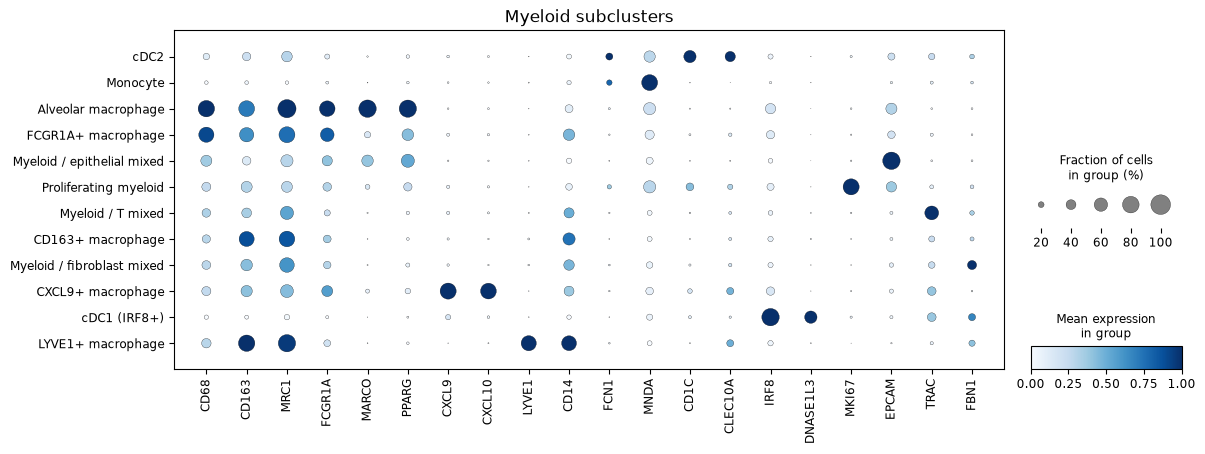

cDC1 vs pDC: IRF8 and DNASE1L3 are shared, but pDC markers LILRA4 and IL3RA are absent here,
so this population is called cDC1.


In [24]:
# ---- 6d. Myeloid cells (clusters 1 + 10) -------------------------------------------
mye = subcluster(["1", "10"])
MYE_LABELS = {
    "7":  ("CD163+ macrophage",         "high",  "CD163"),
    "3":  ("FCGR1A+ macrophage",        "high",  "FCGR1A"),
    "2":  ("Alveolar macrophage",       "high",  "MARCO"),
    "9":  ("CXCL9+ macrophage",         "high",  "CXCL9"),
    "11": ("LYVE1+ macrophage",         "high",  "LYVE1"),
    "1":  ("Monocyte",                  "high",  "MNDA"),
    "0":  ("cDC2",                      "high",  "CD1C"),
    "10": ("cDC1 (IRF8+)",              "high",  "IRF8"),
    "5":  ("Proliferating myeloid",     "high",  "MKI67"),
    "4":  ("Myeloid / epithelial mixed", "mixed", "EPCAM"),
    "6":  ("Myeloid / T mixed",         "mixed", "TRAC"),
    "8":  ("Myeloid / fibroblast mixed", "mixed", "FBN1"),
}
mye_table = apply_labels(mye, MYE_LABELS)
display(mye_table)

M_MARKERS = ["CD68", "CD163", "MRC1", "FCGR1A", "MARCO", "PPARG", "CXCL9", "CXCL10", "LYVE1",
             "CD14", "FCN1", "MNDA", "CD1C", "CLEC10A", "IRF8", "DNASE1L3", "MKI67",
             "EPCAM", "TRAC", "FBN1"]
sc.pl.dotplot(mye, M_MARKERS, groupby="cell_type_fine", standard_scale="var", cmap="Blues",
              figsize=(13, 4.4), title="Myeloid subclusters")
print("cDC1 vs pDC: IRF8 and DNASE1L3 are shared, but pDC markers LILRA4 and IL3RA are absent here,\n"
      "so this population is called cDC1.")

### 6e. Final labels, composition, tissue map, save

`obs['cell_type']` (33 labels), `obs['lineage']` (7 groups) and `obs['annotation_confidence']` (`high` / `mixed`) are saved with the per-set scores. About 10% of cells are `mixed`: keep them for spatial maps, exclude them from per-cell-type statistics.

In the tissue map, look for the **B / plasma aggregates** (around x 4.4 / y 2.4 mm and x 7 / y 2 mm) ringed by T cells: candidate tertiary lymphoid structures, a key feature for the spatial analysis in Step 7. The lineage colours are a colourblind-checked palette in fixed order.

cells  % of cells
lineage     cell_type                                         
B / plasma  Plasma cell                       3607        2.34
            B cell                            2313        1.50
Endothelial Endothelial                       9094        5.89
            Lymphatic endothelial              316        0.20
Epithelial  Tumour epithelial (CYP2B6/CFTR)  27886       18.06
            Tumour epithelial (MYC/CAPN8)    27699       17.94
            Tumour epithelial (MALL/TCIM)    25301       16.39
            Proliferating tumour              3826        2.48
            Ciliated epithelial               1028        0.67
Mast        Mast cell                         2443        1.58
Myeloid     Myeloid / epithelial mixed        3213        2.08
            cDC2                              2653        1.72
            CD163+ macrophage                 2467        1.60
            Myeloid / fibroblast mixed        2100        1.36
            Alveolar macrophage               1925        1.25
            FCGR1A+ macrophage                1918        1.24
            Myeloid / T mixed                 1664        1.08
            cDC1 (IRF8+)                       618        0.40
            mregDC (LAMP3+)                    470        0.30
            Proliferating myeloid              414        0.27
            LYVE1+ macrophage                  368        0.24
            CXCL9+ macrophage                  261        0.17
            Monocyte                           202        0.13
Stromal     Fibroblast                       15944       10.33
            Smooth muscle                     2379        1.54
T / NK      CD8 T (GZMK+)                     3811        2.47
            T / myeloid mixed                 2928        1.90
            CD4 T                             2577        1.67
            T / fibroblast mixed              1822        1.18
            T / epithelial mixed               961        0.62
            Proliferating T                    872        0.56
            Treg                               681        0.44
            NK                                 633        0.41

33 cell types; 9.9% of cells are flagged 'mixed' (segmentation spillover). Keep them for maps, exclude them from per-cell-type statistics.



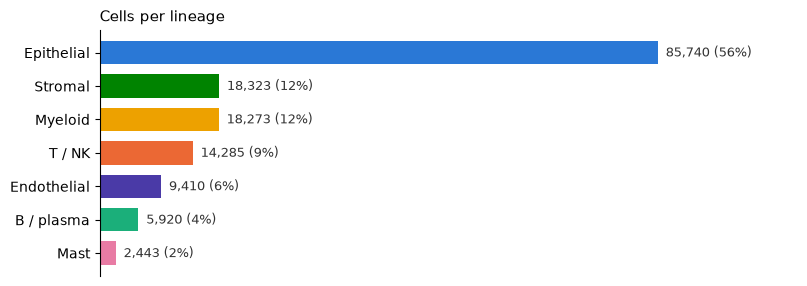

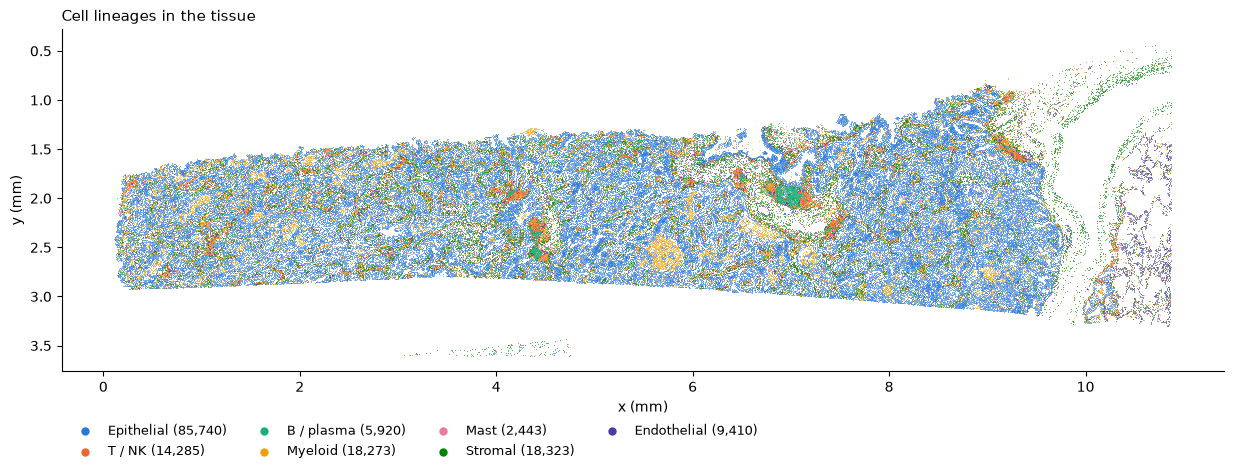

Saved: ~/data/xenium_lung/processed/Xenium_V1_humanLung_Cancer_FFPE_annotated.h5ad (127 MB) with obs['cell_type'], obs['lineage'], obs['annotation_confidence'] and per-set scores.


In [25]:
# ---- 6e. Merge fine labels back, summarise, map, save -----------------------------
fine = adata.obs["cell_type_coarse"].astype(str)
conf = pd.Series("high", index=adata.obs_names)
for sub in (tnk, mye):
    fine.loc[sub.obs_names] = sub.obs["cell_type_fine"].astype(str)
    conf.loc[sub.obs_names] = sub.obs["annotation_confidence"].astype(str)
adata.obs["cell_type"] = pd.Categorical(fine)
adata.obs["annotation_confidence"] = pd.Categorical(conf)

# Lineage follows the final label (e.g. mast cells found inside the T cluster become "Mast")
LINEAGE = {
    "CD8 T (GZMK+)": "T / NK", "CD4 T": "T / NK", "Treg": "T / NK", "NK": "T / NK",
    "Proliferating T": "T / NK", "T / myeloid mixed": "T / NK", "T / epithelial mixed": "T / NK",
    "T / fibroblast mixed": "T / NK", "mregDC (LAMP3+)": "Myeloid", "Mast cell": "Mast",
    "Lymphatic endothelial": "Endothelial",
}
lineage = adata.obs["cell_type"].astype(str).map(LINEAGE)
for sub in (mye,):
    lineage.loc[sub.obs_names] = "Myeloid"
lineage = lineage.fillna(adata.obs["lineage"].astype(str))
adata.obs["lineage"] = pd.Categorical(lineage)

comp = (adata.obs.groupby(["lineage", "cell_type"], observed=True).size().rename("cells")
        .reset_index().sort_values(["lineage", "cells"], ascending=[True, False]))
comp["% of cells"] = (100 * comp["cells"] / adata.n_obs).round(2)
display(comp.set_index(["lineage", "cell_type"]))
mixed = (adata.obs["annotation_confidence"] == "mixed").mean()
print(f"{adata.obs['cell_type'].nunique()} cell types; {mixed:.1%} of cells are flagged 'mixed' "
      "(segmentation spillover). Keep them for maps, exclude them from per-cell-type statistics.\n")

# ---- Composition bar + tissue map by lineage ------------------------------------------
# Colourblind-checked categorical palette, assigned in fixed order (reused in later steps)
LINEAGE_COLORS = {
    "Epithelial": "#2a78d6", "T / NK": "#eb6834", "B / plasma": "#1baf7a", "Myeloid": "#eda100",
    "Mast": "#e87ba4", "Stromal": "#008300", "Endothelial": "#4a3aa7",
}
counts = adata.obs["lineage"].value_counts()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(counts.index[::-1], counts.values[::-1], color=[LINEAGE_COLORS[l] for l in counts.index[::-1]], height=0.7)
for y, v in enumerate(counts.values[::-1]):
    ax.text(v, y, f"  {v:,} ({v / adata.n_obs:.0%})", va="center", fontsize=9, color="#333333")
ax.set_xlim(0, counts.max() * 1.25)
ax.set_xticks([])
ax.set_title("Cells per lineage", loc="left", fontsize=11)
for s in ("top", "right", "bottom"):
    ax.spines[s].set_visible(False)
plt.show()

xy = adata.obsm["spatial"] / 1000
fig, ax = plt.subplots(figsize=(15, 5.6))
for lin, col in LINEAGE_COLORS.items():
    m = (adata.obs["lineage"] == lin).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], s=0.25, c=col, linewidths=0, rasterized=True,
               label=f"{lin} ({m.sum():,})")
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
ax.legend(markerscale=12, frameon=False, ncol=4, loc="upper left", bbox_to_anchor=(0, -0.12), fontsize=9)
ax.set_title("Cell lineages in the tissue", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

# ---- Save ---------------------------------------------------------------------------------
adata.uns["annotation"] = {
    "coarse_from": CLUSTER_KEY, "subclustered": {"T_NK": ["0"], "Myeloid": ["1", "10"]},  # HDF5 keys cannot contain "/"
    "subcluster_resolution": 0.6,
    "caveats": "Multi-Tissue panel lacks SFTPC/NAPSA/KRT5/TP63/SCGB1A1; tumour call is inferred "
               "(AGER-negative contiguous epithelium), not CNV-confirmed.",
}
adata.uns["lineage_colors"] = [LINEAGE_COLORS[l] for l in adata.obs["lineage"].cat.categories]
adata.write_h5ad(ANNOTATED_PATH, compression="gzip")
print(f"Saved: ~/data/xenium_lung/processed/{ANNOTATED_PATH.name} "
      f"({ANNOTATED_PATH.stat().st_size / 1e6:.0f} MB) with obs['cell_type'], obs['lineage'], "
      "obs['annotation_confidence'] and per-set scores.")

## Step 7: Spatial analysis of the tumour immune microenvironment

This is what spatial data adds over single-cell RNA-seq: **where** cells are relative to each other. Four questions, each a standard analysis:

| Part | Question | Method |
|---|---|---|
| 7b | Which cell types touch more (or less) than chance? | Neighbourhood enrichment (squidpy, permutation test) |
| 7c | What recurring local tissue 'neighbourhoods' exist? | Cellular niches: k-means on each cell's 50 µm neighbourhood composition |
| 7d | Do immune cells reach the tumour, or are they kept out? | Distance of each cell to the nearest tumour cell, vs. a baseline |
| 7e | Are there tertiary lymphoid structures (TLS)? | Density clustering (DBSCAN) of B cells, then composition of each aggregate |

Only `annotation_confidence == 'high'` cells are used (the ~10% `mixed` spillover cells would blur contacts). Step 7 starts from the Step 6 file and runs in ~30 s.

### 7a. Spatial neighbour graph

Delaunay triangulation links each cell to its natural neighbours without choosing a radius or k; edges longer than 30 µm (bridging gaps or tissue edges) are removed. The window plot shows the graph around the largest B-cell aggregate.

In [ ]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
from IPython.display import display
from matplotlib.collections import LineCollection
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
PROCESSED_DIR = DATA_ROOT / "processed"
ANNOTATED_PATH = PROCESSED_DIR / f"{SAMPLE}_annotated.h5ad"   # Step 6 output
SPATIAL_PATH = PROCESSED_DIR / f"{SAMPLE}_spatial.h5ad"       # Step 7 output

MAX_EDGE_UM = 30   # drop graph edges longer than this: they bridge gaps, not real contacts

full = sc.read_h5ad(ANNOTATED_PATH)
# Spatial statistics use high-confidence cells only; 'mixed' spillover cells would blur contacts
adata = full[full.obs["annotation_confidence"] == "high"].copy()
LINEAGE_COLORS = dict(zip(full.obs["lineage"].cat.categories, full.uns["lineage_colors"]))
print(f"{adata.n_obs:,} high-confidence cells of {full.n_obs:,} "
      f"({(full.obs['annotation_confidence'] == 'mixed').sum():,} 'mixed' excluded from statistics)\n")

# ---- Spatial neighbour graph: Delaunay triangulation, pruned at MAX_EDGE_UM ----------
# Delaunay connects each cell to its natural touching neighbours without choosing k or a
# radius; pruning removes the long edges it draws across empty space and tissue gaps.
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
conn = adata.obsp["spatial_connectivities"].tocsr()
dist = adata.obsp["spatial_distances"].tocsr()
long_edges = dist.data > MAX_EDGE_UM
print(f"Delaunay edges: {dist.nnz:,}; median length {np.median(dist.data):.1f} um; "
      f"{long_edges.mean():.1%} longer than {MAX_EDGE_UM} um removed")
conn.data[long_edges] = 0
dist.data[long_edges] = 0
conn.eliminate_zeros()
dist.eliminate_zeros()
adata.obsp["spatial_connectivities"], adata.obsp["spatial_distances"] = conn, dist
degree = conn.getnnz(axis=1)
print(f"Neighbours per cell after pruning: median {np.median(degree):.0f}, mean {degree.mean():.1f}; "
      f"isolated cells: {(degree == 0).sum()}")

# ---- Look at the graph on a 300 x 300 um window -------------------------------------------
xy = adata.obsm["spatial"]
x0, y0, w = 6850, 1800, 300   # window around the largest B-cell aggregate
win = (xy[:, 0] > x0) & (xy[:, 0] < x0 + w) & (xy[:, 1] > y0) & (xy[:, 1] < y0 + w)
idx = np.where(win)[0]
sub = conn[idx][:, idx].tocoo()
segs = np.stack([xy[idx[sub.row]], xy[idx[sub.col]]], axis=1)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.add_collection(LineCollection(segs, colors="#b9bec5", linewidths=0.5, zorder=1))
for lin, col in LINEAGE_COLORS.items():
    m = (adata.obs["lineage"].to_numpy()[idx] == lin)
    ax.scatter(xy[idx[m], 0], xy[idx[m], 1], s=14, c=col, edgecolors="white", linewidths=0.4,
               zorder=2, label=lin)
ax.set_xlim(x0, x0 + w); ax.set_ylim(y0 + w, y0)
ax.set_aspect("equal")
ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
ax.set_title("Spatial graph on a 300 um window (edges = neighbours)", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

### 7b. Neighbourhood enrichment

For every pair of cell types, count how often they are graph neighbours, then compare with 1,000 random shufflings of the labels. z > 0 (red): together more than chance; z < 0 (blue): apart.

What this tissue shows:
- **CD8 T cells co-localise most with mregDCs (LAMP3+) and B cells**: immune hubs where antigen-presenting cells meet T cells, the hallmark of TLS.
- **The three tumour epithelial groups avoid each other**: they are separate regions of the tumour, not intermixed states.
- **Fibroblasts and endothelium avoid tumour cells** but pair with each other, and CD163+ macrophages sit with plasma cells and fibroblasts in the stroma.

CD4 T cells are absent because Step 6 flagged them `mixed` (endothelial spillover).

In [ ]:
N_PERMS = 1000  # random label shuffles that define "expected by chance"


def enrichment_heatmap(key, title, order=None, clip=50, size=(7.5, 6)):
    sq.gr.nhood_enrichment(adata, cluster_key=key, n_perms=N_PERMS, seed=0, show_progress_bar=False)
    cats = adata.obs[key].cat.categories
    z = pd.DataFrame(adata.uns[f"{key}_nhood_enrichment"]["zscore"], index=cats, columns=cats)
    if order is not None:
        z = z.loc[order, order]
    fig, ax = plt.subplots(figsize=size)
    im = ax.imshow(z.clip(-clip, clip).to_numpy(), cmap="RdBu_r", vmin=-clip, vmax=clip)
    ax.set_xticks(range(len(z)), z.columns, rotation=45, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(z)), z.index, fontsize=8.5)
    ax.set_title(title, loc="left", fontsize=11)
    cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cb.set_label(f"z-score (clipped at +/-{clip})", fontsize=9)
    cb.outline.set_visible(False)
    plt.show()
    return z


# ---- Lineage level ------------------------------------------------------------------
z_lin = enrichment_heatmap("lineage", "Neighbourhood enrichment between lineages")
print("Red = these two cell groups touch more often than if labels were shuffled; blue = they avoid\n"
      "each other. Diagonal red = cells cluster with their own kind (tissue compartments).\n"
      "With ~140k cells even small effects give huge z-scores: read the pattern, not the magnitude.\n")

# ---- Tumour-immune cell types ---------------------------------------------------------
TIME_TYPES = ["Tumour epithelial (MALL/TCIM)", "Tumour epithelial (CYP2B6/CFTR)", "Tumour epithelial (MYC/CAPN8)",
              "Proliferating tumour", "CD8 T (GZMK+)", "CD4 T", "Treg", "NK", "B cell", "Plasma cell",
              "CD163+ macrophage", "FCGR1A+ macrophage", "CXCL9+ macrophage", "Alveolar macrophage",
              "cDC2", "mregDC (LAMP3+)", "Fibroblast", "Endothelial"]
present = set(adata.obs["cell_type"])
dropped = [t for t in TIME_TYPES if t not in present]
TIME_TYPES = [t for t in TIME_TYPES if t in present]
if dropped:
    print(f"Not in the high-confidence set (flagged 'mixed' in Step 6): {', '.join(dropped)}\n")
adata.obs["time_type"] = pd.Categorical(
    adata.obs["cell_type"].astype(str).where(adata.obs["cell_type"].isin(TIME_TYPES), "other"))
z_ct = enrichment_heatmap("time_type", "Neighbourhood enrichment, tumour-immune cell types",
                          order=TIME_TYPES, clip=30, size=(10, 8.5))

pairs = (z_ct.where(~np.eye(len(z_ct), dtype=bool)).stack().rename("z").reset_index()
         .rename(columns={"level_0": "cell type A", "level_1": "cell type B"}))
pairs = pairs[pairs["cell type A"] < pairs["cell type B"]]
print("Strongest co-localised pairs (excluding self):")
display(pairs.nlargest(8, "z").round(1).reset_index(drop=True))
print("Strongest avoiding pairs:")
display(pairs.nsmallest(5, "z").round(1).reset_index(drop=True))

### 7c. Cellular niches

Each cell is described by the lineage mix within 50 µm (~70 cells); k-means groups these into 10 niches, named automatically by their dominant lineages and ordered from tumour core outwards.

Reading the maps: **N1** is solid tumour nests; **N2, N3 and N5** are the tumour-stroma interfaces that ring them; **N4** is myeloid-rich patches inside the tumour; **N7** (T-cell rich) and **N8** (B-cell rich) are the immune hubs and TLS; **N9** is fibrous stroma along the tissue edge; **N10** is vascular.

In [ ]:
from sklearn.cluster import MiniBatchKMeans

NICHE_RADIUS_UM = 50   # neighbourhood window for each cell
N_NICHES = 10

# ---- Each cell's neighbourhood composition (fraction of each lineage within 50 um) ----
lineages = list(adata.obs["lineage"].cat.categories)
codes = adata.obs["lineage"].cat.codes.to_numpy()
neigh = cKDTree(xy).query_ball_point(xy, r=NICHE_RADIUS_UM)
comp = np.zeros((adata.n_obs, len(lineages)))
for i, nb in enumerate(neigh):
    comp[i] = np.bincount(codes[nb], minlength=len(lineages))
comp /= comp.sum(axis=1, keepdims=True)
print(f"Median cells per {NICHE_RADIUS_UM} um neighbourhood: {np.median([len(n) for n in neigh]):.0f}")

# ---- Cluster neighbourhoods into niches (cellular neighbourhoods, Schurch et al. 2020) ----
km = MiniBatchKMeans(n_clusters=N_NICHES, random_state=0, n_init=10, batch_size=8192).fit(comp)
centres = pd.DataFrame(km.cluster_centers_, columns=lineages)


def niche_name(row):
    """Name a niche by its dominant lineages, e.g. 'Epithelial 91%' or 'T / NK 46% + B / plasma 14%'."""
    top = row.sort_values(ascending=False)
    if top.iloc[0] >= 0.85:
        return f"{top.index[0]} {top.iloc[0]:.0%}"
    return f"{top.index[0]} {top.iloc[0]:.0%} + {top.index[1]} {top.iloc[1]:.0%}"


order = centres["Epithelial"].sort_values(ascending=False).index   # tumour core first
names = {old: f"N{new + 1}: {niche_name(centres.loc[old])}" for new, old in enumerate(order)}
adata.obs["niche"] = pd.Categorical([names[l] for l in km.labels_], categories=[names[o] for o in order])
centres = centres.loc[order]
centres.index = [names[o] for o in order]
centres["cells"] = adata.obs["niche"].value_counts().reindex(centres.index).to_numpy()

fig, ax = plt.subplots(figsize=(9, 5.2))
im = ax.imshow(centres[lineages].to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(lineages)), lineages, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(centres)), [f"{n}  ({c:,})" for n, c in zip(centres.index, centres.cells)], fontsize=8.5)
for (i, j), v in np.ndenumerate(centres[lineages].to_numpy()):
    if v >= 0.1:
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7.5, color="white" if v > 0.55 else "#222222")
ax.set_title(f"Niche composition (mean lineage fraction within {NICHE_RADIUS_UM} um)", loc="left", fontsize=11)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.outline.set_visible(False)
plt.show()

# ---- Where each niche sits: one panel per niche --------------------------------------------
xmm, ymm = xy[:, 0] / 1000, xy[:, 1] / 1000
fig, axes = plt.subplots(5, 2, figsize=(15, 9.5), sharex=True, sharey=True)
niche_arr = adata.obs["niche"].to_numpy()
for ax, n in zip(axes.flat, adata.obs["niche"].cat.categories):
    m = niche_arr == n
    ax.scatter(xmm[~m], ymm[~m], s=0.04, c="#e3e6ea", linewidths=0, rasterized=True)
    ax.scatter(xmm[m], ymm[m], s=0.2, c="#2a78d6", linewidths=0, rasterized=True)
    ax.set_title(f"{n}  ({m.mean():.0%} of cells)", loc="left", fontsize=9)
axes.flat[0].invert_yaxis()
for ax in axes.flat:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
plt.tight_layout()
plt.show()

### 7d. Immune infiltration vs. exclusion

For every cell, the distance to the nearest tumour cell. A cell type counts as **infiltrating** or **excluded** relative to the baseline of all non-tumour cells (34% within 15 µm).

The result is an **immune-excluded pattern for lymphocytes**: CD8 T cells (median 37 µm, 12% in contact) and B cells (45 µm) stay further from the tumour than the baseline, while alveolar and FCGR1A+ macrophages, cDC2 and fibroblasts are in direct contact (50-68% within 15 µm). The tumour border is dominated by myeloid and stromal cells. LYVE1+ macrophages are furthest away (median 120 µm), consistent with a perivascular, tissue-resident niche.

In [ ]:
# ---- Distance from every cell to the nearest tumour cell ----------------------------
TUMOUR_TYPES = ["Tumour epithelial (MALL/TCIM)", "Tumour epithelial (CYP2B6/CFTR)",
                "Tumour epithelial (MYC/CAPN8)", "Proliferating tumour"]
CONTACT_UM = 15   # within ~2 cell diameters = in contact with tumour
is_tumour = adata.obs["cell_type"].isin(TUMOUR_TYPES).to_numpy()
d_tumour, _ = cKDTree(xy[is_tumour]).query(xy, k=1)
adata.obs["dist_to_tumour_um"] = d_tumour

# Baseline: all non-tumour cells. A type is 'excluded' if it sits further away than that.
nontum = ~is_tumour
base_median = np.median(d_tumour[nontum])
base_contact = (d_tumour[nontum] <= CONTACT_UM).mean()

IMMUNE_TYPES = ["CD8 T (GZMK+)", "CD4 T", "Treg", "NK", "B cell", "Plasma cell", "CD163+ macrophage",
                "FCGR1A+ macrophage", "CXCL9+ macrophage", "Alveolar macrophage", "LYVE1+ macrophage",
                "cDC1 (IRF8+)", "cDC2", "mregDC (LAMP3+)"]
g = adata.obs[adata.obs["cell_type"].isin(IMMUNE_TYPES + ["Fibroblast"])].groupby("cell_type", observed=True)["dist_to_tumour_um"]
infil = pd.DataFrame({
    "cells": g.size(),
    "median distance (um)": g.median(),
    f"% within {CONTACT_UM} um": 100 * g.apply(lambda d: (d <= CONTACT_UM).mean()),
    "% beyond 100 um": 100 * g.apply(lambda d: (d > 100).mean()),
})
infil["vs. baseline"] = np.where(infil[f"% within {CONTACT_UM} um"] > 100 * base_contact * 1.2, "infiltrating",
                         np.where(infil[f"% within {CONTACT_UM} um"] < 100 * base_contact * 0.8, "excluded", "similar"))
infil = infil.sort_values("median distance (um)")
missing = [t for t in IMMUNE_TYPES if t not in set(adata.obs["cell_type"])]
if missing:
    print(f"Not analysed (flagged 'mixed' in Step 6): {', '.join(missing)}")
print(f"Baseline (all non-tumour cells): median {base_median:.1f} um, "
      f"{base_contact:.0%} within {CONTACT_UM} um of a tumour cell\n")
display(infil.style.format({"cells": "{:,}", "median distance (um)": "{:.1f}",
                            f"% within {CONTACT_UM} um": "{:.0f}", "% beyond 100 um": "{:.0f}"}))

# ---- Cumulative distance curves for key players ----------------------------------------
CURVES = {  # fixed palette order
    "CD8 T (GZMK+)": "#2a78d6", "Treg": "#eb6834", "B cell": "#1baf7a",
    "CD163+ macrophage": "#eda100", "Alveolar macrophage": "#e87ba4", "Fibroblast": "#008300",
}
fig, ax = plt.subplots(figsize=(9, 4.6))
grid = np.linspace(0, 150, 301)
base = np.searchsorted(np.sort(d_tumour[nontum]), grid) / nontum.sum()
# legend ordered closest -> furthest (curves converge at the right, so no end labels)
for ct in sorted(CURVES, key=lambda c: infil.loc[c, "median distance (um)"]):
    d = np.sort(adata.obs.loc[adata.obs["cell_type"] == ct, "dist_to_tumour_um"].to_numpy())
    y = np.searchsorted(d, grid) / len(d) * 100
    ax.plot(grid, y, color=CURVES[ct], lw=2, label=f"{ct} (median {np.median(d):.0f} um)")
ax.plot(grid, base * 100, color="#898781", lw=1.5, ls="--", label=f"all non-tumour (median {base_median:.0f} um)")
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.axvline(CONTACT_UM, color="#c3c2b7", lw=1)
ax.set_xlim(0, 150); ax.set_ylim(0, 100)
ax.set_xlabel("Distance to nearest tumour cell (um)")
ax.set_ylabel("% of cells within distance")
ax.set_title("How close each cell type gets to the tumour (left/higher = closer)", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()
print("CD8 T cells sit further from tumour than the baseline (immune-excluded pattern), while\n"
      "macrophages, cDC2 and fibroblasts are in direct contact: the tumour border is myeloid/stromal.")

### 7e. Tertiary lymphoid structure (TLS)-like aggregates

TLS are organised immune aggregates that form in chronically inflamed tissue and tumours; in lung cancer their presence is associated with better outcomes and response to immunotherapy. Here, 71% of B cells fall into **6 dense aggregates**, stable across DBSCAN settings (eps 20-30 µm). Each has a B-cell core, a T-cell rim (17-50% T/NK), mregDCs and CCL19-expressing cells, and almost no tumour cells (0-7%).

They are called **TLS-like**: the markers used to stage TLS maturity (CXCL13, CR2 on follicular dendritic cells, PNAd high endothelial venules) are not on this panel.

In [ ]:
from matplotlib.patches import Circle
from sklearn.cluster import DBSCAN

# ---- Tertiary lymphoid structure (TLS)-like aggregates: dense clusters of B cells ----
TLS_EPS_UM = 25        # B cells within 25 um chain into one aggregate
TLS_MIN_B = 20         # an aggregate needs >= 20 B cells (core points)
is_b = (adata.obs["cell_type"] == "B cell").to_numpy()
b_xy = xy[is_b]
labels = DBSCAN(eps=TLS_EPS_UM, min_samples=TLS_MIN_B).fit_predict(b_xy)
print(f"{(labels >= 0).sum():,} of {is_b.sum():,} B cells ({(labels >= 0).mean():.0%}) fall in "
      f"{labels.max() + 1} dense aggregates (DBSCAN eps={TLS_EPS_UM} um, min_samples={TLS_MIN_B})\n")

adata.obs["tls_id"] = "none"
rows = []
for k in pd.Series(labels[labels >= 0]).value_counts().index:      # largest first
    pts = b_xy[labels == k]
    centre = pts.mean(axis=0)
    radius = np.percentile(np.linalg.norm(pts - centre, axis=1), 90) + 20   # B core + 20 um rim
    inside = np.linalg.norm(xy - centre, axis=1) <= radius
    tls = f"TLS{len(rows) + 1}"
    adata.obs.loc[inside, "tls_id"] = tls
    ct_in = adata.obs.loc[inside, "cell_type"]
    rows.append({
        "TLS": tls, "x (mm)": centre[0] / 1000, "y (mm)": centre[1] / 1000, "radius (um)": radius,
        "cells": int(inside.sum()), "% B": 100 * (ct_in == "B cell").mean(),
        "% T / NK": 100 * (adata.obs.loc[inside, "lineage"] == "T / NK").mean(),
        "% tumour": 100 * ct_in.isin(TUMOUR_TYPES).mean(),
        "mregDC": int((ct_in == "mregDC (LAMP3+)").sum()),
        "CCL19+ cells": int((adata[inside, "CCL19"].layers["counts"] > 0).sum()),
    })
adata.obs["tls_id"] = pd.Categorical(adata.obs["tls_id"])
tls_table = pd.DataFrame(rows).set_index("TLS")
display(tls_table.style.format({"x (mm)": "{:.2f}", "y (mm)": "{:.2f}", "radius (um)": "{:.0f}",
                                "% B": "{:.0f}", "% T / NK": "{:.0f}", "% tumour": "{:.0f}"}))
print("All aggregates are B-cell cores with a T-cell rim, mregDCs and CCL19 (a lymphoid-homing\n"
      "chemokine), and almost no tumour cells: TLS-like. Mature-TLS markers (CXCL13, CR2 for\n"
      "follicular dendritic cells, PNAd venules) are not on this panel, so maturity cannot be staged.")

# ---- Map: lineages with the aggregates circled, and a zoom on the largest -------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [2.6, 1]})
for lin, col in LINEAGE_COLORS.items():
    m = (adata.obs["lineage"] == lin).to_numpy()
    for ax in axes:
        ax.scatter(xy[m, 0] / 1000, xy[m, 1] / 1000, s=0.15 if ax is axes[0] else 3, c=col,
                   linewidths=0, rasterized=True, label=lin)
for tls, r in tls_table.iterrows():
    axes[0].add_patch(Circle((r["x (mm)"], r["y (mm)"]), r["radius (um)"] / 1000 + 0.05, fill=False,
                             edgecolor="#0b0b0b", lw=1.2))
    axes[0].annotate(tls, (r["x (mm)"] - r["radius (um)"] / 1000 - 0.08, r["y (mm)"]), ha="right",
                     va="center", fontsize=8.5, weight="bold")   # label left of its circle
big = tls_table.iloc[0]
pad = big["radius (um)"] / 1000 + 0.1
axes[1].set_xlim(big["x (mm)"] - pad, big["x (mm)"] + pad)
axes[1].set_ylim(big["y (mm)"] + pad, big["y (mm)"] - pad)
axes[0].invert_yaxis()
axes[0].set_title("TLS-like aggregates (circled) on the lineage map", loc="left", fontsize=11)
axes[1].set_title(f"Zoom: {tls_table.index[0]}", loc="left", fontsize=11)
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlabel("x (mm)")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("y (mm)")
axes[1].legend(markerscale=4, frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

### 7f. Save

Saved to `~/data/xenium_lung/processed/` with `niche`, `dist_to_tumour_um`, `tls_id` and the spatial graph, for downstream work (e.g. comparing gene expression of CD8 T cells inside vs. outside TLS, or H&E-guided region analysis in Step 8).

In [ ]:
# ---- Save spatial results (high-confidence cells) -------------------------------------
adata.uns["step7_params"] = {
    "graph": f"Delaunay, edges > {MAX_EDGE_UM} um removed", "nhood_perms": N_PERMS,
    "niche_radius_um": NICHE_RADIUS_UM, "n_niches": N_NICHES, "contact_um": CONTACT_UM,
    "tls_dbscan": {"eps_um": TLS_EPS_UM, "min_samples": TLS_MIN_B},
    "cells": "annotation_confidence == 'high' only",
}
for key in ["lineage_nhood_enrichment", "time_type_nhood_enrichment"]:
    adata.uns.pop(key, None)   # large permutation results; recompute when needed
adata.write_h5ad(SPATIAL_PATH, compression="gzip")
print(f"Saved: ~/data/xenium_lung/processed/{SPATIAL_PATH.name} ({SPATIAL_PATH.stat().st_size / 1e6:.0f} MB)")
print("New in .obs: niche, dist_to_tumour_um, tls_id, time_type; spatial graph in .obsp.")

## Step 8: H&E alignment

The H&E slide is the same tissue section, stained after the Xenium run and scanned separately, so it is rotated (~90°) and at a different pixel size (~0.27 vs. 0.2125 µm). 10x provides a 3x3 affine matrix (`he_imagealignment.csv`) that maps **H&E pixels → Xenium morphology pixels**. Aligning the two lets every Xenium cell call be read against the histology a pathologist uses.

### 8a. The alignment matrix and the raw images

`spatialdata_io.xenium_aligned_image` attaches the matrix as an `Affine` transform, the SpatialData way to place an image in the Xenium coordinate system. It loads the full-resolution image as one 2 GB block, so the rest of this step reads pixels from the file's own pyramid (`tifffile`) and applies the matrix explicitly. Mapping the image corners confirms the direction of the matrix.

In [ ]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import tifffile
import zarr
from IPython.display import display
from skimage.color import rgb2hed
from skimage.transform import warp
from spatialdata_io import xenium_aligned_image

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
SAMPLE_DIR = DATA_ROOT / SAMPLE
PROCESSED_DIR = DATA_ROOT / "processed"
HE_PATH = SAMPLE_DIR / f"{SAMPLE}_he_image.ome.tif"
ALIGN_PATH = SAMPLE_DIR / f"{SAMPLE}_he_imagealignment.csv"
DAPI_PATH = SAMPLE_DIR / "outs" / "morphology_focus" / "morphology_focus_0000.ome.tif"
SPATIAL_PATH = PROCESSED_DIR / f"{SAMPLE}_spatial.h5ad"     # Step 7 output
HE_FEATURES_PATH = PROCESSED_DIR / f"{SAMPLE}_he_features.h5ad"  # Step 8 output
PIXEL_SIZE = 0.2125  # um per Xenium morphology pixel

# ---- The alignment matrix: H&E pixel -> Xenium morphology pixel ----------------------
M = np.loadtxt(ALIGN_PATH, delimiter=",")
he_img = xenium_aligned_image(HE_PATH, ALIGN_PATH)   # the SpatialData way: image + its transform
print("spatialdata-io attaches the matrix as an Affine transform to the 'global' (Xenium pixel) frame:")
print(sd.transformations.get_transformation(he_img), "\n")

with tifffile.TiffFile(HE_PATH) as tif:
    he_levels = [lvl.shape for lvl in tif.series[0].levels]
H0, W0 = he_levels[0][:2]
corners = np.array([[0, 0, 1], [W0, 0, 1], [0, H0, 1], [W0, H0, 1]], dtype=float).T
print(f"H&E: {W0:,} x {H0:,} px, {len(he_levels)} pyramid levels. Its corners land at Xenium pixels:")
print(pd.DataFrame((M @ corners)[:2].T.round(0), columns=["x", "y"],
                   index=["top-left", "top-right", "bottom-left", "bottom-right"]))
print("The Xenium frame is ~51,200 x 17,100 px, so M maps H&E -> Xenium (its inverse maps Xenium -> H&E).")
print("Note: xenium_aligned_image loads only full resolution (one 2 GB block). Below, pixels are read")
print("from the file's own pyramid with tifffile, and the matrix is applied explicitly.\n")

# ---- Raw thumbnails: why alignment is needed ------------------------------------------------
with tifffile.TiffFile(HE_PATH) as tif:
    he_thumb = tif.series[0].levels[4].asarray()
with tifffile.TiffFile(DAPI_PATH) as tif:
    dapi_thumb = tif.series[0].levels[4].asarray()[0]    # channel 0 = DAPI
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 3.2]})
axes[0].imshow(he_thumb)
axes[0].set_title("H&E as scanned", loc="left", fontsize=11)
lo, hi = np.percentile(dapi_thumb[dapi_thumb > 0], [1, 99.5])
axes[1].imshow(np.clip((dapi_thumb - lo) / (hi - lo), 0, 1), cmap="gray")
axes[1].set_title("Xenium DAPI (same section, different scanner and orientation)", loc="left", fontsize=11)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

### 8b. Warp H&E into the Xenium frame and check the alignment

Never trust an alignment without checking it. Two checks:
1. **Quantitative**: colour deconvolution extracts the hematoxylin (nuclear) channel, which should match Xenium DAPI (also nuclear). Their correlation is computed at shifts of ±40 µm; a correct alignment peaks at zero shift. Here **r = 0.60 at zero, best 0.61 within one 4 µm grid step**, dropping to ~0.43 at 40 µm.
2. **Visual**: a checkerboard of alternating H&E / DAPI tiles. Edges that continue smoothly across tile borders mean the images agree.

In [ ]:
RES_UM = 4.0   # output grid for the whole-slide view: 4 um per pixel


def scale(sx, sy):
    return np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1.0]])


def he_to_um_grid(he_level, x0_um, y0_um, res_um, shape):
    """Warp one H&E pyramid level onto a Xenium-aligned grid (um), origin (x0, y0)."""
    with tifffile.TiffFile(HE_PATH) as tif:
        lvl = tif.series[0].levels[he_level]
        h_l, w_l = lvl.shape[:2]
        img = lvl.asarray()
    # output pixel -> um -> Xenium px -> H&E level-0 px -> H&E level-L px  (warp needs output -> input)
    T = (scale(w_l / W0, h_l / H0) @ np.linalg.inv(M) @ scale(1 / PIXEL_SIZE, 1 / PIXEL_SIZE)
         @ np.array([[res_um, 0, x0_um], [0, res_um, y0_um], [0, 0, 1]]))
    return warp(img, T, output_shape=shape, order=1, preserve_range=True, cval=255).astype(np.uint8)


with tifffile.TiffFile(DAPI_PATH) as tif:
    Hd0, Wd0 = tif.series[0].levels[0].shape[-2:]        # full-resolution Xenium frame (px)
    dapi = tif.series[0].levels[3].asarray()[0].astype(float)   # ~8x downsampled DAPI
grid_shape = (int(np.ceil(Hd0 * PIXEL_SIZE / RES_UM)), int(np.ceil(Wd0 * PIXEL_SIZE / RES_UM)))
T_dapi = scale(dapi.shape[1] / Wd0, dapi.shape[0] / Hd0) @ scale(1 / PIXEL_SIZE, 1 / PIXEL_SIZE) @ scale(RES_UM, RES_UM)
dapi_grid = warp(dapi, T_dapi, output_shape=grid_shape, order=1, preserve_range=True)
he_grid = he_to_um_grid(3, 0, 0, RES_UM, grid_shape)
print(f"Both images resampled to one {grid_shape[1]} x {grid_shape[0]} grid at {RES_UM:.0f} um/px")

# ---- Alignment QC: does H&E nuclear stain line up with DAPI? ----------------------------
# Colour deconvolution splits H&E into hematoxylin (nuclei) and eosin (cytoplasm/ECM).
hema = rgb2hed(he_grid)[..., 0]
dapi_log = np.log1p(dapi_grid)
tissue = (dapi_grid > np.percentile(dapi_grid, 50)) | (hema > np.percentile(hema, 50))


def shifted_corr(dx, dy):
    moved = np.roll(np.roll(hema, dy, axis=0), dx, axis=1)
    return np.corrcoef(dapi_log[tissue], moved[tissue])[0, 1]


shifts = np.arange(-10, 11)   # +/- 40 um in 4 um steps
corr = np.array([[shifted_corr(dx, dy) for dx in shifts] for dy in shifts])
iy, ix = np.unravel_index(corr.argmax(), corr.shape)
print(f"Hematoxylin vs DAPI correlation: r = {corr[10, 10]:.2f} at zero shift; best r = {corr.max():.2f} "
      f"at shift ({shifts[ix] * RES_UM:+.0f}, {shifts[iy] * RES_UM:+.0f}) um")
print("-> Best match at (or within one grid step of) zero offset: the 10x alignment is accurate.\n")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={"width_ratios": [3, 3, 1.1]})
ext = [0, grid_shape[1] * RES_UM / 1000, grid_shape[0] * RES_UM / 1000, 0]
axes[0].imshow(he_grid, extent=ext)
axes[0].set_title("H&E warped into the Xenium frame", loc="left", fontsize=11)
# Checkerboard: alternating H&E / DAPI tiles. Edges that continue across tiles = good alignment.
tile = 125   # grid px = 500 um
yy, xx = np.indices(grid_shape)
board = ((yy // tile + xx // tile) % 2).astype(bool)
lo, hi = np.percentile(dapi_grid[tissue], [1, 99.5])
dapi_rgb = np.repeat(np.clip((dapi_grid - lo) / (hi - lo), 0, 1)[..., None] * 255, 3, axis=2).astype(np.uint8)
axes[1].imshow(np.where(board[..., None], he_grid, dapi_rgb), extent=ext)
axes[1].set_title("Checkerboard QC: H&E and DAPI in alternating 500 um tiles", loc="left", fontsize=11)
for ax in axes[:2]:
    ax.set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")
im = axes[2].imshow(corr, cmap="Blues", extent=[shifts[0] * RES_UM, shifts[-1] * RES_UM,
                                                shifts[-1] * RES_UM, shifts[0] * RES_UM])
axes[2].plot(shifts[ix] * RES_UM, shifts[iy] * RES_UM, "o", mfc="none", mec="#d1495b", ms=9, mew=1.5)
axes[2].set_title("r vs. shift (um)", loc="left", fontsize=11)
axes[2].set_xlabel("dx"); axes[2].set_ylabel("dy")
fig.colorbar(im, ax=axes[2], fraction=0.08, pad=0.04).outline.set_visible(False)
plt.tight_layout()
plt.show()

### 8c. Xenium cell types on the histology

Three 400 µm windows chosen automatically from the data: the largest TLS-like aggregate, the densest myeloid-rich niche (N4), and the window with the most balanced tumour/stroma mix.

What the H&E confirms:
- **TLS1** is a dense lymphoid aggregate on H&E; Xenium resolves it into a B-cell core with a T-cell rim.
- **The myeloid niche** is airspaces filled with large cells with abundant cytoplasm, typical of alveolar macrophages, matching the transcriptomic call.
- **The tumour-stroma border** shows glandular / papillary tumour architecture consistent with adenocarcinoma, with stromal cells in the strands between glands (subtype confirmation is a pathologist's call).

In [ ]:
adata = sc.read_h5ad(SPATIAL_PATH)   # Step 7: high-confidence cells with niches and TLS
xy = adata.obsm["spatial"]           # um
LINEAGE_COLORS = dict(zip(adata.obs["lineage"].cat.categories, adata.uns["lineage_colors"]))
CROP_UM = 400
CROP_RES = 0.5   # um per pixel in the zooms (H&E level 1 is ~0.55 um/px)


def he_crop(cx, cy, size=CROP_UM, res=CROP_RES, level=1):
    """H&E around a Xenium (um) centre, warped to an aligned grid; reads only the needed tiles."""
    x0, y0 = cx - size / 2, cy - size / 2
    n = int(size / res)
    with tifffile.TiffFile(HE_PATH) as tif:
        h_l, w_l = tif.series[0].levels[level].shape[:2]
    store = tifffile.imread(HE_PATH, aszarr=True, level=level)
    arr = zarr.open(store, mode="r")
    # bounding box of the crop in H&E level-L pixels (via the inverse alignment)
    to_he = scale(w_l / W0, h_l / H0) @ np.linalg.inv(M) @ scale(1 / PIXEL_SIZE, 1 / PIXEL_SIZE)
    c = to_he @ np.array([[x0, x0 + size, x0, x0 + size], [y0, y0, y0 + size, y0 + size], [1, 1, 1, 1]])
    cmin = np.floor(c[:2].min(axis=1)).astype(int) - 2
    cmax = np.ceil(c[:2].max(axis=1)).astype(int) + 2
    cmin = np.maximum(cmin, 0)
    cmax = np.minimum(cmax, [w_l, h_l])
    patch = np.asarray(arr[cmin[1]:cmax[1], cmin[0]:cmax[0]])
    store.close()
    T = (np.array([[1, 0, -cmin[0]], [0, 1, -cmin[1]], [0, 0, 1]]) @ to_he
         @ np.array([[res, 0, x0], [0, res, y0], [0, 0, 1]]))
    return warp(patch, T, output_shape=(n, n), order=1, preserve_range=True, cval=255).astype(np.uint8), (x0, y0)


def densest(mask, bin_um=400):
    """Centre of the bin_um x bin_um square holding the most cells where mask is True."""
    b = np.floor(xy[mask] / bin_um).astype(int)
    keys, counts = np.unique(b, axis=0, return_counts=True)
    return (keys[counts.argmax()] + 0.5) * bin_um


tls1 = xy[(adata.obs["tls_id"] == "TLS1").to_numpy()].mean(axis=0)
myeloid_niche = adata.obs["niche"].astype(str).str.startswith("N4").to_numpy()
epi = (adata.obs["lineage"] == "Epithelial").to_numpy()
strom = (adata.obs["lineage"] == "Stromal").to_numpy()
b = np.floor(xy / 400).astype(int)
keys, inv = np.unique(b, axis=0, return_inverse=True)
border_score = np.minimum(np.bincount(inv, weights=epi), np.bincount(inv, weights=strom))
border = (keys[border_score.argmax()] + 0.5) * 400
REGIONS = {
    "TLS1 (largest TLS-like aggregate)": tls1,
    "Myeloid-rich niche (N4)": densest(myeloid_niche),
    "Tumour-stroma border": border,
}

fig, axes = plt.subplots(len(REGIONS), 2, figsize=(12, 6 * len(REGIONS)))
for row, (name, (cx, cy)) in zip(axes, REGIONS.items()):
    img, (x0, y0) = he_crop(cx, cy)
    ext = [x0, x0 + CROP_UM, y0 + CROP_UM, y0]
    row[0].imshow(img, extent=ext)
    row[0].set_title(f"{name}: H&E", loc="left", fontsize=11)
    row[1].imshow(img, extent=ext, alpha=0.55)
    inside = (xy[:, 0] > x0) & (xy[:, 0] < x0 + CROP_UM) & (xy[:, 1] > y0) & (xy[:, 1] < y0 + CROP_UM)
    for lin, col in LINEAGE_COLORS.items():
        m = inside & (adata.obs["lineage"] == lin).to_numpy()
        row[1].scatter(xy[m, 0], xy[m, 1], s=9, c=col, edgecolors="white", linewidths=0.3, label=lin)
    row[1].set_title("H&E + Xenium cell lineages", loc="left", fontsize=11)
    for ax in row:
        ax.set_xlim(x0, x0 + CROP_UM); ax.set_ylim(y0 + CROP_UM, y0)
        ax.set_xticks([]); ax.set_yticks([])
    row[0].plot([x0 + 20, x0 + 120], [y0 + CROP_UM - 20] * 2, color="#0b0b0b", lw=3)
    row[0].text(x0 + 70, y0 + CROP_UM - 30, "100 um", ha="center", fontsize=9)
axes[0, 1].legend(markerscale=2, frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()
print("This is the payoff of alignment: each Xenium cell call can be checked against the histology a\n"
      "pathologist reads (dense lymphoid aggregate, tumour glands, stroma), and vice versa.")

### 8d. Per-cell H&E features and save

Every cell centroid is mapped into the H&E (~1.1 µm/px level) and the hematoxylin and eosin intensity under it are stored in `.obs`. Hematoxylin is highest under B/plasma and T/NK cells (nucleus-packed aggregates) and lowest under stroma and endothelium. Eosin from single-slide colour deconvolution is less specific and would need stain normalisation before use.

These paired transcriptome + histology features are the starting point for histology-based models (predicting cell types or gene expression from H&E). For interactive viewing, open `outs/experiment.xenium` in **Xenium Explorer** and add the H&E with the same alignment file.

In [ ]:
# ---- Per-cell H&E features: stain intensity under every cell --------------------------
# Map each cell centroid into H&E level-2 pixels (~1.1 um) and read hematoxylin/eosin there.
HE_LEVEL = 2
with tifffile.TiffFile(HE_PATH) as tif:
    lvl = tif.series[0].levels[HE_LEVEL]
    he2 = lvl.asarray()
h2, w2 = he2.shape[:2]
hed = rgb2hed(he2)
to_he2 = scale(w2 / W0, h2 / H0) @ np.linalg.inv(M) @ scale(1 / PIXEL_SIZE, 1 / PIXEL_SIZE)
p = to_he2 @ np.vstack([xy.T, np.ones(len(xy))])
cols = np.clip(np.round(p[0]).astype(int), 0, w2 - 1)
rows = np.clip(np.round(p[1]).astype(int), 0, h2 - 1)
adata.obs["he_hematoxylin"] = hed[rows, cols, 0]
adata.obs["he_eosin"] = hed[rows, cols, 1]
del he2, hed

feat = adata.obs.groupby("lineage", observed=True)[["he_hematoxylin", "he_eosin"]].median()
order = feat["he_hematoxylin"].sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, col, label in zip(axes, ["he_hematoxylin", "he_eosin"], ["Hematoxylin (nuclear, blue-purple)", "Eosin (cytoplasm / ECM, pink)"]):
    data = [adata.obs.loc[adata.obs["lineage"] == l, col].to_numpy() for l in order]
    bp = ax.boxplot(data, orientation="horizontal", showfliers=False, widths=0.6, patch_artist=True,
                    medianprops=dict(color="#0b0b0b"))
    for patch, l in zip(bp["boxes"], order):
        patch.set_facecolor(LINEAGE_COLORS[l]); patch.set_alpha(0.85); patch.set_edgecolor("white")
    ax.set_yticks(range(1, len(order) + 1), order, fontsize=9)
    ax.set_title(label, loc="left", fontsize=11)
    ax.set_xlabel("stain optical density at cell centroid")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()
display(feat.loc[order].round(3))
h = feat["he_hematoxylin"].sort_values()
print(f"Hematoxylin is highest under {h.index[-1]} and {h.index[-2]} (nucleus-packed lymphoid aggregates)\n"
      f"and lowest under {h.index[0]} and {h.index[1]}: transcript-based labels track histology.\n"
      "Eosin is less specific here: colour deconvolution of a single slide mixes it with overall\n"
      "stain density, so stain normalisation would be needed before using it as a feature.\n"
      "Per-cell H&E features like these are the bridge to histology-based models (e.g. predicting\n"
      "cell types or gene expression from H&E).")

# ---- Save ------------------------------------------------------------------------------------
adata.uns["step8_params"] = {"alignment": "10x he_imagealignment.csv (H&E px -> Xenium px)",
                             "he_feature_level": HE_LEVEL, "qc_best_shift_um": [float(shifts[ix] * RES_UM),
                                                                              float(shifts[iy] * RES_UM)],
                             "qc_r_zero_shift": float(corr[10, 10])}
adata.write_h5ad(HE_FEATURES_PATH, compression="gzip")
print(f"\nSaved: ~/data/xenium_lung/processed/{HE_FEATURES_PATH.name} "
      f"({HE_FEATURES_PATH.stat().st_size / 1e6:.0f} MB) with obs['he_hematoxylin'], obs['he_eosin']")

## Step 9: TIME deep-dive

Step 7 mapped where immune cells are. Step 9 asks what state they are in and what they touch, the questions that connect a spatial map to immunotherapy biology.

**Rule used throughout: rates, not counts.** Tumour cells are 60% of all cells, so a 1% background (stray transcripts, spillover) makes them the largest 'positive' group for almost any immune gene. Every comparison here uses the **% of cells positive within a cell type**, against the tumour rate as a noise floor. Checkpoint genes are sparse on this panel (PD-1: 213 transcripts slide-wide), so results are reported with their power limits.

### 9a. Who expresses the immune checkpoints?

**Finding:** PD-L1 (CD274) is on **CXCL9+ macrophages and mregDCs** (12-13%), not tumour cells (0.9%). TIM-3 (HAVCR2) is mainly myeloid; CTLA-4 and CD28 are in T cells, highest in Tregs (70% CTLA-4). PD-1 and LAG-3 never rise above the noise floor.

In [ ]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display
from matplotlib.patches import Rectangle
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
PROCESSED_DIR = DATA_ROOT / "processed"
SPATIAL_PATH = PROCESSED_DIR / f"{SAMPLE}_spatial.h5ad"   # Step 7 output
TIME_PATH = PROCESSED_DIR / f"{SAMPLE}_time.h5ad"         # Step 9 output

adata = sc.read_h5ad(SPATIAL_PATH)
xy = adata.obsm["spatial"]
cell_type = adata.obs["cell_type"].astype(str)
TUMOUR_TYPES = ["Tumour epithelial (MALL/TCIM)", "Tumour epithelial (CYP2B6/CFTR)",
                "Tumour epithelial (MYC/CAPN8)", "Proliferating tumour"]
is_tumour = cell_type.isin(TUMOUR_TYPES).to_numpy()
counts = adata.layers["counts"].tocsc()


def positive(gene):
    """Boolean per cell: at least one transcript of the gene."""
    return np.asarray(counts[:, adata.var_names.get_loc(gene)].todense()).ravel() > 0


print(f"{adata.n_obs:,} high-confidence cells from Step 7\n")

# ---- Who expresses the immune checkpoints? Positivity RATE within each cell type ----
# Counting positive cells is misleading: tumour cells are 60% of cells, so even a 1% background
# rate makes them the largest 'positive' group. Rates per type, against the tumour noise floor,
# are the honest comparison.
CHECKPOINT_GENES = {"PDCD1": "PD-1", "CD274": "PD-L1", "CTLA4": "CTLA-4", "HAVCR2": "TIM-3",
                    "LAG3": "LAG-3", "TNFRSF9": "4-1BB", "CD86": "B7-2", "CD28": "CD28"}
SHOW_TYPES = ["Tumour (all)", "CD8 T (GZMK+)", "Treg", "Proliferating T", "NK", "B cell",
              "CD163+ macrophage", "FCGR1A+ macrophage", "CXCL9+ macrophage", "Alveolar macrophage",
              "cDC2", "mregDC (LAMP3+)", "Fibroblast", "Endothelial"]
group = np.where(is_tumour, "Tumour (all)", cell_type)
rates = pd.DataFrame({f"{g} ({p})": pd.Series(positive(g)).groupby(group).mean() * 100
                      for g, p in CHECKPOINT_GENES.items()}).loc[SHOW_TYPES]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(rates.to_numpy(), cmap="Blues", vmin=0, vmax=40, aspect="auto")
ax.set_xticks(range(rates.shape[1]), rates.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(rates)), [f"{t}  (n={(group == t).sum():,})" for t in rates.index], fontsize=9)
for (i, j), v in np.ndenumerate(rates.to_numpy()):
    ax.text(j, i, f"{v:.0f}" if v >= 1 else f"{v:.1f}", ha="center", va="center", fontsize=7.5,
            color="white" if v > 25 else "#222222")
ax.axhline(0.5, color="#0b0b0b", lw=1.2)
ax.set_title("% of cells with >= 1 transcript, by cell type (top row = tumour noise floor)", loc="left", fontsize=11)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cb.set_label("% positive (colour capped at 40)", fontsize=9)
cb.outline.set_visible(False)
plt.show()

floor = rates.loc["Tumour (all)"]
enriched = (rates.drop(index="Tumour (all)") > 3 * floor.clip(lower=0.5)) & (rates.drop(index="Tumour (all)") >= 5)
summary = {col: ", ".join(enriched.index[enriched[col]]) or "none above 3x noise floor" for col in rates.columns}
display(pd.Series(summary, name="cell types above 3x the tumour noise floor (and >= 5%)").to_frame())
print("PD-L1 sits on CXCL9+ macrophages and mregDCs, not on tumour cells. TIM-3 is enriched in\n"
      "macrophages and cDC2 (and NK cells / Tregs); CTLA-4 and CD28 in T cells, Tregs highest. PD-1 and\n"
      "LAG-3 never rise above the noise floor: too sparse on this panel to call per cell type.")

### 9b. CD8 T-cell states by location

CD8 T cells split by where they are: inside a TLS, in stroma (> 50 µm from tumour), at the border (15-50 µm), or touching tumour (<= 15 µm). Each gene is tested for a difference across locations (chi-square, Benjamini-Hochberg FDR).

**Finding:** from TLS to tumour contact, CD8 T cells **lose naive / memory / lymphoid-homing genes** (CCR7 36% -> 11%, SELL 29% -> 10%, IL7R 74% -> 53%), **gain cytotoxic GZMA** (30% -> 45%) and **lose CTLA-4** (37% -> 19%): an effector-like shift at the tumour border. A **control row** (epithelial genes EPCAM, MALL) rises toward the tumour too, so small gains in genes that tumour cells also express (HAVCR2, GZMB) cannot be separated from spillover.

In [ ]:
# ---- CD8 T-cell states by location ---------------------------------------------------
d_tumour = adata.obs["dist_to_tumour_um"].to_numpy()
in_tls = (adata.obs["tls_id"] != "none").to_numpy()
COMPARTMENTS = ["TLS", "Stroma (> 50 um)", "Border (15-50 um)", "Tumour contact (<= 15 um)"]
adata.obs["cd8_compartment"] = pd.Categorical(
    np.select([in_tls, d_tumour <= 15, d_tumour <= 50], [COMPARTMENTS[0], COMPARTMENTS[3], COMPARTMENTS[2]],
              COMPARTMENTS[1]), categories=COMPARTMENTS)
cd8 = (cell_type == "CD8 T (GZMK+)").to_numpy()
comp = adata.obs["cd8_compartment"].to_numpy()[cd8]

STATE_GENES = {   # state: genes on this panel
    "Cytotoxic": ["PRF1", "GZMA", "GZMB", "NKG7"],
    "Checkpoint / exhaustion": ["CTLA4", "HAVCR2", "LAG3", "TNFRSF9", "PDCD1"],
    "Activation": ["CD69"],
    "Naive / memory / homing": ["CCR7", "IL7R", "SELL"],
    "CONTROL: epithelial spillover": ["EPCAM", "MALL"],
}
rows, pvals = [], []
for state, genes in STATE_GENES.items():
    for g in genes:
        p = positive(g)[cd8]
        table = pd.crosstab(comp, p).reindex(COMPARTMENTS).fillna(0)
        pval = chi2_contingency(table.to_numpy())[1] if table.shape[1] == 2 else 1.0
        rows.append({"state": state, "gene": g,
                     **{c: 100 * p[comp == c].mean() for c in COMPARTMENTS}})
        pvals.append(pval)
states = pd.DataFrame(rows)
states["FDR q"] = multipletests(pvals, method="fdr_bh")[1]
n_per = pd.Series(comp).value_counts().reindex(COMPARTMENTS)

fig, ax = plt.subplots(figsize=(9.5, 6.4))
mat = states[COMPARTMENTS].to_numpy()
im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=60, aspect="auto")
ax.set_xticks(range(len(COMPARTMENTS)), [f"{c}\nn={n:,}" for c, n in n_per.items()], fontsize=9)
labels = [f"{r.gene}  ({r.state.split(':')[0] if r.state.startswith('CONTROL') else r.state})" for r in states.itertuples()]
ax.set_yticks(range(len(states)), labels, fontsize=8.5)
for (i, j), v in np.ndenumerate(mat):
    ax.text(j, i, f"{v:.0f}" if v >= 1 else f"{v:.1f}", ha="center", va="center", fontsize=8,
            color="white" if v > 38 else "#222222")
for i, q in enumerate(states["FDR q"]):
    ax.text(len(COMPARTMENTS) - 0.4, i, "*" if q < 0.05 else "", va="center", fontsize=11)
ax.set_title("CD8 T cells: % positive per gene, by location (* = differs across locations, FDR < 0.05)",
             loc="left", fontsize=10.5)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.06)
cb.set_label("% of CD8 T cells positive", fontsize=9)
cb.outline.set_visible(False)
plt.show()
display(states.set_index(["state", "gene"]).style.format({c: "{:.1f}" for c in COMPARTMENTS} | {"FDR q": "{:.1e}"}))

by_gene = states.set_index("gene")
gzma, ctla4 = by_gene.loc["GZMA", COMPARTMENTS], by_gene.loc["CTLA4", COMPARTMENTS]
ccr7 = by_gene.loc["CCR7", COMPARTMENTS]
epcam = states.set_index("gene").loc["EPCAM", COMPARTMENTS]
print(f"Gradient from TLS to tumour: CCR7+ falls {ccr7.iloc[0]:.0f}% -> {ccr7.iloc[-1]:.0f}%, i.e. CD8 T cells lose\n"
      "lymphoid-homing / memory features as they approach the tumour, while cytotoxic GZMA rises\n"
      f"({gzma.iloc[0]:.0f}% -> {gzma.iloc[-1]:.0f}%) and CTLA-4 falls ({ctla4.iloc[0]:.0f}% -> {ctla4.iloc[-1]:.0f}%): an effector-like\n"
      "shift at the tumour border. But the spillover CONTROL rises too\n"
      f"(EPCAM {epcam.iloc[0]:.1f}% -> {epcam.iloc[-1]:.1f}%): small increases in tumour-expressed genes in\n"
      "tumour-contact T cells (e.g. HAVCR2, GZMB) cannot be separated from contamination on this data.")

### 9c. Spatial ligand-receptor contacts

For six pairs whose genes are on the panel, count graph neighbours where a sender expresses the ligand and the receiver the receptor, restricted to biologically plausible sender/receiver lineages. The null shuffles each gene's expression **within each cell type** 1,000 times, so enrichment means "ligand+ cells touch receptor+ cells more than other cells of the same types do", not just "these cell types are neighbours".

**Finding:** **CCL19 -> CCR7 contacts are 2.4x enriched** (z = 44, the TLS homing axis) and **MHC-II -> CD4 1.1x** (antigen presentation). Checkpoint pairs (PD-L1/PD-1, CD86/CTLA-4, CD86/CD28) are not enriched; for PD-L1/PD-1 only 46 PD-1+ T cells exist, so this is a **power limit, not evidence of absence**.

In [ ]:
# ---- Spatial ligand-receptor contact test ------------------------------------------------
# For each pair: count graph edges where a sender cell expresses the ligand and its neighbour
# (a receiver) expresses the receptor. Null: shuffle each gene's expression WITHIN each cell
# type (keeps composition and per-type expression rates), 1,000 times. Enrichment then means
# 'ligand+ senders touch receptor+ receivers more than other cells of the same types do'.
N_PERMS = 1000
LINEAGE = adata.obs["lineage"].astype(str).to_numpy()
PAIRS = [  # (ligand, receptor, sender lineages, receiver lineages, biology)
    ("CD274", "PDCD1", ["Epithelial", "Myeloid"], ["T / NK"], "PD-L1 -> PD-1: checkpoint inhibition"),
    ("CD86", "CTLA4", ["Myeloid", "B / plasma"], ["T / NK"], "B7-2 -> CTLA-4: checkpoint inhibition"),
    ("CD86", "CD28", ["Myeloid", "B / plasma"], ["T / NK"], "B7-2 -> CD28: T-cell co-stimulation"),
    ("CCL19", "CCR7", ["Stromal", "Myeloid", "T / NK", "Endothelial"], ["T / NK", "B / plasma", "Myeloid"],
     "CCL19 -> CCR7: lymphoid homing (TLS)"),
    ("HLA-DQB2", "CD4", ["Myeloid", "B / plasma"], ["T / NK", "Myeloid"], "MHC-II -> CD4: antigen presentation"),
    ("EDN1", "EDNRB", ["Epithelial", "Endothelial"], ["Endothelial", "Stromal"], "Endothelin-1 -> EDNRB: vascular"),
]
conn = adata.obsp["spatial_connectivities"].tocoo()
src, dst = conn.row, conn.col                     # both directions of every undirected edge
codes = pd.factorize(cell_type)[0]
groups = [np.flatnonzero(codes == k) for k in range(codes.max() + 1)]
rng = np.random.default_rng(0)


def shuffle_within_types(v):
    out = v.copy()
    for ix in groups:
        out[ix] = v[rng.permutation(ix)]
    return out


results = []
for lig, rec, send_lin, recv_lin, bio in PAIRS:
    L = positive(lig) & np.isin(LINEAGE, send_lin)
    R = positive(rec) & np.isin(LINEAGE, recv_lin)
    obs = int((L[src] & R[dst]).sum())
    null = np.array([(shuffle_within_types(L)[src] & shuffle_within_types(R)[dst]).sum() for _ in range(N_PERMS)])
    results.append({
        "pair": f"{lig} -> {rec}", "biology": bio, "senders +": int(L.sum()), "receivers +": int(R.sum()),
        "observed contacts": obs, "expected": null.mean(), "obs / exp": obs / max(null.mean(), 1e-9),
        "z": (obs - null.mean()) / max(null.std(), 1e-9),
        "p (perm)": (1 + (null >= obs).sum()) / (N_PERMS + 1),
    })
lr = pd.DataFrame(results).set_index("pair")
lr["FDR q"] = multipletests(lr["p (perm)"], method="fdr_bh")[1]
display(lr.style.format({"expected": "{:.0f}", "obs / exp": "{:.2f}", "z": "{:.1f}",
                         "p (perm)": "{:.4f}", "FDR q": "{:.4f}", "senders +": "{:,}", "receivers +": "{:,}",
                         "observed contacts": "{:,}"}))

fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(lr))[::-1]
log2r = np.log2(lr["obs / exp"].clip(lower=1e-3))
sig = lr["FDR q"] < 0.05
ax.barh(y, log2r, color=np.where(sig, "#2a78d6", "#c3c2b7"), height=0.6)
ax.axvline(0, color="#52514e", lw=1)
ax.set_yticks(y, [f"{p}  ({o:,} contacts)" for p, o in zip(lr.index, lr["observed contacts"])], fontsize=9)
for yi, v, q in zip(y, log2r, lr["FDR q"]):
    ax.text(max(v, 0) + 0.03, yi, f"q={q:.3f}", va="center", ha="left", fontsize=8, color="#52514e")
ax.set_xlabel("log2(observed / expected contacts)")
ax.set_title("Spatial ligand-receptor contacts (blue = FDR < 0.05, grey = not significant)", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()
print("Read with the 'receivers +' column: PD-1 has so few positive T cells that a PD-L1/PD-1 effect\n"
      "is undetectable here (a power problem, not evidence of absence). Full ligand-receptor databases\n"
      "(squidpy.gr.ligrec, LIANA) become worthwhile on the 5,000-gene panel (Dataset B).")

### 9d. Immune phenotype per tumour region (inflamed / excluded / desert)

The Chen & Mellman (2017) framework, applied per 400 µm tumour tile: **inflamed** = CD8 T cells inside tumour at >= 0.5x their stromal density; **excluded** = present but held in stroma; **desert** = < 50 CD8/mm² overall. Both cutoffs are heuristics, so a sensitivity table shows the split under 9 alternative settings.

**Finding:** **65% of tumour tiles are excluded, 26% desert, 9% inflamed**; 'excluded' is the largest group under every cutoff tested (50-75% of tiles). The tumour programmes differ: MALL/TCIM and CYP2B6/CFTR regions are mostly **excluded** (77-82%), while the **MYC/CAPN8 region is mostly desert** (61%), visible as the grey block on the right of the map.

In [ ]:
# ---- Immune phenotype per tumour region: inflamed / excluded / desert ----------------------
# Framework of Chen & Mellman (2017): inflamed = CD8 T cells inside tumour nests; excluded =
# CD8 T cells present but held in the stroma; desert = few CD8 T cells anywhere.
TILE_UM = 400          # tile size
MIN_TUMOUR_CELLS = 50  # tiles with less tumour are not scored
DESERT_DENSITY = 50    # CD8 / mm^2 of cell area below which a tile is 'desert' (~25th percentile)
INFLAMED_RATIO = 0.5   # intratumoral CD8 density >= 0.5 x stromal density -> 'inflamed'

area = adata.obs["cell_area"].to_numpy()
tile_key = pd.Series(list(map(tuple, np.floor(xy / TILE_UM).astype(int))), index=adata.obs_names)
df = pd.DataFrame({
    "tile": tile_key.to_numpy(), "tumour": is_tumour,
    "cd8_intra": cd8 & (d_tumour <= 15), "cd8_stroma": cd8 & (d_tumour > 15),
    "area_tumour": area * is_tumour, "area_stroma": area * ~is_tumour,
    "programme": np.where(is_tumour, cell_type, ""),
})
tiles = df.groupby("tile").agg(tumour=("tumour", "sum"), cd8_intra=("cd8_intra", "sum"),
                               cd8_stroma=("cd8_stroma", "sum"), area_tumour=("area_tumour", "sum"),
                               area_stroma=("area_stroma", "sum"))
tiles["programme"] = df[df.tumour].groupby("tile")["programme"].agg(lambda s: s.value_counts().index[0])
tiles = tiles[tiles["tumour"] >= MIN_TUMOUR_CELLS].copy()
tiles["intra_density"] = tiles["cd8_intra"] / (tiles["area_tumour"] / 1e6)
tiles["stroma_density"] = tiles["cd8_stroma"] / (tiles["area_stroma"] / 1e6).clip(lower=1e-9)
tiles["total_density"] = (tiles["cd8_intra"] + tiles["cd8_stroma"]) / ((tiles["area_tumour"] + tiles["area_stroma"]) / 1e6)


def classify(t, desert=DESERT_DENSITY, ratio=INFLAMED_RATIO):
    return np.select([t["total_density"] < desert, t["intra_density"] >= ratio * t["stroma_density"]],
                     ["desert", "inflamed"], "excluded")


tiles["phenotype"] = classify(tiles)
PHENO_ORDER = ["inflamed", "excluded", "desert"]
PHENO_COLORS = {"inflamed": "#eb6834", "excluded": "#2a78d6", "desert": "#c3c2b7"}

by_prog = (pd.crosstab(tiles["programme"], tiles["phenotype"], normalize="index") * 100).reindex(columns=PHENO_ORDER).fillna(0)
by_prog["tiles"] = tiles["programme"].value_counts()
overall = tiles["phenotype"].value_counts(normalize=True).reindex(PHENO_ORDER).fillna(0) * 100
by_prog.loc["All tumour tiles"] = list(overall) + [len(tiles)]
display(by_prog.style.format({p: "{:.0f}%" for p in PHENO_ORDER} | {"tiles": "{:.0f}"}))

# Sensitivity: does the conclusion survive other reasonable cutoffs?
sens = pd.DataFrame({
    f"desert<{dd}, ratio>={rr}": pd.Series(classify(tiles, dd, rr)).value_counts(normalize=True).reindex(PHENO_ORDER).fillna(0) * 100
    for dd in (25, 50, 100) for rr in (0.3, 0.5, 0.7)
}).T
print("Sensitivity of the overall split to the two cutoffs (% of tiles):")
display(sens.style.format("{:.0f}"))

fig, ax = plt.subplots(figsize=(15, 4.8))
ax.scatter(xy[:, 0] / 1000, xy[:, 1] / 1000, s=0.03, c="#e3e6ea", linewidths=0, rasterized=True)
for (tx, ty), r in tiles.iterrows():
    ax.add_patch(Rectangle((tx * TILE_UM / 1000, ty * TILE_UM / 1000), TILE_UM / 1000, TILE_UM / 1000,
                           facecolor=PHENO_COLORS[r.phenotype], alpha=0.75, edgecolor="white", lw=0.8))
for p in PHENO_ORDER:
    ax.scatter([], [], marker="s", s=60, c=PHENO_COLORS[p], label=f"{p} ({(tiles.phenotype == p).sum()} tiles)")
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1), fontsize=9)
ax.set_title(f"CD8 immune phenotype per {TILE_UM} um tumour tile", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

### 9e. Immunosuppressive balance

**Finding:** the **Treg : CD8 ratio rises toward the tumour** (0.07 in TLS, 0.38 in tumour contact), so the T cells that reach the tumour are accompanied by relatively more suppressive Tregs. **CD163+ (M2-like) macrophages outnumber CXCL9+ (interferon-activated, M1-like) macrophages everywhere**, by 7x near the tumour and far more in distant tissue. Counts are printed on the bars; ratios with tiny denominators (e.g. 3 CXCL9+ macrophages) are noisy.

In [ ]:
# ---- Immunosuppressive balance with distance from tumour --------------------------------
BANDS = ["TLS", "<= 15 um", "15-50 um", "50-100 um", "> 100 um"]
band = np.select([in_tls, d_tumour <= 15, d_tumour <= 50, d_tumour <= 100], BANDS[:4], BANDS[4])
RATIOS = {
    "Treg : CD8 T": ("Treg", "CD8 T (GZMK+)"),
    "CD163+ (M2-like) : CXCL9+ (M1-like) macrophages": ("CD163+ macrophage", "CXCL9+ macrophage"),
}
rows = []
for name, (num, den) in RATIOS.items():
    for b in BANDS:
        n_num = int(((cell_type == num).to_numpy() & (band == b)).sum())
        n_den = int(((cell_type == den).to_numpy() & (band == b)).sum())
        rows.append({"ratio": name, "location": b, num.split(" (")[0]: n_num, den.split(" (")[0]: n_den,
                     "numerator": n_num, "denominator": n_den,
                     "value": n_num / n_den if n_den else np.nan})
bal = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, (name, sub) in zip(axes, bal.groupby("ratio", sort=False)):
    vals = sub["value"].to_numpy()
    ax.bar(range(len(BANDS)), vals, color="#2a78d6", width=0.6)
    for i, (v, n1, n2) in enumerate(zip(vals, sub["numerator"], sub["denominator"])):
        ax.text(i, v, f"{v:.2f}\n({n1}:{n2})", ha="center", va="bottom", fontsize=8.5, color="#333333")
    ax.axhline(1, color="#c3c2b7", lw=1, ls="--")
    ax.set_xticks(range(len(BANDS)), BANDS, fontsize=9)
    ax.set_ylim(0, np.nanmax(vals) * 1.35)
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xlabel("distance to nearest tumour cell")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("ratio (cell counts)")
plt.tight_layout()
plt.show()
display(bal.pivot(index="location", columns="ratio", values="value").reindex(BANDS).round(2))
print("Treg:CD8 rises toward the tumour (relatively more suppression where T cells meet tumour), and\n"
      "M2-like CD163+ macrophages outnumber interferon-activated CXCL9+ macrophages everywhere, most of\n"
      "all far from the tumour. Counts are shown in brackets: small denominators make ratios noisy.")

### 9f. Save

Saved to `~/data/xenium_lung/processed/` with `cd8_compartment`, `immune_tile_phenotype` and the ligand-receptor table in `.uns`.

In [ ]:
# ---- Save -------------------------------------------------------------------------------
adata.obs["immune_tile_phenotype"] = pd.Categorical(
    tile_key.map(tiles["phenotype"].to_dict()).fillna("not scored"),
    categories=PHENO_ORDER + ["not scored"])
adata.uns["step9_params"] = {
    "lr_perms": N_PERMS, "lr_null": "expression shuffled within cell type",
    "tile_um": TILE_UM, "min_tumour_cells": MIN_TUMOUR_CELLS,
    "desert_density_per_mm2": DESERT_DENSITY, "inflamed_ratio": INFLAMED_RATIO,
}
lr_store = lr.reset_index()
lr_store.columns = [c.replace(" / ", "_over_").replace(" +", "_pos").replace(" ", "_").replace("(", "").replace(")", "")
                    for c in lr_store.columns]   # HDF5 keys cannot contain "/"
lr_store["pair"] = lr_store["pair"].str.replace(" -> ", "_to_")
adata.uns["step9_lr_results"] = lr_store
adata.write_h5ad(TIME_PATH, compression="gzip")
print(f"Saved: ~/data/xenium_lung/processed/{TIME_PATH.name} ({TIME_PATH.stat().st_size / 1e6:.0f} MB) "
      "with obs['cd8_compartment'], obs['immune_tile_phenotype'] and the ligand-receptor table.")

## Step 10: squidpy spatial statistics

Steps 7 and 9 used two squidpy functions (`spatial_neighbors`, `nhood_enrichment`) plus custom code. This step runs squidpy's other core spatial statistics, each answering a different question:

| Part | squidpy function | Question |
|---|---|---|
| 10a | `gr.spatial_autocorr` (Moran's I) | Which **genes** are spatially patterned? |
| 10b | `gr.co_occurrence` | How far does an association between cell types reach? |
| 10c | `gr.ripley` (L) | How clustered is each cell type against itself? |
| 10d | `gr.centrality_scores`, `gr.interaction_matrix` | How does each cell type sit in the contact network? |
| 10e | `gr.ligrec` | Which ligand-receptor pairs could cell types use, from expression alone? |

Runtime ~1 min. Two scaling lessons are built in: Moran's I uses the analytical p-value (`n_perms=None`; 100 permutations ran > 10 min), and co-occurrence / Ripley run on subsamples (Ripley's L on all 139k cells ran > 150 s).

### 10a. Moran's I: spatially variable genes

**Finding:** the most patterned genes mark tissue compartments: tumour programmes (CYP2B6, MALL, MYC), the airway (C20orf85, ciliated), B-cell aggregates (MS4A1) and smooth muscle (MYH11). Among immune signals **CXCL9 forms hotspots (I = 0.41, rank 11)**, the interferon-driven chemokine that recruits T cells; PD-1 has no spatial signal. With ~140k cells, 356 of 377 genes are 'significant', so rank by I, not p.

squidpy 1.8.3; 139,129 cells; Step 7 spatial graph with 818,760 edges

Moran's I for 377 genes in 12 s; 356 of 377 have FDR < 0.05.
With ~140k cells nearly every gene is 'significant': rank by the effect size I, not the p-value.



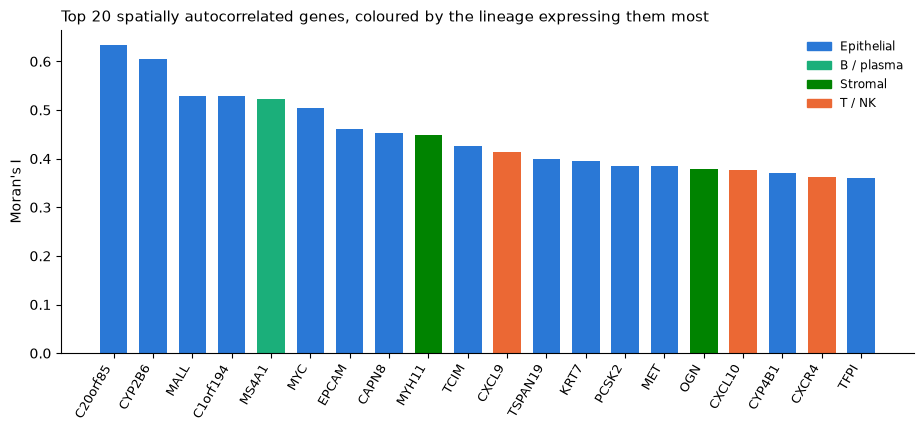

,I,pval_norm_fdr_bh,rank
CXCL9,0.4142,0.0000,11
CCL19,0.2551,0.0000,40
CD274,0.0082,0.0000,319
PDCD1,-0.0012,0.2328,376


Spatial structure is dominated by tissue compartments (tumour programmes, airway, B-cell TLS,
smooth muscle). Among immune signals, CXCL9 (I = 0.41, rank 11) forms hotspots, while PD-1 (I = -0.001)
has no spatial signal, consistent with it being near background.


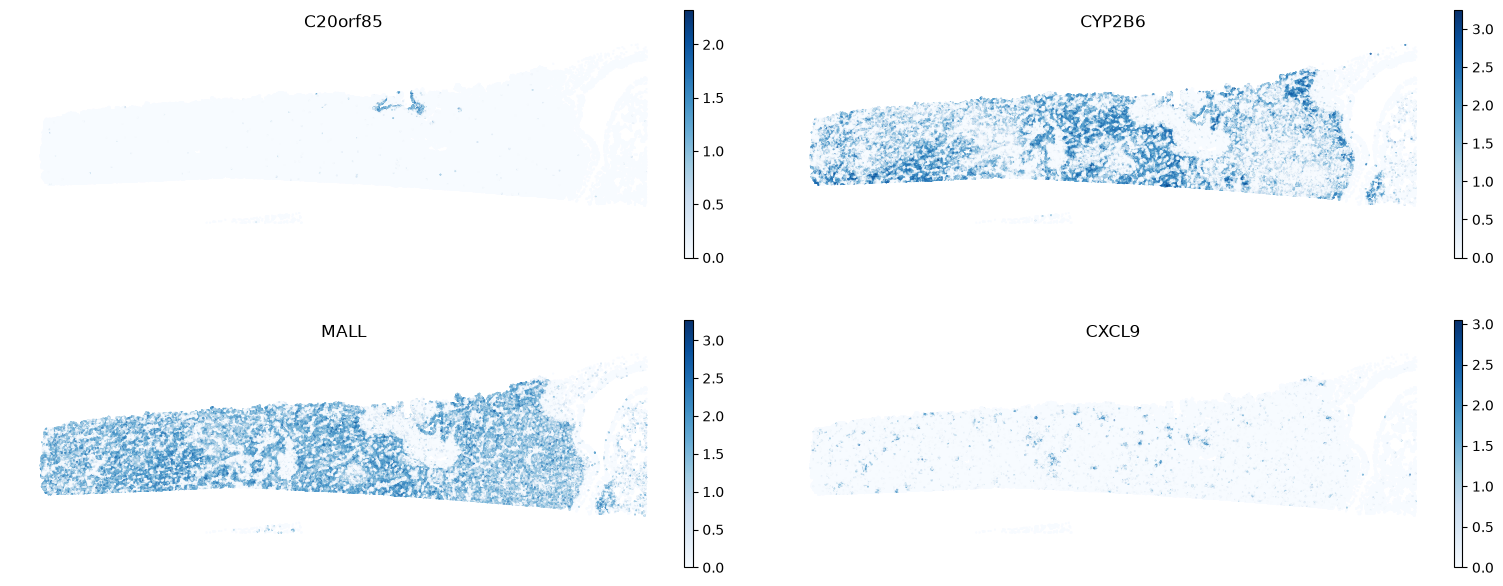

In [2]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
PROCESSED_DIR = DATA_ROOT / "processed"
SPATIAL_PATH = PROCESSED_DIR / f"{SAMPLE}_spatial.h5ad"   # Step 7 output (has the spatial graph)
TIME_PATH = PROCESSED_DIR / f"{SAMPLE}_time.h5ad"         # Step 9 output (contact-test results)
RESULTS_DIR = PROCESSED_DIR / "step10_squidpy"            # small result tables (CSV)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(SPATIAL_PATH)
adata.X = adata.layers["lognorm"]
LINEAGE_COLORS = dict(zip(adata.obs["lineage"].cat.categories, adata.uns["lineage_colors"]))
print(f"squidpy {sq.__version__}; {adata.n_obs:,} cells; Step 7 spatial graph with "
      f"{adata.obsp['spatial_connectivities'].nnz:,} edges\n")

# ---- Moran's I: which genes are spatially patterned? ------------------------------------
# I compares each cell's expression with its graph neighbours': ~0 = random in space,
# towards 1 = neighbours are similar (patches, gradients, structures).
# n_perms=None uses the analytical p-value; 100 permutations took > 10 min on this data.
t0 = time.time()
sq.gr.spatial_autocorr(adata, mode="moran", n_perms=None, show_progress_bar=False)
moran = adata.uns["moranI"]
print(f"Moran's I for {len(moran)} genes in {time.time() - t0:.0f} s; "
      f"{(moran['pval_norm_fdr_bh'] < 0.05).sum()} of {len(moran)} have FDR < 0.05.")
print("With ~140k cells nearly every gene is 'significant': rank by the effect size I, not the p-value.\n")

# Which lineage expresses each top gene most? (tells you what structure the pattern reflects)
top = moran.head(20).copy()
lin_mean = pd.DataFrame(adata[:, top.index].X.toarray(), columns=top.index).groupby(
    adata.obs["lineage"].to_numpy()).mean()
top["highest in"] = lin_mean.idxmax()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(range(len(top)), top["I"], color=[LINEAGE_COLORS[l] for l in top["highest in"]], width=0.7)
ax.set_xticks(range(len(top)), top.index, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("Moran's I")
ax.set_title("Top 20 spatially autocorrelated genes, coloured by the lineage expressing them most",
             loc="left", fontsize=11)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=LINEAGE_COLORS[l], label=l) for l in dict.fromkeys(top["highest in"])],
          frameon=False, fontsize=8.5, loc="upper right")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

key_genes = ["CXCL9", "CCL19", "CD274", "PDCD1"]
display(moran.loc[key_genes, ["I", "pval_norm_fdr_bh"]].assign(rank=[moran.index.get_loc(g) + 1 for g in key_genes]).round(4))
print(f"Spatial structure is dominated by tissue compartments (tumour programmes, airway, B-cell TLS,\n"
      f"smooth muscle). Among immune signals, CXCL9 (I = {moran.loc['CXCL9', 'I']:.2f}, rank "
      f"{moran.index.get_loc('CXCL9') + 1}) forms hotspots, while PD-1 (I = {moran.loc['PDCD1', 'I']:.3f})\n"
      "has no spatial signal, consistent with it being near background.")

# squidpy's own plotting function: top 3 genes + CXCL9 on the tissue
_verbosity, sc.settings.verbosity = sc.settings.verbosity, 0   # silence a harmless 'library_id' notice
sq.pl.spatial_scatter(adata, color=list(moran.index[:3]) + ["CXCL9"], shape=None, size=0.4,
                      cmap="Blues", ncols=2, figsize=(9, 3.4), frameon=False, wspace=0.05)
sc.settings.verbosity = _verbosity
plt.show()
moran.to_csv(RESULTS_DIR / "moran_i.csv")

### 10b. Co-occurrence: associations with a length scale

The ratio P(type B within distance d of type A) / P(type B), computed on a seeded 40k-cell subsample (lineage mix matches the full data).

**Finding:** around T / NK cells, epithelium is depleted to **0.08 at ~17 µm and still 0.73 at 300 µm**: T cells sit in large tumour-poor zones, not just one or two cells away from tumour. Around myeloid cells, epithelium recovers to ~1 within ~100-150 µm. Step 7b gave the same direction for direct contacts; co-occurrence adds the length scale.

Subsample lineage mix vs. full data (% of cells):


lineage,B / plasma,Endothelial,Epithelial,Mast,Myeloid,Stromal,T / NK
full,4.3,6.8,61.6,1.8,8.1,13.2,4.3
subsample,4.4,6.8,61.4,1.7,8.3,13.2,4.2


co_occurrence: 1.9 s


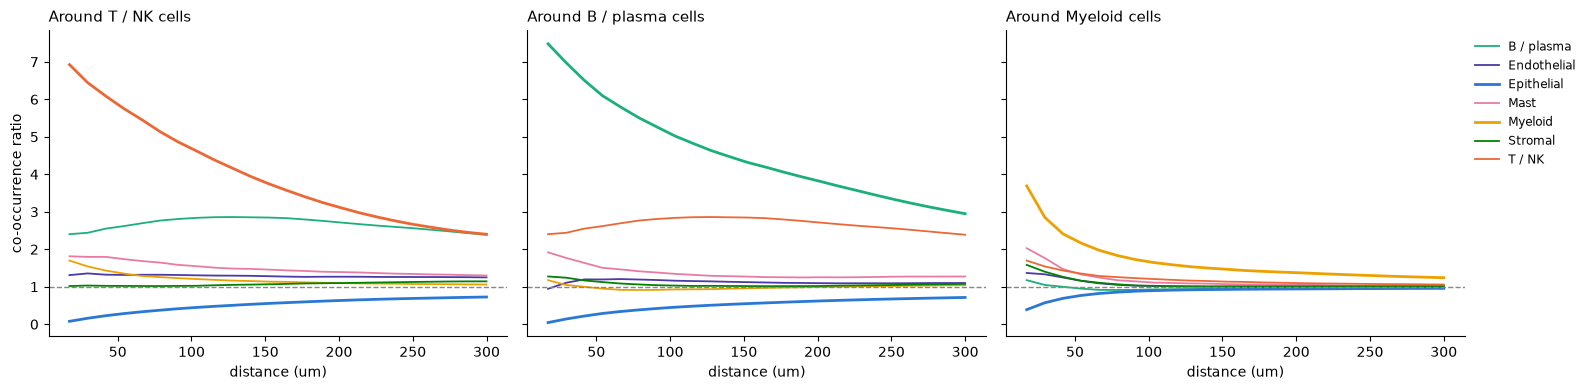

,epithelium within ~17 um,epithelium within ~103 um,epithelium within ~300 um
T / NK,0.08,0.45,0.73
B / plasma,0.04,0.45,0.71
Myeloid,0.39,0.90,0.96


Around T / NK cells, epithelium is strongly depleted at short range (0.08) and still
below 1 at 300 um (0.73): T cells sit in large tumour-poor zones, not just a
cell or two away from tumour. Around myeloid cells, epithelium recovers to ~1 within ~100-150 um:
myeloid cells live at the tumour edge. Same exclusion story as Steps 7d and 9d, now with a length scale.


In [3]:
# ---- A fixed random subsample for the distance-based statistics -------------------------
# co_occurrence and ripley scale super-linearly with cell number: Ripley's L on all 139k cells
# ran > 150 s; on 40k cells both take a few seconds. A seeded 40k subsample (29%) keeps every
# lineage well represented and is reproducible.
N_SUB = 40_000
sub = adata[np.random.default_rng(0).choice(adata.n_obs, N_SUB, replace=False)].copy()
print("Subsample lineage mix vs. full data (% of cells):")
display(pd.DataFrame({"full": adata.obs["lineage"].value_counts(normalize=True) * 100,
                      "subsample": sub.obs["lineage"].value_counts(normalize=True) * 100}).round(1).T)

# ---- Co-occurrence: P(type B within distance d | type A) / P(type B) ----------------------
# Ratio > 1 at distance d = B is found near A more than its overall frequency predicts.
# Unlike neighbourhood enrichment (direct contacts only), this shows HOW FAR an association reaches.
INTERVAL = np.linspace(5, 300, 25)
t0 = time.time()
sq.gr.co_occurrence(sub, cluster_key="lineage", interval=INTERVAL, show_progress_bar=False)
print(f"co_occurrence: {time.time() - t0:.1f} s")
occ = sub.uns["lineage_co_occurrence"]["occ"]          # (lineage, lineage, distance)
dist = sub.uns["lineage_co_occurrence"]["interval"][1:]
lineages = list(sub.obs["lineage"].cat.categories)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, anchor in zip(axes, ["T / NK", "B / plasma", "Myeloid"]):
    i = lineages.index(anchor)
    for j, lin in enumerate(lineages):
        ax.plot(dist, occ[i, j], color=LINEAGE_COLORS[lin], lw=2 if lin in (anchor, "Epithelial") else 1.3,
                label=lin)
    ax.axhline(1, color="#898781", ls="--", lw=1)
    ax.set_title(f"Around {anchor} cells", loc="left", fontsize=11)
    ax.set_xlabel("distance (um)")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("co-occurrence ratio")
axes[-1].legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.0, 1))
plt.tight_layout()
plt.show()

e_i = lineages.index("Epithelial")
at = [np.argmin(np.abs(dist - r)) for r in (20, 100, 300)]
summary = pd.DataFrame({anchor: occ[lineages.index(anchor), e_i, at] for anchor in ["T / NK", "B / plasma", "Myeloid"]},
                       index=[f"epithelium within ~{dist[i]:.0f} um" for i in at]).T.round(2)
display(summary)
t_i = lineages.index("T / NK")
print(f"Around T / NK cells, epithelium is strongly depleted at short range ({occ[t_i, e_i, at[0]]:.2f}) and still\n"
      f"below 1 at {dist[at[2]]:.0f} um ({occ[t_i, e_i, at[2]]:.2f}): T cells sit in large tumour-poor zones, not just a\n"
      "cell or two away from tumour. Around myeloid cells, epithelium recovers to ~1 within ~100-150 um:\n"
      "myeloid cells live at the tumour edge. Same exclusion story as Steps 7d and 9d, now with a length scale.")

### 10c. Ripley's L: clustering of each type against itself

**A squidpy pitfall worth knowing:** `gr.ripley` normalises every cluster's L by the *total* number of cells and simulates random sets of `n_observations` points. On raw data L then mostly tracks how **abundant** a cell type is: run that way, epithelium (60% of cells) looked "most clustered" and the random band collapsed to zero. The fix used here: a **balanced subsample of 2,000 cells per lineage** with random simulations of the same size, so all curves and the random band share one scale.

**Finding:** **B / plasma (3.6x the random band at 100 µm) and T / NK (3.3x) are by far the most clustered** (TLS and immune hubs); epithelium is the least (1.3x), because tumour fills most of the space. 'Random' means uniform in the convex hull, which ignores tissue holes, so the ranking between lineages is the informative part.

ripley L: 4.4 s (2,000 cells per lineage, 100 random simulations)


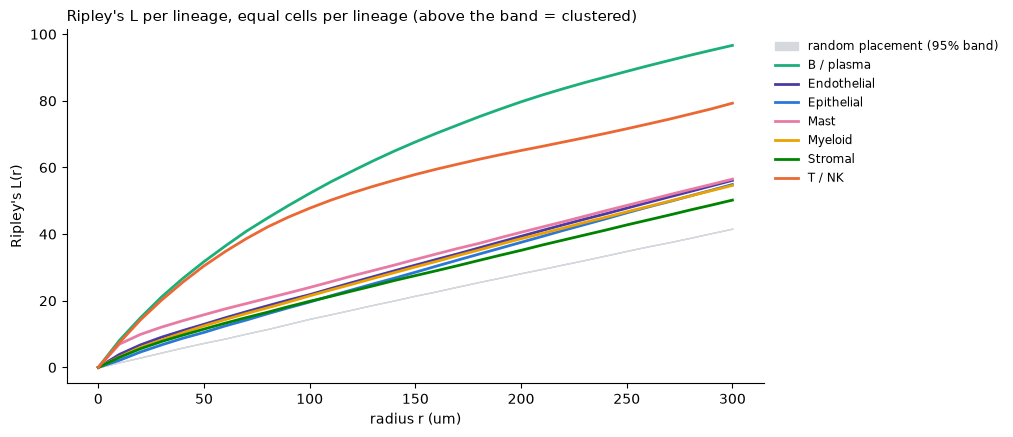

,L(100 um) / upper random band
lineage,
B / plasma,3.58
T / NK,3.28
Mast,1.65
Endothelial,1.50
Myeloid,1.47
Stromal,1.36
Epithelial,1.34


Ranked by clustering at 100 um: B / plasma, T / NK, Mast, Endothelial, Myeloid, Stromal, Epithelial.
Most clustered: B / plasma; least: Epithelial. Caveat: 'random' here means uniform inside the
convex hull of the section, which ignores holes and the irregular tissue edge, so every lineage looks
somewhat clustered; the ranking between lineages is the informative part.
Ripley's L measures each type against itself; neighbourhood enrichment (Step 7b) and co-occurrence
(10b) measure types against each other.


In [4]:
# ---- Ripley's L: how clustered is each lineage? ---------------------------------------------
# Pitfall: squidpy normalises every lineage's L by the TOTAL number of cells, and simulates
# random sets of n_observations points. Run on the raw data, L then mostly reflects how ABUNDANT
# a lineage is (epithelium = 60% of cells), not how clustered. The fix: a balanced subsample with
# the same number of cells per lineage, and random (CSR) simulations of that same size. Then each
# curve and the random band are on one scale and directly comparable.
N_PER_LINEAGE = 2_000
rng = np.random.default_rng(0)
idx = np.concatenate([rng.choice(np.flatnonzero(adata.obs["lineage"].to_numpy() == lin), N_PER_LINEAGE, replace=False)
                      for lin in adata.obs["lineage"].cat.categories])
bal = adata[idx].copy()
t0 = time.time()
sq.gr.ripley(bal, cluster_key="lineage", mode="L", max_dist=300, n_steps=31,
             n_simulations=100, n_observations=N_PER_LINEAGE, seed=0)
print(f"ripley L: {time.time() - t0:.1f} s ({N_PER_LINEAGE:,} cells per lineage, 100 random simulations)")
rip = bal.uns["lineage_ripley_L"]
L, sims = rip["L_stat"], rip["sims_stat"]
lo, hi = sims.groupby("bins")["stats"].quantile(0.025), sims.groupby("bins")["stats"].quantile(0.975)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.fill_between(lo.index, lo.to_numpy(), hi.to_numpy(), color="#d5d8dc", label="random placement (95% band)")
for lin, g in L.groupby("lineage", observed=True):
    ax.plot(g["bins"], g["stats"], color=LINEAGE_COLORS[lin], lw=2, label=lin)
ax.set_xlabel("radius r (um)")
ax.set_ylabel("Ripley's L(r)")
ax.set_title("Ripley's L per lineage, equal cells per lineage (above the band = clustered)", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.0, 1))
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

at100 = L[L["bins"].sub(100).abs() == L["bins"].sub(100).abs().min()].set_index("lineage")["stats"]
band100 = hi.iloc[np.argmin(np.abs(hi.index - 100))]
ratio = (at100 / band100).sort_values(ascending=False).rename("L(100 um) / upper random band")
display(ratio.round(2).to_frame())
print(f"Ranked by clustering at 100 um: {', '.join(ratio.index)}.\n"
      f"Most clustered: {ratio.index[0]}; least: {ratio.index[-1]}. Caveat: 'random' here means uniform inside the\n"
      "convex hull of the section, which ignores holes and the irregular tissue edge, so every lineage looks\n"
      "somewhat clustered; the ranking between lineages is the informative part.\n"
      "Ripley's L measures each type against itself; neighbourhood enrichment (Step 7b) and co-occurrence\n"
      "(10b) measure types against each other.")

### 10d. Network view: centrality and interaction matrix

**Finding:** **myeloid cells have the highest closeness centrality (0.39)**, i.e. they bridge tumour, stroma and immune compartments, the network form of the myeloid-lined tumour border; B / plasma cells are the least central (0.15), tucked into aggregates. The interaction matrix gives raw edge shares (what a cell actually touches): T / NK cells mostly touch other T / NK cells (36%), stroma (16%) and myeloid cells (14%). Unlike the z-scores of Step 7b, these are not corrected for abundance; both views are needed.

,degree_centrality,average_clustering,closeness_centrality
Myeloid,0.263,0.417,0.388
Stromal,0.310,0.419,0.355
Epithelial,0.417,0.424,0.303
Endothelial,0.173,0.427,0.291
T / NK,0.115,0.427,0.209
Mast,0.072,0.432,0.189
B / plasma,0.097,0.424,0.152


degree = share of the graph's cells this lineage connects to; closeness = how few steps it
takes to reach the rest of the tissue (a 'bridging' position); clustering = how interconnected
its neighbours are.
Highest closeness: Myeloid (0.39); lowest: B / plasma (0.15). The myeloid compartment sits
between tumour, stroma and immune cells, the network form of the myeloid-lined border in Step 7d.



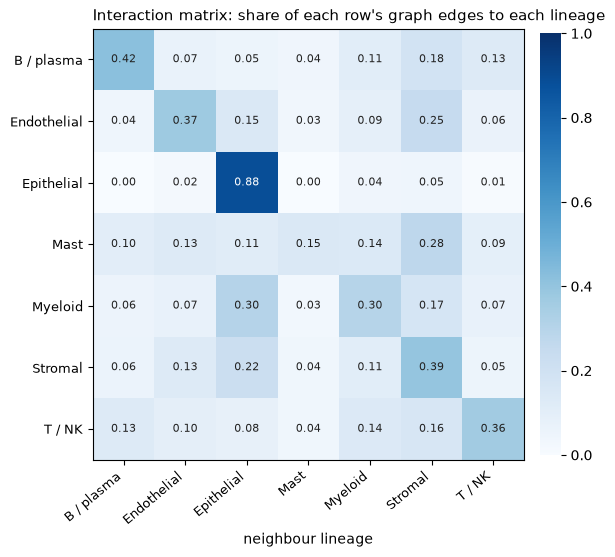

Raw edge shares (rows sum to 1) show what a typical cell actually touches. T / NK cells: T / NK 36%, Stromal 16%, Myeloid 14%.
Compare with Step 7b: a pair can be a large share of contacts yet still depleted relative to
chance (because epithelium is 60% of cells). Both views are needed.


In [5]:
# ---- Network view: centrality scores and interaction matrix (full data) ----------------
sq.gr.centrality_scores(adata, cluster_key="lineage", show_progress_bar=False)
cent = adata.uns["lineage_centrality_scores"].sort_values("closeness_centrality", ascending=False)
display(cent.round(3))
print("degree = share of the graph's cells this lineage connects to; closeness = how few steps it\n"
      "takes to reach the rest of the tissue (a 'bridging' position); clustering = how interconnected\n"
      "its neighbours are.")
print(f"Highest closeness: {cent.index[0]} ({cent['closeness_centrality'].iloc[0]:.2f}); lowest: "
      f"{cent.index[-1]} ({cent['closeness_centrality'].iloc[-1]:.2f}). The myeloid compartment sits\n"
      "between tumour, stroma and immune cells, the network form of the myeloid-lined border in Step 7d.\n")

sq.gr.interaction_matrix(adata, cluster_key="lineage", normalized=True)
lineages_full = list(adata.obs["lineage"].cat.categories)
im_df = pd.DataFrame(adata.uns["lineage_interactions"], index=lineages_full, columns=lineages_full)
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(im_df.to_numpy(), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(im_df)), im_df.columns, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(im_df)), im_df.index, fontsize=9)
for (i, j), v in np.ndenumerate(im_df.to_numpy()):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if v > 0.55 else "#222222")
ax.set_xlabel("neighbour lineage")
ax.set_title("Interaction matrix: share of each row's graph edges to each lineage", loc="left", fontsize=10.5)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03).outline.set_visible(False)
plt.show()
t_row = im_df.loc["T / NK"].sort_values(ascending=False)
print(f"Raw edge shares (rows sum to 1) show what a typical cell actually touches. T / NK cells: "
      f"{t_row.index[0]} {t_row.iloc[0]:.0%}, {t_row.index[1]} {t_row.iloc[1]:.0%}, "
      f"{t_row.index[2]} {t_row.iloc[2]:.0%}.\n"
      "Compare with Step 7b: a pair can be a large share of contacts yet still depleted relative to\n"
      "chance (because epithelium is 60% of cells). Both views are needed.")
cent.to_csv(RESULTS_DIR / "centrality_lineage.csv")
im_df.to_csv(RESULTS_DIR / "interaction_matrix_lineage.csv")

### 10e. `ligrec` vs. the Step 9 contact test

`gr.ligrec` (a CellPhoneDB-style test using the OmniPath database) asks whether a ligand in the sender type and its receptor in the receiver type are expressed above chance. It does **not** use space. Only **80 OmniPath pairs** have both genes on this panel.

**Finding, the key contrast:**
- **CCL19 -> CCR7** passes both tests: expressed (16 of 16 sender-receiver type pairs) and in contact (2.35x). The TLS homing axis is supported two ways.
- **EDN1 -> EDNRB** is significant in ligrec (tumour -> endothelium, 17 of 21 type pairs) but **not** spatially enriched (0.99x): the cells could signal, but EDN1+ tumour cells do not sit closer to EDNRB+ endothelium than other tumour cells do.
- PD-L1 -> PD-1 is in OmniPath but below ligrec's expression threshold; CD86 -> CTLA4/CD28 and MHC-II -> CD4 are not in the OmniPath list at all.

ligrec flags 2,953 'significant' combinations: expression-only tests are permissive, and spatial contact is what narrows them down. Note squidpy's dot plot legend: open circles mark significant interactions.

Result tables are saved as CSV in `~/data/xenium_lung/processed/step10_squidpy/`.

ligrec: 24 s; 80 ligand-receptor pairs from OmniPath have both genes on the panel (and pass the 5% expression threshold), tested across 324 sender-receiver cell-type combinations
Significant (FDR < 0.05) pair x sender x receiver combinations: 2,953 of 4,246 tested.
Expression-only tests flag many 'possible' interactions; spatial proximity narrows them down.



,ligrec (expression),ligrec top sender -> receiver,contact test obs/exp,contact test FDR q
pair,,,,
CD274 -> PDCD1,"in OmniPath, below expression threshold",-,0.45,0.8961
CD86 -> CTLA4,pair not in the OmniPath ligand-receptor list,-,1.01,0.5829
CD86 -> CD28,pair not in the OmniPath ligand-receptor list,-,1.03,0.5829
CCL19 -> CCR7,significant in 16 of 16 type pairs,mregDC (LAMP3+) -> mregDC (LAMP3+),2.35,0.0030
HLA-DQB2 -> CD4,pair not in the OmniPath ligand-receptor list,-,1.14,0.0030
EDN1 -> EDNRB,significant in 17 of 21 type pairs,Tumour epithelial (MYC/CAPN8) -> Endothelial,0.99,0.8571


They answer different questions. ligrec: could these cell types talk, given what they express?
Contact test: do the expressing cells actually touch more than chance? EDN1 -> EDNRB is the clearest
case: tumour cells and endothelium express the pair (ligrec significant), but EDN1+ tumour cells do
not sit next to EDNRB+ endothelium more than other tumour cells do (contact test null).
CCL19 -> CCR7 passes both: expressed AND in contact, the TLS homing axis.


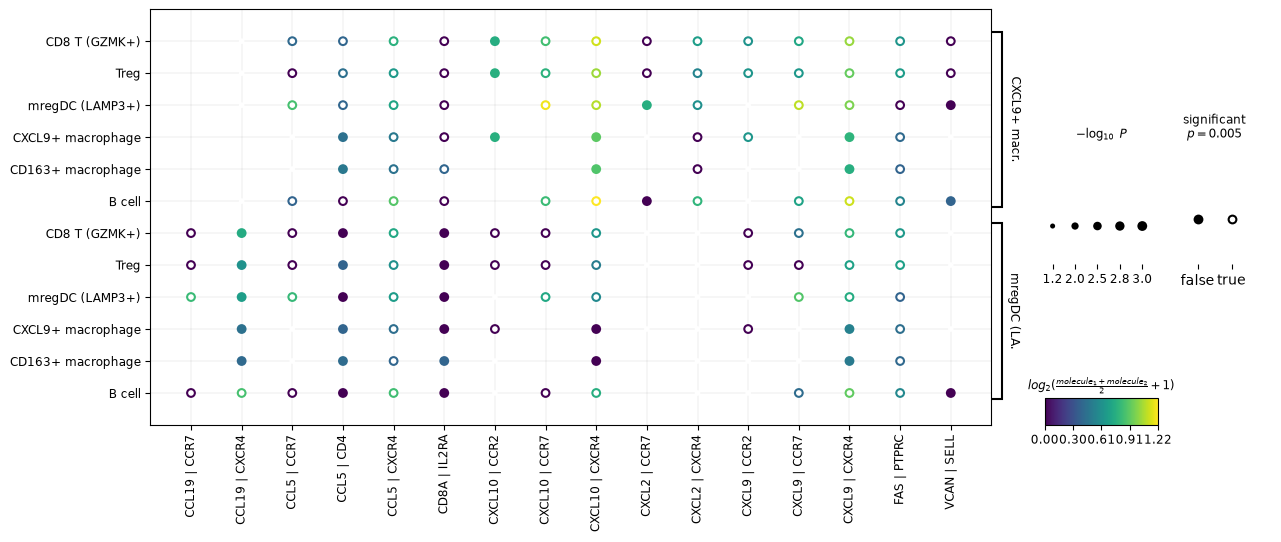

Saved CSV tables to ~/data/xenium_lung/processed/step10_squidpy/


In [6]:
# ---- squidpy ligrec (CellPhoneDB-style) vs. the Step 9 contact test ------------------------
# ligrec asks: is the ligand mean in the sender type x receptor mean in the receiver type higher
# than when cluster labels are shuffled? It uses expression only, not who touches whom.
# Interactions come from the OmniPath database (downloaded on first use).
t0 = time.time()
lr = sq.gr.ligrec(adata, cluster_key="time_type", use_raw=False, n_perms=1000, threshold=0.05,
                  seed=0, copy=True, corr_method="fdr_bh", show_progress_bar=False, n_jobs=4)
# ligrec returns sparse DataFrames; convert to dense floats before indexing or dropping NaNs
means = lr["means"].sparse.to_dense().astype(float)
qvals = lr["pvalues"].sparse.to_dense().astype(float)
print(f"ligrec: {time.time() - t0:.0f} s; {means.shape[0]} ligand-receptor pairs from OmniPath have both genes "
      f"on the panel (and pass the 5% expression threshold), tested across {means.shape[1]} sender-receiver "
      "cell-type combinations")
long = (qvals.stack([0, 1], future_stack=True).rename("q").to_frame()
        .join(means.stack([0, 1], future_stack=True).rename("mean")))
print(f"Significant (FDR < 0.05) pair x sender x receiver combinations: {(long['q'] < 0.05).sum():,} "
      f"of {long['q'].notna().sum():,} tested.\n"
      "Expression-only tests flag many 'possible' interactions; spatial proximity narrows them down.\n")

# Side-by-side with the Step 9 contact test for the same pairs
contact = sc.read_h5ad(TIME_PATH, backed="r").uns["step9_lr_results"]
rows = []
for _, r in contact.iterrows():
    lig, rec = r["pair"].split("_to_")
    if (lig, rec) in means.index:
        best = (pd.DataFrame({"mean": means.loc[(lig, rec)], "q": qvals.loc[(lig, rec)]})
                .dropna().sort_values("mean", ascending=False))
        sig = best[best["q"] < 0.05]
        top_pair = f"{sig.index[0][0]} -> {sig.index[0][1]}" if len(sig) else "-"
        ligrec_call = (f"significant in {len(sig)} of {len(best)} type pairs" if len(best)
                       else "in OmniPath, below expression threshold")
    else:
        top_pair, ligrec_call = "-", "pair not in the OmniPath ligand-receptor list"
    rows.append({"pair": f"{lig} -> {rec}", "ligrec (expression)": ligrec_call, "ligrec top sender -> receiver": top_pair,
                 "contact test obs/exp": round(r["obs_over_exp"], 2), "contact test FDR q": round(r["FDR_q"], 4)})
compare = pd.DataFrame(rows).set_index("pair")
display(compare)
print("They answer different questions. ligrec: could these cell types talk, given what they express?\n"
      "Contact test: do the expressing cells actually touch more than chance? EDN1 -> EDNRB is the clearest\n"
      "case: tumour cells and endothelium express the pair (ligrec significant), but EDN1+ tumour cells do\n"
      "not sit next to EDNRB+ endothelium more than other tumour cells do (contact test null).\n"
      "CCL19 -> CCR7 passes both: expressed AND in contact, the TLS homing axis.")

# squidpy's dot plot for the immune-relevant senders/receivers
FOCUS = ["CD8 T (GZMK+)", "Treg", "mregDC (LAMP3+)", "CXCL9+ macrophage", "CD163+ macrophage", "B cell"]
FOCUS = [f for f in FOCUS if f in adata.obs["time_type"].cat.categories]
sq.pl.ligrec(lr, source_groups=["mregDC (LAMP3+)", "CXCL9+ macrophage"], target_groups=FOCUS,
             alpha=0.005, means_range=(0.3, np.inf), swap_axes=True, remove_empty_interactions=True,
             remove_nonsig_interactions=True, title="ligrec: mregDC / CXCL9+ macrophage -> immune cells (FDR < 0.005)",
             figsize=(13, 5))
plt.show()
compare.to_csv(RESULTS_DIR / "ligrec_vs_contact_test.csv")
long[long["q"] < 0.05].sort_values("mean", ascending=False).to_csv(RESULTS_DIR / "ligrec_significant.csv")
print("Saved CSV tables to ~/data/xenium_lung/processed/step10_squidpy/")

## Summary

| Step | Output (in `~/data/xenium_lung/processed/`) | Key result |
|---|---|---|
| 4 QC | `..._qc.h5ad` | 154,394 of 162,254 cells kept (95.2%); low-count cells concentrated in a detached tissue sliver |
| 5 Clustering | `..._clustered.h5ad` | 14 Leiden clusters; ARI 0.51 vs. the 10x clustering |
| 6 Annotation | `..._annotated.h5ad` | 33 cell types in 7 lineages; ~10% flagged as segmentation spillover |
| 7 Spatial | `..._spatial.h5ad` | 10 niches; CD8 T cells excluded from tumour; 6 TLS-like aggregates |
| 8 H&E | `..._he_features.h5ad` | Alignment verified (peak at zero shift); cell calls match histology |
| 9 TIME | `..._time.h5ad` | PD-L1 on myeloid/DCs not tumour; CD8 lose CCR7 toward tumour; CCL19-CCR7 contacts 2.4x enriched; 65% of tumour tiles immune-excluded, MYC/CAPN8 region mostly desert |
| 10 squidpy | `step10_squidpy/*.csv` | CXCL9 forms hotspots (Moran's I 0.41); epithelium depleted around T cells out to 300 µm; B/plasma and T/NK most clustered; myeloid most central; ligrec vs. contact tests disagree on EDN1-EDNRB |

**Biological picture of this section:** an adenocarcinoma-like, largely tumour-filled section with three spatially separate tumour epithelial programmes; a tumour border lined by macrophages, cDC2 and fibroblasts; CD8 T cells held back from tumour nests (immune-excluded pattern) and instead gathered with B cells and mregDCs in TLS-like aggregates, where CCL19-CCR7 homing contacts are strongly enriched. PD-L1 is carried by CXCL9+ macrophages and mregDCs rather than tumour cells, Tregs rise relative to CD8 T cells toward the tumour, and one tumour programme (MYC/CAPN8) is largely immune-desert.

**Limits to state honestly:** one section from one patient (descriptive, not inferential); a Multi-Tissue 377-gene panel (no AT2 / basal / club markers, no mature-TLS markers); tumour identity inferred from markers and histology, not copy number; default 10x segmentation (spillover in ~10% of cells).

**Natural next steps:**
1. **Re-segmentation** from `transcripts.parquet` (e.g. Baysor, Proseg) to reduce spillover and recover CD4 T cells.
2. **Dataset B (Xenium Prime 5K)**: the same workflow with ~5,000 genes, enabling finer T-cell states, tumour programmes and ligand-receptor analysis.
3. **Ligand-receptor analysis on a larger panel**: Step 10e shows only 80 OmniPath pairs are testable here; the 5K panel adds the missing genes (CXCR3, CXCL13, TIGIT, TOX, SPP1).
4. **Multi-sample cohort**: niche and TLS features compared across patients and linked to outcome.